To Do
- DONE - take proximity out 
- make a matrix of all skills up and down shocks - Voor de shock matrix: misschien eerst beginnen met elke parameter een keer + en – doen, dan kunnen we daar eerst de results van beoordelen. Als dat dan “klopt”, dan kunnen we verder kijken naar eventueel combinaties van parameters.
- done - make 5 years the max
- Done - reverse sign at reputation

In [2]:

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import random


from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch


from itertools import combinations, product
from tqdm.auto import tqdm

import copy

import inspect

## Questions
- is enforcement disconnected? It sort of looks like it


## To do
### make seed relevant
### make picture of layers
### make trust competition negtive line 0.5 instead of 0.2

### CLD NUMBERS?!?!?!?!?!

In [3]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)

In [4]:
# # =========================================
# # INITIAL RELATION PARAMETER SCENARIOS
# # =========================================

# initial_scenarios = {

#     "null_point": {
#         "competition": 0.0,
#         "cooperation": 0.0,
#         "trust": 0.0,
#         "pressure": 0.0,
#         "enforcement": 0.0
#     },

#     "balance": {
#         "competition": 0.5,
#         "cooperation": 0.5,
#         "trust": 0.5,
#         "pressure": 0.5,
#         "enforcement": 0.5
#     },

#     "heterogeneous": {
#         "competition": 0.8,
#         "cooperation": 0.4,
#         "trust": 0.3,
#         "pressure": 0.5,
#         "enforcement": 0.7
#     }

# }

# Turn Reputation back to negative!!

In [5]:
XLSX_PATH = r"C:\Users\foetker\Documents\Causalix Project\PPC Model Nodes 1.xlsx"
RELATION_PARAMS = ["competition", "cooperation", "trust", "pressure", "enforcement"]
np.random.seed(7)

In [6]:
def load_workbook(path=XLSX_PATH):
    # --- actors: skills + institutional attributes ---
    raw = pd.read_excel(path, sheet_name="actor skills", header=[0, 1])
    raw = raw[raw.iloc[:, 0].notna()].reset_index(drop=True)
    name_col = raw.columns[0]
    actor_names = raw[name_col].astype(str).str.strip().values
    raw = raw.drop(columns=[name_col])
    raw.index = pd.Index(actor_names, name="actor")

    skill_cols = [c[1] for c in raw.columns if c[0] in ("Mentalities", "Technologies", "Resources (Capital)")]
    institution_cols = [c[1] for c in raw.columns if c[0] == "Institutions"]

    actors_df = raw.copy()
    actors_df.columns = [c[1] for c in actors_df.columns]
    #skills_df = actors_df[skill_cols].astype(float)
    skills_df = actors_df[skill_cols].astype(float)
    # Reputation has a negative effect on PPC, so store it as a negative value
    if "Reputation" in skills_df.columns:
        skills_df["Reputation"] = -skills_df["Reputation"].abs()



    institutions_df = actors_df[institution_cols]

    # --- parameter x parameter (CLD core) ---
    rel_rel = pd.read_excel(path, sheet_name="scoring relation parameters", header=1, index_col=0)
    rel_rel = rel_rel.replace("x", np.nan).astype(float)

    # --- skill -> parameter ---
    skill_param = pd.read_excel(path, sheet_name="Skills x Indicators", header=0, index_col=0)
    skill_param = skill_param.replace("x", np.nan).astype(float)

    # --- parameter -> skill ---
    param_skill = pd.read_excel(path, sheet_name="Indicators x Skills", header=2, index_col=0)
    param_skill = param_skill.replace("x", np.nan).astype(float)

    return {
        "actors_df": actors_df, "skills_df": skills_df, "institutions_df": institutions_df,
        "skill_cols": skill_cols, "rel_rel": rel_rel, "skill_param": skill_param, "param_skill": param_skill,
    }

data = load_workbook()
print(f"Loaded {len(data['skills_df'])} actors, {len(data['skill_cols'])} skills, "
      f"{len(RELATION_PARAMS)} relation parameters.")
data["skills_df"].round(2)


Loaded 14 actors, 11 skills, 5 relation parameters.


C:\Users\foetker\AppData\Local\Temp\ipykernel_25284\159564155.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rel_rel = rel_rel.replace("x", np.nan).astype(float)
C:\Users\foetker\AppData\Local\Temp\ipykernel_25284\159564155.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  skill_param = skill_param.replace("x", np.nan).astype(float)
C:\Users\foetker\AppData\Local\Temp\ipykernel_25284\159564155.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old b

,Risk Mentality,Punishment Mentality,Enforcement of rules/laws,Pressure,Economic Capital,Cultural Capital,Social Capital,Reputation,Sense of Urgency,Formal responsibility,Informal Responsibility
actor,,,,,,,,,,,
Private actor 1,0.5,0.5,0.2,0.2,0.5,0.2,0.2,-0.8,0.8,0.2,0.2
Public authority 1,0.5,0.8,0.8,0.5,0.5,0.5,0.8,-0.8,0.8,0.5,0.5
Public authority 2,0.5,0.8,0.8,0.8,0.8,0.8,0.8,-0.8,0.8,0.5,0.5
Public authority 3,0.8,0.8,0.8,0.8,0.8,0.8,0.8,-0.8,0.8,0.5,0.5
Public authority 4,0.5,0.8,0.8,0.5,0.8,0.8,0.5,-0.8,0.8,0.5,0.5
Public actor 1,0.5,0.2,0.2,0.2,0.5,0.2,0.5,-0.8,0.8,0.2,0.5
Public actor 2,0.5,0.5,0.2,0.8,0.2,0.2,0.8,-0.5,0.8,0.2,0.8
Public authority 5,0.2,0.8,0.8,0.5,0.5,0.5,0.2,-0.8,0.5,0.5,0.5
Public actor 3,0.2,0.5,0.8,0.2,0.2,0.2,0.2,-0.8,0.5,0.2,0.2


In [7]:
data["institutions_df"]


,Public/Private,Scope of Authority (related to proximity),Strategic/Operational
actor,,,
Private actor 1,Private,PoR,Strategic
Public authority 1,Public,PoR,Operational
Public authority 2,Public,"PoR, Rotterdam, National","Strategy, Operational"
Public authority 3,Public,"PoR, Rotterdam","Strategy, Operational"
Public authority 4,Public,"PoR, Rotterdam","Strategy, Operational"
Public actor 1,Public,"Rotterdam, PoR",Strategy
Public actor 2,Public,"PoR, Rotterdam, National",Strategy
Public authority 5,Public,"Rotterdam, National, PoR","Strategy, Operational"
Public actor 3,Public,"National, Rotterdam, PoR","Strategy, Operational"


In [8]:
# =========================================
# INITIAL RELATION PARAMETER SCENARIOS
# =========================================

initial_scenarios = {

    "nullpoint": {
        "competition": 0.0,
        "cooperation": 0.0,
        "trust": 0.0,
        "pressure": 0.0,
        "enforcement": 0.0
    },

    "balance": {
        "competition": 0.5,
        "cooperation": 0.5,
        "trust": 0.5,
        "pressure": 0.5,
        "enforcement": 0.5
    },

    "heterogeneous": {
        "competition": 0.8,
        "cooperation": 0.4,
        "trust": 0.3,
        "pressure": 0.5,
        "enforcement": 0.7
    }

}

In [9]:
# SKILL_ORIENTATION = {
#     "Risk Mentality": +1, "Punishment Mentality": -1, "Enforcement of rules/laws": -1,
#     "Pressure": 0,                 # handled specially -- see pressure_sweet_spot_factor
#     "Economic Capital": +1, "Cultural Capital": +1, "Social Capital": +1,
#     "Reputation": -1,              # rule 28 override (damages cooperation)
#     "Sense of Urgency": +1, "Formal responsibility": +1,
#     "Informal Responsibility": +1,  # rule 29: same effect as formal
# }

# PARAM_ORIENTATION = {
#     "competition": -1, "cooperation": +1, "trust": +1, 
#     "pressure": 0,                  # handled specially
#     "enforcement": -1,
# }

# def signed(magnitude, orient_a, orient_b):
#     if pd.isna(magnitude):
#         return 0.0
#     if orient_a == 0 or orient_b == 0:
#         # neutral orientation (pressure): pass through as a mild, damped link
#         return 0.35 * magnitude
#     return (1 if orient_a == orient_b else -1) * magnitude

# def build_signed_matrices(data):
#     rel_rel, skill_param, param_skill = data["rel_rel"], data["skill_param"], data["param_skill"]

#     signed_rel_rel = pd.DataFrame(index=rel_rel.index, columns=rel_rel.columns, dtype=float)
#     for i in rel_rel.index:
#         for j in rel_rel.columns:
#             #signed_rel_rel.loc[i, j] = signed(rel_rel.loc[i, j], PARAM_ORIENTATION[i], PARAM_ORIENTATION[j])
#             signed_rel_rel = rel_rel.copy().astype(float)

#     signed_skill_param = pd.DataFrame(index=skill_param.index, columns=skill_param.columns, dtype=float)
#     for s in skill_param.index:
#         for p in skill_param.columns:
#             signed_skill_param.loc[s, p] = signed(skill_param.loc[s, p], SKILL_ORIENTATION[s], PARAM_ORIENTATION[p])

#     signed_param_skill = pd.DataFrame(index=param_skill.index, columns=param_skill.columns, dtype=float)
#     for p in param_skill.index:
#         for s in param_skill.columns:
#             signed_param_skill.loc[p, s] = signed(param_skill.loc[p, s], PARAM_ORIENTATION[p], SKILL_ORIENTATION[s])

#     return signed_rel_rel, signed_skill_param, signed_param_skill

# signed_matrices = build_signed_matrices(data)
# signed_rel_rel, signed_skill_param, signed_param_skill = signed_matrices
# signed_rel_rel.round(2)

def build_matrices(data):
    """
    Load the causal influence matrices exactly as specified in Excel.
    No additional sign transformations or orientation rules are applied.
    """

    rel_rel = data["rel_rel"].copy().astype(float)
    skill_param = data["skill_param"].copy().astype(float)
    param_skill = data["param_skill"].copy().astype(float)

    # Replace empty cells (NaN) with 0 = no causal relationship
    rel_rel = rel_rel.fillna(0.0)
    skill_param = skill_param.fillna(0.0)
    param_skill = param_skill.fillna(0.0)

    return rel_rel, skill_param, param_skill


# Build matrices directly from Excel
signed_matrices = build_matrices(data)

# Keep individual matrix names for existing code compatibility
signed_rel_rel, signed_skill_param, signed_param_skill = signed_matrices

# Inspect
print(signed_rel_rel.round(2))

             competition  cooperation  trust  pressure  enforcement
competition          0.0         -0.5   -0.2       0.2          0.0
cooperation         -0.5          0.0    0.8      -0.5          0.0
trust               -0.8          0.8    0.0      -0.2          0.0
pressure             0.2          0.8    0.0       0.0          0.8
enforcement          0.0         -0.8    0.0       0.5          0.0


In [10]:
print(signed_skill_param["enforcement"].dropna())   # skills currently pushing competition
print(signed_rel_rel["enforcement"].dropna())        # other params pushing competition

Risk Mentality               0.5
Punishment Mentality         0.8
Enforcement of rules/laws    0.8
Pressure                     0.8
Economic Capital             0.0
Cultural Capital             0.2
Social Capital               0.2
Reputation                   0.8
Sense of Urgency             0.8
Formal responsibility        0.5
Informal Responsibility      0.5
Name: enforcement, dtype: float64
competition    0.0
cooperation    0.0
trust          0.0
pressure       0.8
enforcement    0.0
Name: enforcement, dtype: float64


In [11]:
print(signed_skill_param["trust"].dropna())   # skills currently pushing competition
print(signed_rel_rel["trust"].dropna())        # other params pushing competition

Risk Mentality               0.8
Punishment Mentality         0.8
Enforcement of rules/laws    0.5
Pressure                     0.5
Economic Capital             0.5
Cultural Capital             0.8
Social Capital               0.5
Reputation                   0.2
Sense of Urgency             0.0
Formal responsibility        0.2
Informal Responsibility      0.2
Name: trust, dtype: float64
competition   -0.2
cooperation    0.8
trust          0.0
pressure       0.0
enforcement    0.0
Name: trust, dtype: float64


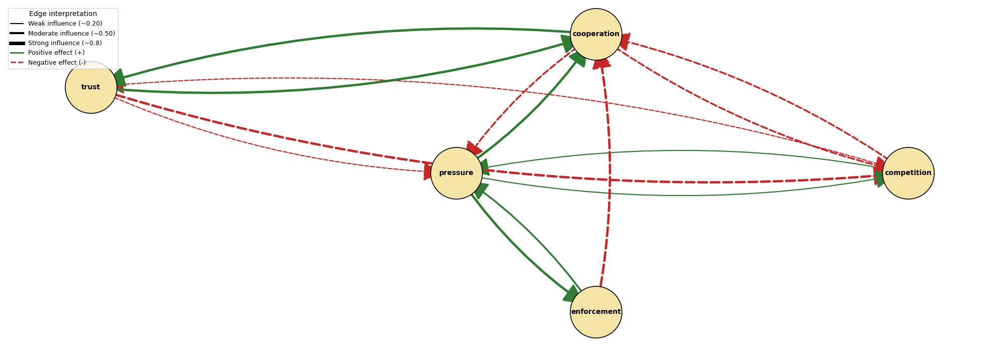

In [88]:
# def draw_cld(signed_rel_rel, title="Causal Loop Diagram: relation-parameter core"):
#     G = nx.DiGraph()
#     G.add_nodes_from(signed_rel_rel.index)
#     for i in signed_rel_rel.index:
#         for j in signed_rel_rel.columns:
#             w = signed_rel_rel.loc[i, j]
#             if i != j and w != 0:
#                 G.add_edge(i, j, weight=w)

#     pos = nx.circular_layout(G)
#     fig, ax = plt.subplots(figsize=(7.5, 7.5))
#     pos["pressure"] = np.array([0.0, 0.0])  # pressure sits centrally: it touches everything

#     nx.draw_networkx_nodes(G, pos, node_size=2600, node_color="#F5E6A8", edgecolors="black", ax=ax)
#     nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", ax=ax)

#     for u, v, d in G.edges(data=True):
#         color = "#2E7D32" if d["weight"] > 0 else "#C62828"
#         style = "-" if d["weight"] > 0 else "--"
#         nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], ax=ax,
#                                 width=1 + 3 * abs(d["weight"]), edge_color=color,
#                                 style=style, connectionstyle="arc3,rad=0.15",
#                                 arrowsize=15, min_source_margin=20, min_target_margin=20)

# #     ax.plot([], [], color="#2E7D32", label="Positive effect (+)")
# #     ax.plot([], [], color="#C62828", linestyle="--", label="Negative effect (-)")
# #     ax.legend(loc="upper right")
# #     ax.set_title(title, fontweight="bold")
# #     ax.axis("off")
# #     plt.tight_layout()
# #     plt.show()

# # draw_cld(signed_rel_rel)

# def draw_cld(signed_rel_rel, title="Causal Loop Diagram: relation-parameter core"):
#     G = nx.DiGraph()
#     G.add_nodes_from(signed_rel_rel.index)

#     for i in signed_rel_rel.index:
#         for j in signed_rel_rel.columns:
#             w = signed_rel_rel.loc[i, j]
#             if i != j and w != 0:
#                 G.add_edge(i, j, weight=w)

#     pos = nx.circular_layout(G)
#     pos["pressure"] = np.array([0.0, 0.0])  # pressure sits centrally

#     fig, ax = plt.subplots(figsize=(8.5, 8.5))

#     nx.draw_networkx_nodes(
#         G, pos,
#         node_size=2600,
#         node_color="#F5E6A8",
#         edgecolors="black",
#         ax=ax
#     )

#     nx.draw_networkx_labels(
#         G, pos,
#         font_size=10,
#         font_weight="bold",
#         ax=ax
#     )

#         # Draw edges and collect labels
#     edge_labels = {}

#     for u, v, d in G.edges(data=True):
#         weight = d["weight"]

#         color = "#2E7D32" if weight > 0 else "#C62828"
#         style = "-" if weight > 0 else "--"

#         nx.draw_networkx_edges(
#             G,
#             pos,
#             edgelist=[(u, v)],
#             ax=ax,
#             width=1 + 3 * abs(weight),
#             edge_color=color,
#             style=style,
#             connectionstyle="arc3,rad=0.15",
#             arrowsize=15,
#             min_source_margin=20,
#             min_target_margin=20
#         )

#         # Store exact tie value from the matrix
#         edge_labels[(u, v)] = f"{weight:.2f}"

#      # Draw edge weight labels (one label per edge)
#     nx.draw_networkx_edge_labels(
#         G,
#         pos,
#         edge_labels={
#             (u, v): f"{d['weight']:.2f}"
#             for u, v, d in G.edges(data=True)
#         },
#         font_size=8,
#         label_pos=0.5,       # exactly on the edge midpoint
#         rotate=False,
#         bbox=dict(
#             boxstyle="round,pad=0.15",
#             facecolor="white",
#             edgecolor="none",
#             alpha=0.8
#         ),
#         ax=ax
#     )

#         # Store exact tie value for display
#         #edge_labels[(u, v)] = f"{weight:.2f}"

#     # Add edge weight labels
#     nx.draw_networkx_edge_labels(
#         G,
#         pos,
#         edge_labels=edge_labels,
#         font_size=8,
#         label_pos=0.5,
#         rotate=False,
#         bbox=dict(
#             alpha=0.8,
#             color="white",
#             edgecolor="none"
#         ),
#         ax=ax
#     )

#     # Legend
#     ax.plot([], [], color="#2E7D32", label="Positive effect (+)")
#     ax.plot([], [], color="#C62828", linestyle="--", label="Negative effect (-)")
#     ax.legend(loc="upper right")

#     ax.set_title(title, fontweight="bold")
#     ax.axis("off")
#     plt.tight_layout()
#     plt.show()


# draw_cld(signed_rel_rel)

# def draw_cld(signed_rel_rel, title="Causal Loop Diagram: relation-parameter core"):
#     G = nx.DiGraph()
#     G.add_nodes_from(signed_rel_rel.index)

#     # Build graph from matrix
#     for i in signed_rel_rel.index:
#         for j in signed_rel_rel.columns:
#             w = signed_rel_rel.loc[i, j]
#             if i != j and w != 0:
#                 G.add_edge(i, j, weight=w)

#     pos = nx.circular_layout(G)

#     # Keep pressure central if it exists
#     if "pressure" in pos:
#         pos["pressure"] = np.array([0.0, 0.0])

#     fig, ax = plt.subplots(figsize=(12, 8.5))

#     # Draw nodes
#     nx.draw_networkx_nodes(
#         G,
#         pos,
#         node_size=2600,
#         node_color="#F5E6A8",
#         edgecolors="black",
#         ax=ax
#     )

#     # Draw node names
#     nx.draw_networkx_labels(
#         G,
#         pos,
#         font_size=10,
#         font_weight="bold",
#         ax=ax
#     )

#     # Store edge information for legend
#     edge_legend = []

#     # Draw edges
#     for u, v, d in G.edges(data=True):
#         weight = d["weight"]

#         color = "#2E7D32" if weight > 0 else "#C62828"
#         style = "-" if weight > 0 else "--"

#         nx.draw_networkx_edges(
#             G,
#             pos,
#             edgelist=[(u, v)],
#             ax=ax,
#             width=1 + 3 * abs(weight),
#             edge_color=color,
#             style=style,
#             connectionstyle="arc3,rad=0.15",
#             arrowsize=15,
#             min_source_margin=20,
#             min_target_margin=20
#         )

#         # Add edge details to legend
#         sign = "+" if weight > 0 else "-"
#         edge_legend.append(
#             f"{u} → {v}: {weight:.2f} ({sign})"
#         )

#     # Side legend containing all edge weights
#     weight_text = "Edge weights:\n\n" + "\n".join(edge_legend)

#     plt.text(
#         1.02,
#         0.5,
#         weight_text,
#         transform=ax.transAxes,
#         fontsize=8,
#         verticalalignment="center",
#         bbox=dict(
#             boxstyle="round,pad=0.5",
#             facecolor="white",
#             edgecolor="black",
#             alpha=0.9
#         )
#     )

#     # Effect type legend
#     ax.plot(
#         [],
#         [],
#         color="#2E7D32",
#         label="Positive effect (+)"
#     )

#     ax.plot(
#         [],
#         [],
#         color="#C62828",
#         linestyle="--",
#         label="Negative effect (-)"
#     )

#     ax.legend(
#         loc="upper left"
#     )

#     ax.set_title(
#         title,
#         fontweight="bold"
#     )

#     ax.axis("off")

#     plt.tight_layout()
#     plt.show()


# # Run CLD
# # draw_cld(signed_rel_rel)


#UNCOMMENT HERE

# def draw_cld(signed_rel_rel, title="Causal Loop Diagram: relation-parameter core"):
#     G = nx.DiGraph()
#     G.add_nodes_from(signed_rel_rel.index)

#     # Build graph from matrix
#     for i in signed_rel_rel.index:
#         for j in signed_rel_rel.columns:
#             w = signed_rel_rel.loc[i, j]
#             if i != j and w != 0:
#                 G.add_edge(i, j, weight=w)

#     pos = nx.circular_layout(G)

#     # Keep pressure central if it exists
#     if "pressure" in pos:
#         pos["pressure"] = np.array([0.0, 0.0])

#     fig, ax = plt.subplots(figsize=(10, 8.5))

#     # Draw nodes
#     nx.draw_networkx_nodes(
#         G,
#         pos,
#         node_size=4000,
#         node_color="#F5E6A8",
#         edgecolors="black",
#         ax=ax
#     )

#     # Draw node labels
#     nx.draw_networkx_labels(
#         G,
#         pos,
#         font_size=10,
#         font_weight="bold",
#         ax=ax
#     )

#     # Draw edges
#     for u, v, d in G.edges(data=True):
#         weight = d["weight"]

#         # Color indicates direction of effect
#         color = "#2E7D32" if weight > 0 else "#C62828"

#         # Line type indicates positive/negative
#         style = "-" if weight > 0 else "--"

#         nx.draw_networkx_edges(
#             G,
#             pos,
#             edgelist=[(u, v)],
#             ax=ax,
#             width=1 + 3 * abs(weight),
#             edge_color=color,
#             style=style,
#             connectionstyle="arc3,rad=0.15",
#             arrowsize=40,
#             min_source_margin=20,
#             min_target_margin=20
#         )

#     # Legend: edge width meaning
#     ax.plot(
#         [],
#         [],
#         color="black",
#         linewidth=1.5,
#         label="Weak influence (~0.20)"
#     )

#     ax.plot(
#         [],
#         [],
#         color="black",
#         linewidth=3,
#         label="Moderate influence (~0.50)"
#     )

#     ax.plot(
#         [],
#         [],
#         color="black",
#         linewidth=5,
#         label="Strong influence (~0.8)"
#     )

#     # Legend: edge direction meaning
#     ax.plot(
#         [],
#         [],
#         color="#2E7D32",
#         linewidth=2,
#         label="Positive effect (+)"
#     )

#     ax.plot(
#         [],
#         [],
#         color="#C62828",
#         linestyle="--",
#         linewidth=2,
#         label="Negative effect (-)"
#     )

#     ax.legend(
#         loc="upper left",
#         title="Edge interpretation",
#         fontsize=9
#     )

#     ax.set_title(
#         title,
#         fontweight="bold"
#     )

#     ax.axis("off")

#     plt.tight_layout()
#     plt.show()


# # Draw CLD
# draw_cld(signed_rel_rel)

def draw_cld(signed_rel_rel, title=""):
    G = nx.DiGraph()
    G.add_nodes_from(signed_rel_rel.index)

    # Build graph from matrix
    for i in signed_rel_rel.index:
        for j in signed_rel_rel.columns:
            w = signed_rel_rel.loc[i, j]
            if i != j and w != 0:
                G.add_edge(i, j, weight=w)

    # Start with circular layout, then stretch horizontally
    pos = nx.circular_layout(G)

    # Make the layout flat and wide
    for node in pos:
        pos[node][0] *= 1.8   # horizontal stretch
        pos[node][1] *= 0.65  # vertical compression

    # Keep pressure central if it exists
    if "pressure" in pos:
        pos["pressure"] = np.array([0.0, 0.0])

    # Wider, flatter figure
    fig, ax = plt.subplots(figsize=(20, 7))

    # Draw nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=5500,
        node_color="#F5E6A8",
        edgecolors="black",
        linewidths=1.2,
        ax=ax
    )

    # Draw node labels
    nx.draw_networkx_labels(
        G,
        pos,
        font_size=10,
        font_weight="bold",
        ax=ax
    )

    # Draw edges
    for u, v, d in G.edges(data=True):
        weight = d["weight"]

        # Color indicates direction of effect
        color = "#2E7D32" if weight > 0 else "#C62828"

        # Line type indicates positive/negative
        style = "-" if weight > 0 else "--"

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[(u, v)],
            ax=ax,
            width=1 + 3 * abs(weight),
            edge_color=color,
            style=style,
            connectionstyle="arc3,rad=0.10",
            arrowsize=60,
            min_source_margin=20,
            min_target_margin=20
        )

    # Legend: edge width meaning
    ax.plot(
        [], [], color="black", linewidth=1.5,
        label="Weak influence (~0.20)"
    )

    ax.plot(
        [], [], color="black", linewidth=3,
        label="Moderate influence (~0.50)"
    )

    ax.plot(
        [], [], color="black", linewidth=5,
        label="Strong influence (~0.8)"
    )

    # Legend: edge direction meaning
    ax.plot(
        [], [], color="#2E7D32", linewidth=2,
        label="Positive effect (+)"
    )

    ax.plot(
        [], [], color="#C62828", linestyle="--", linewidth=2,
        label="Negative effect (-)"
    )

    ax.legend(
        loc="upper left",
        title="Edge interpretation",
        fontsize=9
    )

    ax.set_title(
        title,
        fontweight="bold",
        fontsize=14
    )

    ax.axis("off")

    plt.tight_layout()
    plt.show()


# Draw CLD
draw_cld(signed_rel_rel)

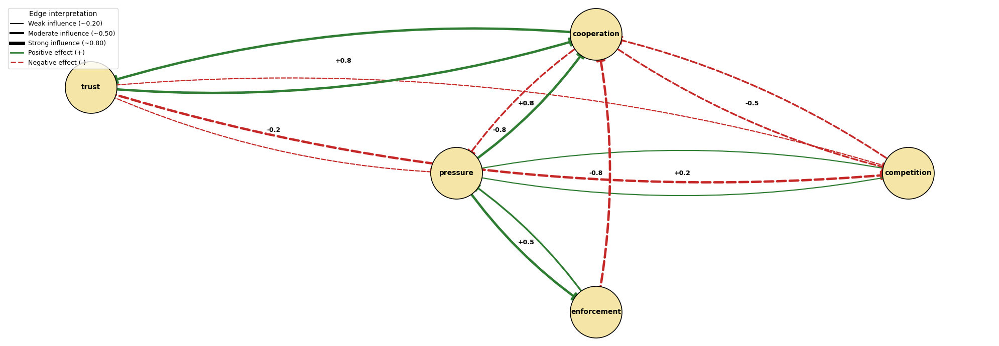

In [89]:
def draw_cld(signed_rel_rel, title=""):
    G = nx.DiGraph()
    G.add_nodes_from(signed_rel_rel.index)

    # Build graph from matrix
    for i in signed_rel_rel.index:
        for j in signed_rel_rel.columns:
            w = signed_rel_rel.loc[i, j]
            if i != j and w != 0:
                G.add_edge(i, j, weight=w)

    # Layout
    pos = nx.circular_layout(G)

    for node in pos:
        pos[node][0] *= 1.8
        pos[node][1] *= 0.65

    if "pressure" in pos:
        pos["pressure"] = np.array([0.0, 0.0])

    fig, ax = plt.subplots(figsize=(20, 7))

    # Nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=5500,
        node_color="#F5E6A8",
        edgecolors="black",
        linewidths=1.2,
        ax=ax
    )

    # Node labels
    nx.draw_networkx_labels(
        G,
        pos,
        font_size=10,
        font_weight="bold",
        ax=ax
    )

    # Draw edges individually
    for u, v, d in G.edges(data=True):
        weight = d["weight"]

        color = "#2E7D32" if weight > 0 else "#C62828"
        style = "-" if weight > 0 else "--"

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[(u, v)],
            ax=ax,
            width=1 + 3 * abs(weight),
            edge_color=color,
            style=style,
            connectionstyle="arc3,rad=0.10",
            arrows=True,
            arrowsize=25,
            min_source_margin=25,
            min_target_margin=25
        )

    # Signed edge-weight labels
    edge_labels = {
        (u, v): f"{d['weight']:+.1f}"
        for u, v, d in G.edges(data=True)
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        ax=ax,
        font_size=9,
        font_weight="bold",
        label_pos=0.5,
        rotate=False,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.8,
            pad=0.2
        )
    )

    # Legend: edge width
    ax.plot(
        [], [], color="black", linewidth=1.5,
        label="Weak influence (~0.20)"
    )
    ax.plot(
        [], [], color="black", linewidth=3,
        label="Moderate influence (~0.50)"
    )
    ax.plot(
        [], [], color="black", linewidth=5,
        label="Strong influence (~0.80)"
    )

    # Legend: sign
    ax.plot(
        [], [], color="#2E7D32", linewidth=2,
        label="Positive effect (+)"
    )
    ax.plot(
        [], [], color="#C62828", linestyle="--", linewidth=2,
        label="Negative effect (-)"
    )

    ax.legend(
        loc="upper left",
        title="Edge interpretation",
        fontsize=9
    )

    ax.set_title(
        title,
        fontweight="bold",
        fontsize=14
    )

    ax.axis("off")
    plt.tight_layout()
    plt.show()


draw_cld(signed_rel_rel)

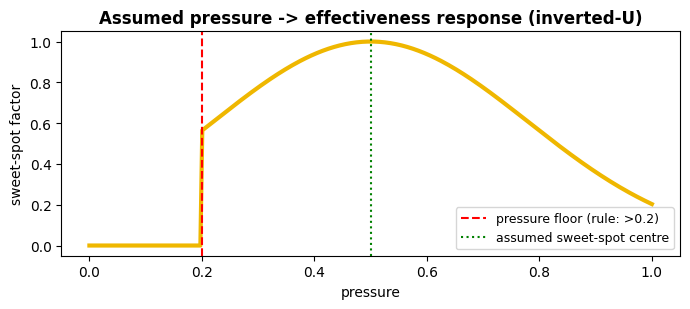

In [13]:
DEFAULT_RATES = {
    "skill_from_param_rate": 0.035,   # [assumption] speed at which parameters move skills
    "param_from_skill_rate": 0.03,    # [assumption] speed at which skills move parameters
    "param_from_param_rate": 0.03,    # [assumption] CLD parameter-parameter propagation speed
    "enforcement_decay": 0.985,       # [xlsx rule] enforcement must decrease over time -> exact rate is [assumption] - previously 0.985
    "reputation_penalty_weight": 0.15,     # [xlsx rule 28] -> exact weight is [assumption]
    "public_enforcement_boost": 1.15,      # [xlsx rule] enforcement more powerful for public actors
    "public_pressure_boost": 1.15,         # [xlsx rule] pressure application more powerful for public actors
    "private_competition_boost": 1.15,     # [xlsx rule] competition more powerful for private actors
    "pressure_sweet_spot_center": 0.5,     # [assumption] from the CLD picture's inverted-U sketch
    "pressure_sweet_spot_width": 0.28,     # [assumption] width of the effective sweet-spot band
    "pressure_floor": 0.2,                 # [xlsx rule] PPC requires pressure > 0.2
    "network_tie_dissolve_threshold": 0.15,   # [assumption] weak-tie dissolution cutoff
    "indicator_relaxation": 0.09,   # [assumption] homeostatic pull of relation parameters back to 0.5/step
    "skill_relaxation": 0.05,       # [assumption] homeostatic pull of skills back to their own baseline/step
}

def soft_gate(margin, k=18.0):
    """Continuous stand-in for a hard boolean rule ('X > Y' / 'X increasing').
    [assumption] A hard 0/1 gate makes the effectiveness surface discontinuous
    and impossible to optimise (one noisy micro-decrease anywhere permanently
    zeroes the score). A logistic function of the same margin keeps the rule's
    *meaning* but makes its enforcement continuous: comfortably-satisfied
    margins score near 1, comfortably-violated margins score near 0."""
    return float(1.0 / (1.0 + np.exp(-k * margin)))

def pressure_sweet_spot_factor(pressure, rates=DEFAULT_RATES):
    """[xlsx rule + assumption] 'Effective PPC requires pressure in a sweet
    spot: neither too high nor too low' (rules sheet) + the inverted-U sketch
    on the 'relation parameters' sheet. Implemented as a Gaussian bump peaking
    at `pressure_sweet_spot_center`, hard-zeroed below `pressure_floor` (the
    separate 'pressure > 0.2' rule)."""
    if pressure <= rates["pressure_floor"]:
        return 0.0
    z = (pressure - rates["pressure_sweet_spot_center"]) / rates["pressure_sweet_spot_width"]
    return float(np.exp(-0.5 * z ** 2))

# visualise the assumed sweet-spot response curve
xs = np.linspace(0, 1, 300)
ys = [pressure_sweet_spot_factor(x) for x in xs]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(xs, ys, color="#EFB700", linewidth=3)
ax.axvline(DEFAULT_RATES["pressure_floor"], color="red", linestyle="--", label="pressure floor (rule: >0.2)")
ax.axvline(DEFAULT_RATES["pressure_sweet_spot_center"], color="green", linestyle=":", label="assumed sweet-spot centre")
ax.set_xlabel("pressure"); ax.set_ylabel("sweet-spot factor")
ax.set_title("Assumed pressure -> effectiveness response (inverted-U)", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


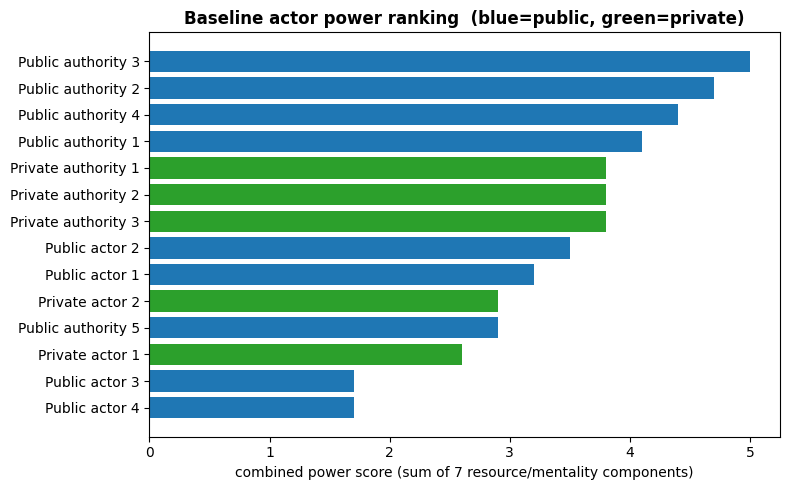

Most powerful actor at baseline: Public authority 3
Institutional participation check -- public: True | private: True | PoR/terminal authority: True | operational: True


In [14]:
def institution_flags(institutions_df):
    is_public = institutions_df["Public/Private"].str.contains("Public", case=False, na=False)
    authority_str = institutions_df["Scope of Authority (related to proximity)"].astype(str).str.lower()
    has_ct_por_authority = authority_str.str.contains("por|container")
    op_str = institutions_df["Strategic/Operational"].astype(str).str.lower()
    is_operational = op_str.str.contains("operational")
    return is_public, has_ct_por_authority, is_operational

def actor_power_scores(skills_state):
    """[xlsx rule] 'the most powerful node is the node with the highest combined
    score of risk mentality, economic capital, cultural capital, social capital,
    sense of urgency, formal responsibility and informal responsibility.'"""
    cols = ["Risk Mentality", "Economic Capital", "Cultural Capital", "Social Capital",
            "Sense of Urgency", "Formal responsibility", "Informal Responsibility"]
    return skills_state[cols].sum(axis=1)

is_public, has_authority, is_operational = institution_flags(data["institutions_df"])
power0 = actor_power_scores(data["skills_df"]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#1f77b4" if is_public.loc[a] else "#2ca02c" for a in power0.index]
ax.barh(power0.index[::-1], power0.values[::-1], color=colors[::-1])
ax.set_xlabel("combined power score (sum of 7 resource/mentality components)")
ax.set_title("Baseline actor power ranking  (blue=public, green=private)", fontweight="bold")
plt.tight_layout(); plt.show()

print("Most powerful actor at baseline:", power0.idxmax())
print("Institutional participation check -- public:", is_public.any(), "| private:", (~is_public).any(),
      "| PoR/terminal authority:", has_authority.any(), "| operational:", is_operational.any())


In [15]:
def actor_power_scores(skills_state):
    """
    Overall actor capability score.

    Positive skills contribute positively.
    Reputation contributes negatively (already stored as a negative value).
    Punishment mentality, enforcement and pressure are excluded because
    they influence cooperation through separate behavioural mechanisms.
    """
    cols = [
        "Risk Mentality",
        "Economic Capital",
        "Cultural Capital",
        "Social Capital",
        "Reputation",              # negative contribution
        "Sense of Urgency",
        "Formal responsibility",
        "Informal Responsibility",
    ]

    return skills_state[cols].sum(axis=1)

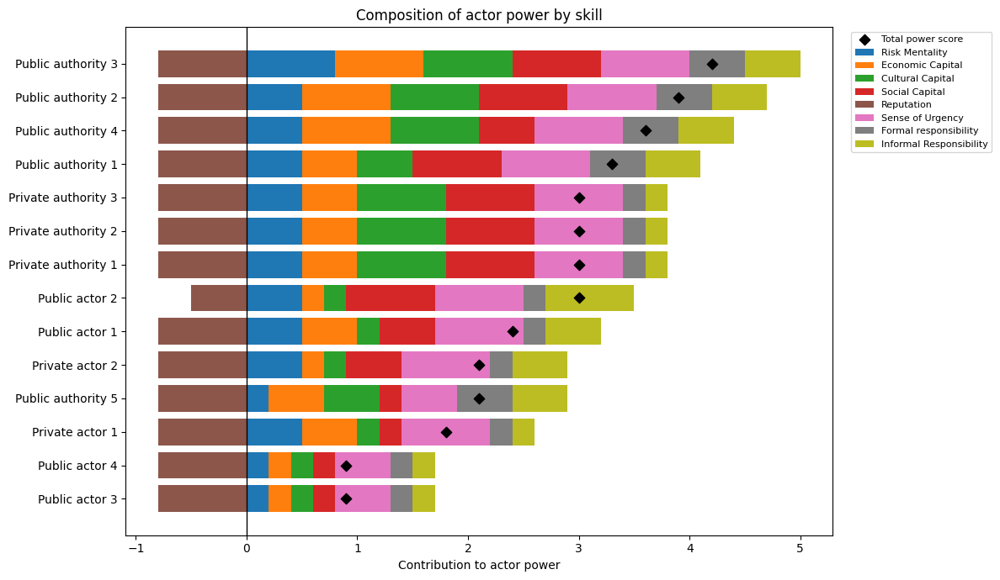

In [16]:
# Skills to visualise
plot_cols = [
    "Risk Mentality",
    "Economic Capital",
    "Cultural Capital",
    "Social Capital",
    "Reputation",              # negative values
    "Sense of Urgency",
    "Formal responsibility",
    "Informal Responsibility",
]

skill_colors = {
    "Risk Mentality": "#1f77b4",
    "Economic Capital": "#ff7f0e",
    "Cultural Capital": "#2ca02c",
    "Social Capital": "#d62728",
    "Reputation": "#8c564b",          # brown
    "Sense of Urgency": "#e377c2",
    "Formal responsibility": "#7f7f7f",
    "Informal Responsibility": "#bcbd22",
}


ranking = data["skills_df"][plot_cols].copy()
ranking["Power score"] = actor_power_scores(data["skills_df"])
ranking = ranking.sort_values("Power score")

fig, ax = plt.subplots(figsize=(12,7))

# Separate positive and negative contributions
left_pos = np.zeros(len(ranking))
left_neg = np.zeros(len(ranking))

for col in plot_cols:

    vals = ranking[col].values

    pos = np.where(vals > 0, vals, 0)
    neg = np.where(vals < 0, vals, 0)

    # Positive contributions
    ax.barh(
        ranking.index,
        pos,
        left=left_pos,
        label=col,
        color=skill_colors[col]
    )

    left_pos += pos

    # Negative contributions (only Reputation in your model)
    if np.any(neg):
        ax.barh(
            ranking.index,
            neg,
            left=left_neg,
            color=skill_colors[col],
            label="_nolegend_"
        )

        left_neg += neg

# Draw total power score
ax.scatter(
    ranking["Power score"],
    ranking.index,
    marker="D",
    s=40,
    color="black",
    label="Total power score",
    zorder=10
)

ax.axvline(0, color="black", linewidth=1)

ax.set_xlabel("Contribution to actor power")
ax.set_title("Composition of actor power by skill")

ax.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()

### Your current model treats pressure and enforcement differently from competition/cooperation/trust because the network construction only uses:

cooperation
competition
trust

Baseline network specification:
  n_actors: 14
  n_ties: 72
  density: 0.7912087912087912
  avg_clustering: 0.7967938302736163
  avg_degree: 10.285714285714286
  avg_tie_strength: 0.16549040210575153
  n_components: 1
  most_central_actor: Public actor 1


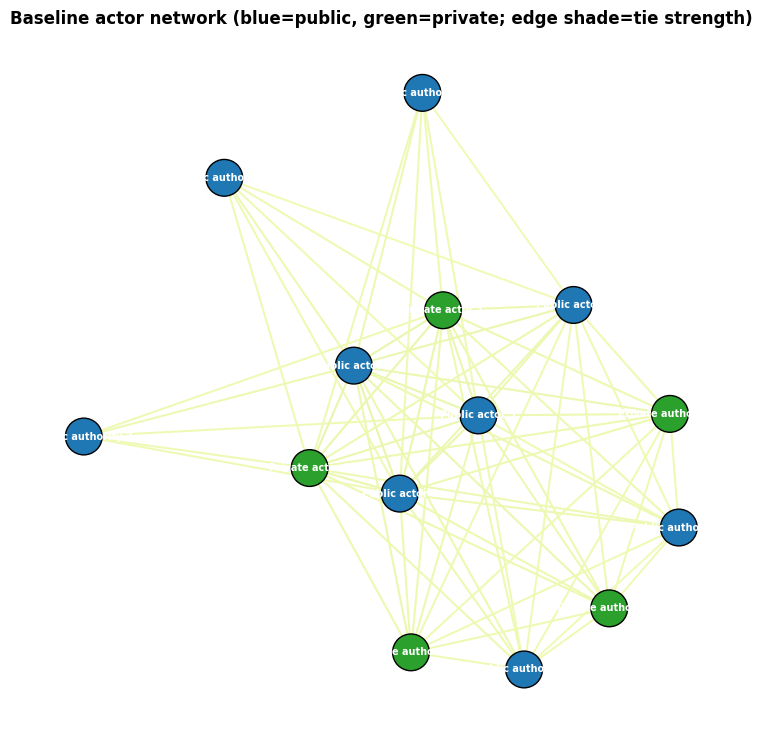

In [17]:


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def build_network(
    actor_names,
    actor_cooperation,
    actor_competition,
    trust,
    pressure=0.5,
    enforcement=0.5,
    rates=DEFAULT_RATES
):
    """
    Tie-formation probability between every pair of actors.

    [assumption] EXTENDED to use all 5 relation parameters, not just 3
    (cooperation/competition/trust). Previously pressure and enforcement
    only fed the CLD (parameter<->parameter) and skill<->parameter
    propagation, but never touched *who is tied to whom*. That wasn't a
    hard constraint of the workbook -- it was just that cooperation,
    competition and trust are the only parameters this notebook computes
    an affinity-like reading for at the pair level, while pressure and
    enforcement were only ever tracked as single network-wide indicators.
    Both can still enter the tie-formation logit as network-wide terms:

      - cooperation / competition: actor-level traits (unchanged), pull
        a given pair's tie probability up / down respectively.
      - trust: network-wide indicator (unchanged) that scales how much
        the pair's cooperation counts -- high trust amplifies
        cooperative pairs into ties, low trust mutes it.
      - enforcement (NEW): network-wide indicator, same polarity as
        competition (PARAM_ORIENTATION["enforcement"] == -1). Modelled
        as a uniform, top-down drag on tie formation -- heavy
        enforcement crowds out organic/informal peer ties across the
        whole network, regardless of any one pair's own
        cooperation/competition balance.
      - pressure (NEW): network-wide indicator with neutral polarity
        (PARAM_ORIENTATION["pressure"] == 0, "handled specially"
        everywhere else in this notebook). Consistent with how
        `signed()` treats pressure elsewhere (a damped 0.35x
        pass-through rather than a full +1/-1 effect), pressure gets a
        small, symmetric nudge around its neutral point (0.5) rather
        than a strong directional push either way.
    """
    G = nx.Graph()
    G.add_nodes_from(actor_names)

    enforcement_weight = 2.0   # [assumption] same sign as competition, smaller magnitude
    pressure_weight = 1.0      # [assumption] small & symmetric -- mirrors signed()'s damped treatment of pressure

    for i, a in enumerate(actor_names):
        for b in actor_names[i + 1:]:
            coop_avg = (actor_cooperation[a] + actor_cooperation[b]) / 2.0
            comp_avg = (actor_competition[a] + actor_competition[b]) / 2.0

            logit = (
                4.0 * (trust * coop_avg - comp_avg)
                - enforcement_weight * enforcement
                + pressure_weight * (pressure - 0.5)
            )
            prob = sigmoid(logit)

            if prob >= rates["network_tie_dissolve_threshold"]:
                G.add_edge(
                    a,
                    b,
                    weight=float(prob),
                    probability=float(prob)
                )

    return G


def compute_actor_relational_traits(skills_state, signed_skill_param):
    """
    [assumption]
    The workbook only scores relation parameters at the network (aggregate)
    level, not per actor.

    Each actor's individual cooperation/competition/trust propensity is
    derived endogenously from its OWN skill profile, using the same signed
    skill->parameter matrix that drives the aggregate CLD.

    Heterogeneity therefore comes from the workbook rather than from
    hand-picked actor-level numbers.
    """

    traits = {}

    for param in ["cooperation", "competition", "trust"]:
        w = signed_skill_param[param]

        contrib = (
            skills_state.sub(0.5)
            .mul(w, axis=1)
            .sum(axis=1)
            / w.abs().sum()
        )

        traits[param] = (
            0.5 + 0.5 * contrib
        ).clip(0, 1)

    return pd.DataFrame(traits)


def network_summary(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()

    degrees = dict(G.degree(weight=None))
    wdeg = dict(G.degree(weight="weight"))

    return {
        "n_actors": n,
        "n_ties": m,
        "density": nx.density(G),

        "avg_clustering": (
            nx.average_clustering(G, weight="weight")
            if n > 2 else 0.0
        ),

        "avg_degree": (
            np.mean(list(degrees.values()))
            if n else 0.0
        ),

        "avg_tie_strength": (
            np.mean(
                [d["weight"] for _, _, d in G.edges(data=True)]
            )
            if m else 0.0
        ),

        "n_components": nx.number_connected_components(G),

        "most_central_actor": (
            max(wdeg, key=wdeg.get)
            if wdeg else None
        ),
    }


# ---- baseline network (t=0, indicators at neutral 0.5) ----

traits0 = compute_actor_relational_traits(
    data["skills_df"],
    signed_skill_param
)

G0 = build_network(
    list(data["skills_df"].index),
    traits0["cooperation"],
    traits0["competition"],
    trust=0.5,
    pressure=0.5,
    enforcement=0.5
)


summary0 = network_summary(G0)

print("Baseline network specification:")

for k, v in summary0.items():
    print(f"  {k}: {v}")


# ---- network visualization ----

fig, ax = plt.subplots(figsize=(7.5, 7.5))

pos = nx.spring_layout(
    G0,
    seed=42,
    weight="weight"
)

node_colors = [
    "#1f77b4" if is_public.loc[a] else "#2ca02c"
    for a in G0.nodes()
]

weights = [
    G0[u][v]["weight"]
    for u, v in G0.edges()
]


nx.draw_networkx_nodes(
    G0,
    pos,
    node_color=node_colors,
    node_size=700,
    edgecolors="black",
    ax=ax
)

nx.draw_networkx_labels(
    G0,
    pos,
    font_size=7,
    font_color="white",
    font_weight="bold",
    ax=ax
)

nx.draw_networkx_edges(
    G0,
    pos,
    width=[1 + 3 * w for w in weights],
    edge_color=weights,
    edge_cmap=plt.cm.YlGn,
    edge_vmin=0,
    edge_vmax=1,
    ax=ax
)

ax.set_title(
    "Baseline actor network "
    "(blue=public, green=private; edge shade=tie strength)",
    fontweight="bold"
)

ax.axis("off")

plt.tight_layout()
plt.show()


### timespan

### end of timespan

In [18]:
def init_state(data, initial_indicators=None):
    """[assumption] EXTENDED to accept a starting-point for the 5 relation
    indicators (e.g. one of the `initial_scenarios` dicts) instead of always
    starting neutral at 0.5. Any parameter missing from `initial_indicators`
    still defaults to 0.5."""
    skills_state = data["skills_df"].copy(deep=True)
    if initial_indicators is None:
        indicators = {p: 0.5 for p in RELATION_PARAMS}
    else:
        # indicators = {p: float(initial_indicators.get(p, 0.5)) for p in RELATION_PARAMS}
        indicators = initial_indicators.copy()
    return skills_state, indicators

def apply_shock(skills_state, indicators, shock, actor_names):
    """shock: dict like {'pressure': +0.2, 'trust': -0.35,
    'Private actor 1:Reputation': -0.3, 'Economic Capital': +0.1}"""
    for target, val in shock.items():
        if target in indicators:
            indicators[target] = float(np.clip(indicators[target] + val, 0, 1))
        elif ":" in target:
            actor, skill = [t.strip() for t in target.split(":")]
            match = [a for a in actor_names if a.lower() == actor.lower()]
            if match and skill in skills_state.columns:
                skills_state.loc[match[0], skill] = np.clip(skills_state.loc[match[0], skill] + val, 0, 1)
        elif target in skills_state.columns:
            skills_state[target] = np.clip(skills_state[target] + val, 0, 1)
    return skills_state, indicators

def actor_power_scores_(skills_state):
    return actor_power_scores(skills_state)

def run_simulation(
    data,
    signed_matrices,
    shocks=None,
    steps=40,
    rates=None,
    pinned_pressure=None,
    initial_indicators=None,
    seed=42
):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    """One step = 3 months. `shocks`: {step: {target: delta}}.
    `pinned_pressure`: if given, pressure is held at this SUSTAINED level all
    run (a deliberate, ongoing policy stance) instead of being left to freely
    evolve/relax -- this is what the pressure sweet-spot search sweeps over."""
    rates = rates or DEFAULT_RATES
    shocks = shocks or {}
    signed_rel_rel, signed_skill_param, signed_param_skill = signed_matrices

    skills_state, indicators = init_state(data, initial_indicators)

    print("skills_state memory:", id(skills_state))
    print("original data memory:", id(data["skills_df"]))

    print("=" * 50)
    print("Starting simulation")
    print("Indicators:", indicators)
    print("Average skill:", skills_state.mean().mean())


    skills_baseline = skills_state.copy()
    actor_names = list(skills_state.index)
    is_public, has_authority, is_operational = institution_flags(data["institutions_df"])
    is_private = ~is_public

    history = []

    for t in range(steps):
        if t in shocks:
            skills_state, indicators = apply_shock(skills_state, indicators, shocks[t], actor_names)
        if pinned_pressure is not None:
            indicators["pressure"] = float(np.clip(pinned_pressure, 0, 1))

# We got a problem here: 
        # ---- 0b. homeostatic relaxation [assumption -- see rates cell] -----------------
        for p in RELATION_PARAMS:
            if p == "enforcement":
                continue
            indicators[p] = 0.5 + (indicators[p] - 0.5) * (1 - rates["indicator_relaxation"])
        skills_state = skills_baseline + (skills_state - skills_baseline) * (1 - rates["skill_relaxation"])

        # ---- 1. enforcement decay [xlsx rule] -------------------------------------------
        indicators["enforcement"] = float(np.clip(indicators["enforcement"] * rates["enforcement_decay"], 0, 1))

        #The other 4 parameters relax gently back toward 0.5 each step. Enforcement instead gets multiplied by 0.985 every single step, 
        # unconditionally — a one-way decay toward 0, not 0.5. That's marked [xlsx rule] enforcement must decrease over time, 
        # so it looks like a deliberate encoding of a real rule in your source workbook (e.g. "enforcement actions fade unless renewed").
# Enforcement does still receive input from the cross-parameter CLD term (step 14, signed_rel_rel) and, 
# now, from build_network's tie-formation logit — it's not literally disconnected from the model. But in this run, 
# that decay (~1.5%/step, compounding to a big drop over 20 steps) is clearly stronger than whatever the CLD pushes back in, so 
# enforcement ends up tracing almost the same downward curve regardless of which parameter was shocked. The shock to enforcement itself (rightmost panel) 
# just adds an extra one-time drop on top of the same decay trajectory.

        # ---- 2. institutional validity gate [xlsx rule] ---------------------------------
        structural_valid = float(is_public.any() and is_private.any() and has_authority.any() and is_operational.any())

        # ---- 3. most powerful node [xlsx rule] ------------------------------------------
        power = actor_power_scores(skills_state)
        dominant_node = power.idxmax()
        dominant_is_public = bool(is_public.loc[dominant_node])

        # ---- 4. actor-level traits + power modifiers [xlsx rule] ------------------------
        traits = compute_actor_relational_traits(skills_state, signed_skill_param)
        pub_enf_mod = rates["public_enforcement_boost"] if dominant_is_public else 1.0
        pub_press_mod = rates["public_pressure_boost"] if dominant_is_public else 1.0
        priv_comp_mod = rates["private_competition_boost"] if not dominant_is_public else 1.0

        effective_competition = float(np.clip(indicators["competition"] * priv_comp_mod, 0, 1))
        effective_pressure = float(np.clip(indicators["pressure"] * pub_press_mod, 0, 1))
        effective_enforcement = float(np.clip(indicators["enforcement"] * pub_enf_mod, 0, 1))

        # ---- 5. network rewiring ---------------------------------------------------------
        G = build_network(actor_names, traits["cooperation"], traits["competition"] * priv_comp_mod,
                           indicators["trust"], effective_pressure, effective_enforcement, rates)

        # ---- 6. mentality / resource gates [xlsx rule] -----------------------------------
        risk_mean = skills_state["Risk Mentality"].mean()
        punish_mean = skills_state["Punishment Mentality"].mean()
        mentality_ok = soft_gate(risk_mean - punish_mean) * soft_gate(risk_mean)
        resources_ok = (soft_gate(skills_state["Economic Capital"].mean()) *
                         soft_gate(skills_state["Cultural Capital"].mean()) *
                         soft_gate(skills_state["Social Capital"].mean()) *
                         soft_gate(skills_state["Sense of Urgency"].mean()))

        # ---- 7. trend gates over a 1-year (4-step) window [xlsx rule] -------------------
        window = 4
        ref = history[-window]["indicators"] if len(history) >= window else (history[0]["indicators"] if history else indicators)
        trust_trend_ok = soft_gate(indicators["trust"] - ref["trust"]) * soft_gate(indicators["trust"])
        coop_trend_ok = soft_gate(indicators["cooperation"] - ref["cooperation"]) * soft_gate(indicators["cooperation"])
        coop_vs_comp_ok = soft_gate(indicators["cooperation"] - effective_competition)

        # ---- 8. pressure sweet spot [xlsx rule] ------------------------------------------
        press_factor = pressure_sweet_spot_factor(effective_pressure, rates)

        # ---- 9. reputation penalty [xlsx rule 28] ----------------------------------------
        reputation_penalty = skills_state["Reputation"].mean() * rates["reputation_penalty_weight"]

        # ---- 10. formal ~ informal responsibility [xlsx rule 29] -------------------------
        responsibility_term = (skills_state["Formal responsibility"].mean() +
                                skills_state["Informal Responsibility"].mean()) / 2.0

        # ---- 11. PPC EFFECTIVENESS SCORE -------------------------------------------------
        raw_eff = (
            structural_valid * press_factor *
            (0.25 * trust_trend_ok + 0.25 * coop_trend_ok + 0.20 * coop_vs_comp_ok +
             0.15 * mentality_ok + 0.15 * resources_ok) *
            (0.5 + 0.5 * responsibility_term)
        ) - reputation_penalty
        ppc_effectiveness = float(np.clip(raw_eff, 0, 1))

        history.append({
            "t": t, "skills": skills_state.copy(), "indicators": indicators.copy(), "network": G,
            "dominant_node": dominant_node, "structural_valid": structural_valid,
            "press_factor": press_factor, "ppc_effectiveness": ppc_effectiveness, "traits": traits.copy(),
            "modifiers": {"public_enforcement_boost": pub_enf_mod, "public_pressure_boost": pub_press_mod,
                          "private_competition_boost": priv_comp_mod},
        })

        # ---- 12. PROPAGATION: parameter -> skill [xlsx structure] ------------------------
        effective_values = {**indicators, "enforcement": effective_enforcement,
                             "pressure": effective_pressure, "competition": effective_competition}
        for p in RELATION_PARAMS:
            dev = effective_values[p] - 0.5
            for s in signed_param_skill.columns:
                w = signed_param_skill.loc[p, s]
                if pd.notna(w) and w != 0:
                    skills_state[s] = np.clip(skills_state[s] + dev * w * rates["skill_from_param_rate"], 0, 1)

        # ---- 13. PROPAGATION: skill -> parameter [xlsx structure] ------------------------
        for s in signed_skill_param.index:
            dev = skills_state[s].mean() - 0.5
            for p in RELATION_PARAMS:
                w = signed_skill_param.loc[s, p]
                if pd.notna(w) and w != 0:
                    indicators[p] = float(np.clip(indicators[p] + dev * w * rates["param_from_skill_rate"], 0, 1))

        # ---- 14. PROPAGATION: parameter <-> parameter (CLD core) [xlsx structure] --------
        new_indicators = indicators.copy()
        for i in RELATION_PARAMS:
            dev = indicators[i] - 0.5
            for j in RELATION_PARAMS:
                if i == j:
                    continue
                w = signed_rel_rel.loc[i, j]
                if pd.notna(w) and w != 0:
                    new_indicators[j] = float(np.clip(new_indicators[j] + dev * w * rates["param_from_param_rate"], 0, 1))
        indicators = new_indicators
        if pinned_pressure is not None:
            indicators["pressure"] = float(np.clip(pinned_pressure, 0, 1))

    return history

print("run_simulation defined.")


run_simulation defined.


Before baseline: 0.37792207792207794
skills_state memory: 1424096775776
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.5, 'cooperation': 0.5, 'trust': 0.5, 'pressure': 0.5, 'enforcement': 0.5}
Average skill: 0.37792207792207794


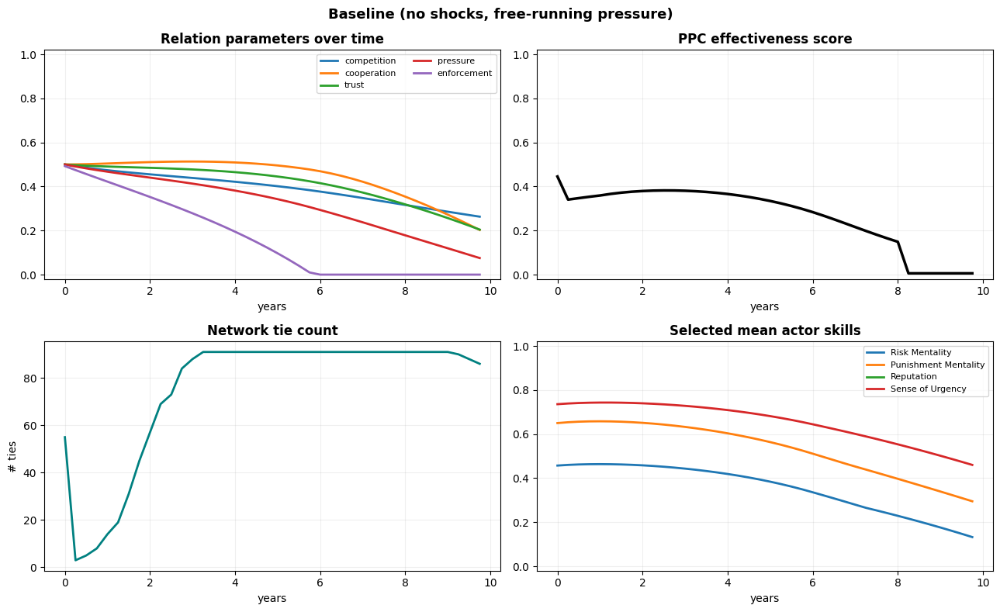

Equilibrium reached: False at step 39 (~9.8 years)
Final PPC effectiveness: 0.006
Final network ties: 86 (baseline was 72)


In [19]:
def find_equilibrium(history, tol=1e-3):
    for t in range(1, len(history)):
        prev = np.array(list(history[t - 1]["indicators"].values()))
        curr = np.array(list(history[t]["indicators"].values()))
        if np.linalg.norm(curr - prev) < tol:
            return t, True
    return len(history) - 1, False

STEPS = 40  # 40 x 3 months = 10 years
print(
    "Before baseline:",
    data["skills_df"].mean().mean()
)
baseline_history = run_simulation(data, signed_matrices, steps=STEPS, seed=42)

def plot_run(history, title):
    t_years = [h["t"] * 3 / 12 for h in history]
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))

    ax = axes[0, 0]
    for p in RELATION_PARAMS:
        ax.plot(t_years, [h["indicators"][p] for h in history], label=p, linewidth=2)
    ax.set_title("Relation parameters over time", fontweight="bold")
    ax.set_xlabel("years"); ax.set_ylim(-0.02, 1.02); ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.2)

    ax = axes[0, 1]
    ax.plot(t_years, [h["ppc_effectiveness"] for h in history], color="black", linewidth=2.5)
    ax.set_title("PPC effectiveness score", fontweight="bold")
    ax.set_xlabel("years"); ax.set_ylim(-0.02, 1.02); ax.grid(alpha=0.2)

    ax = axes[1, 0]
    ax.plot(t_years, [h["network"].number_of_edges() for h in history], color="teal", linewidth=2)
    ax.set_title("Network tie count", fontweight="bold")
    ax.set_xlabel("years"); ax.set_ylabel("# ties"); ax.grid(alpha=0.2)

    ax = axes[1, 1]
    mean_skills = pd.DataFrame([h["skills"].mean() for h in history])
    for col in ["Risk Mentality", "Punishment Mentality", "Reputation", "Sense of Urgency"]:
        ax.plot(t_years, mean_skills[col], label=col, linewidth=2)
    ax.set_title("Selected mean actor skills", fontweight="bold")
    ax.set_xlabel("years"); ax.set_ylim(-0.02, 1.02); ax.legend(fontsize=8); ax.grid(alpha=0.2)

    fig.suptitle(title, fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.show()

plot_run(baseline_history, "Baseline (no shocks, free-running pressure)")

eq_t, reached = find_equilibrium(baseline_history)
print(f"Equilibrium reached: {reached} at step {eq_t} (~{eq_t*3/12:.1f} years)")
print(f"Final PPC effectiveness: {baseline_history[-1]['ppc_effectiveness']:.3f}")
print(f"Final network ties: {baseline_history[-1]['network'].number_of_edges()} "
      f"(baseline was {summary0['n_ties']})")


In [20]:
# Only plot first 5 years
max_years = 5

t_years = [
    h["t"] * 3 / 12
    for h in baseline_history
    if h["t"] * 3 / 12 <= max_years
]

baseline_history_5y = [
    h
    for h in baseline_history
    if h["t"] * 3 / 12 <= max_years
]

skills_state memory: 1424092804976
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.5, 'cooperation': 0.5, 'trust': 0.5, 'pressure': 0.5, 'enforcement': 0.5}
Average skill: 0.37792207792207794


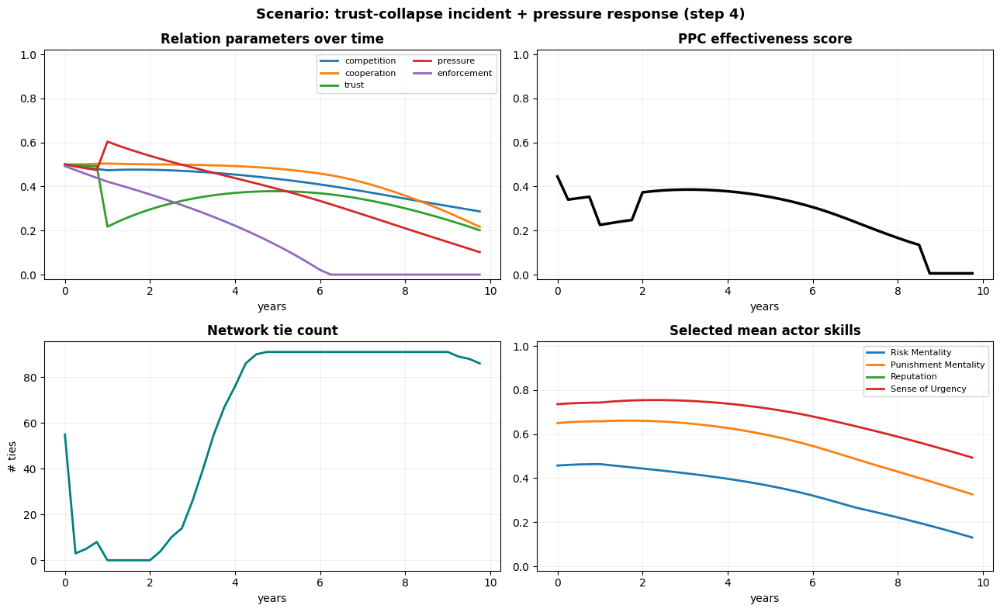

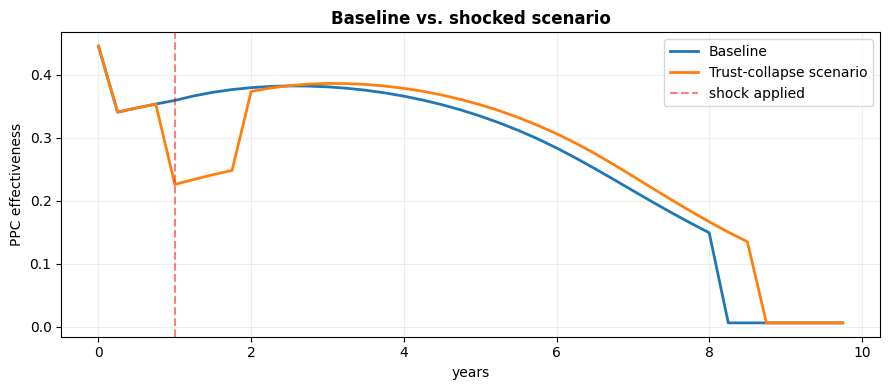

In [21]:
example_shocks = {
    4: {                      # step 4 = 1 year in
        "trust": -0.30,       # a corruption incident erodes network-wide trust
        "pressure": +0.15,    # regulators respond with heightened scrutiny
    },
}
shock_history = run_simulation(data, signed_matrices, steps=STEPS, shocks=example_shocks, seed=42)
plot_run(shock_history, "Scenario: trust-collapse incident + pressure response (step 4)")

fig, ax = plt.subplots(figsize=(9, 4))
t_years = [h["t"] * 3 / 12 for h in baseline_history]
ax.plot(t_years, [h["ppc_effectiveness"] for h in baseline_history], label="Baseline", linewidth=2)
ax.plot(t_years, [h["ppc_effectiveness"] for h in shock_history], label="Trust-collapse scenario", linewidth=2)
ax.axvline(4 * 3 / 12, color="red", linestyle="--", alpha=0.5, label="shock applied")
ax.set_xlabel("years"); ax.set_ylabel("PPC effectiveness")
ax.set_title("Baseline vs. shocked scenario", fontweight="bold")
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()


## here all shocks in -0.15, -0.3, +0.15 and +0.3

In [22]:
shock_values = [-0.15, -0.30, +0.15, +0.30]

individual_shocks = {}

step = 4  # shock applied at step 4 (1 year in)

for param in RELATION_PARAMS:
    for value in shock_values:
        scenario_name = f"{param}_{value:+.2f}"
        individual_shocks[scenario_name] = {
            step: {
                param: value
            }
        }

individual_shocks

{'competition_-0.15': {4: {'competition': -0.15}},
 'competition_-0.30': {4: {'competition': -0.3}},
 'competition_+0.15': {4: {'competition': 0.15}},
 'competition_+0.30': {4: {'competition': 0.3}},
 'cooperation_-0.15': {4: {'cooperation': -0.15}},
 'cooperation_-0.30': {4: {'cooperation': -0.3}},
 'cooperation_+0.15': {4: {'cooperation': 0.15}},
 'cooperation_+0.30': {4: {'cooperation': 0.3}},
 'trust_-0.15': {4: {'trust': -0.15}},
 'trust_-0.30': {4: {'trust': -0.3}},
 'trust_+0.15': {4: {'trust': 0.15}},
 'trust_+0.30': {4: {'trust': 0.3}},
 'pressure_-0.15': {4: {'pressure': -0.15}},
 'pressure_-0.30': {4: {'pressure': -0.3}},
 'pressure_+0.15': {4: {'pressure': 0.15}},
 'pressure_+0.30': {4: {'pressure': 0.3}},
 'enforcement_-0.15': {4: {'enforcement': -0.15}},
 'enforcement_-0.30': {4: {'enforcement': -0.3}},
 'enforcement_+0.15': {4: {'enforcement': 0.15}},
 'enforcement_+0.30': {4: {'enforcement': 0.3}}}

In [23]:
shock_histories = {}

for name, shocks in individual_shocks.items():
    shock_histories[name] = run_simulation(
        data,
        signed_matrices,
        steps=STEPS,
        shocks=shocks
    )

skills_state memory: 1424152155136
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.5, 'cooperation': 0.5, 'trust': 0.5, 'pressure': 0.5, 'enforcement': 0.5}
Average skill: 0.37792207792207794
skills_state memory: 1424169060352
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.5, 'cooperation': 0.5, 'trust': 0.5, 'pressure': 0.5, 'enforcement': 0.5}
Average skill: 0.37792207792207794
skills_state memory: 1424162206640
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.5, 'cooperation': 0.5, 'trust': 0.5, 'pressure': 0.5, 'enforcement': 0.5}
Average skill: 0.37792207792207794
skills_state memory: 1424169065680
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.5, 'cooperation': 0.5, 'trust': 0.5, 'pressure': 0.5, 'enforcement': 0.5}
Average skill: 0.37792207792207794
skills_state memory: 1424162413008
original data memory: 1424096066064
Starting 

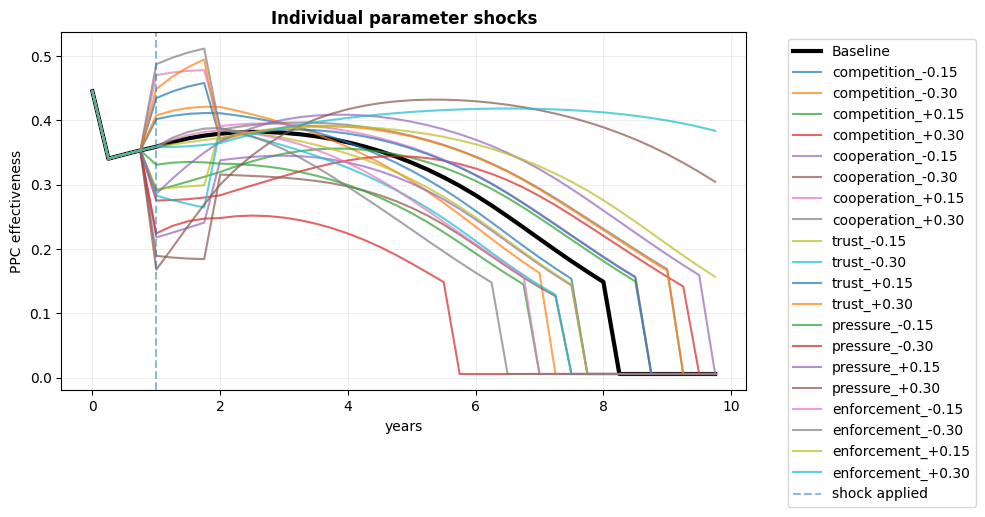

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

t_years = [h["t"] * 3 / 12 for h in baseline_history]

ax.plot(
    t_years,
    [h["ppc_effectiveness"] for h in baseline_history],
    label="Baseline",
    linewidth=3,
    color="black"
)

for name, history in shock_histories.items():
    ax.plot(
        t_years,
        [h["ppc_effectiveness"] for h in history],
        label=name,
        alpha=0.7
    )

ax.axvline(
    4 * 3 / 12,
    linestyle="--",
    alpha=0.5,
    label="shock applied"
)

ax.set_xlabel("years")
ax.set_ylabel("PPC effectiveness")
ax.set_title("Individual parameter shocks", fontweight="bold")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

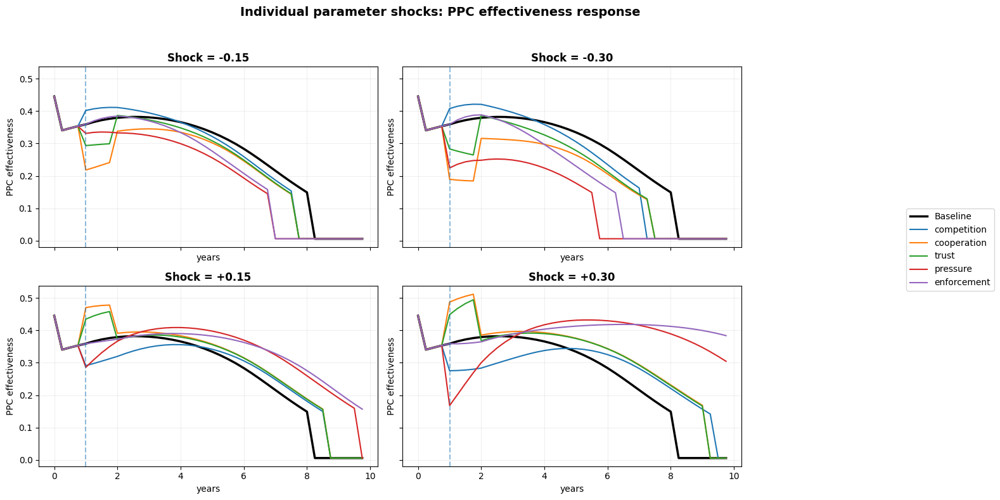

In [25]:


shock_values = [-0.15, -0.30, +0.15, +0.30]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

axes = axes.flatten()

t_years = [h["t"] * 3 / 12 for h in baseline_history]

for ax, shock_value in zip(axes, shock_values):

    # Baseline
    ax.plot(
        t_years,
        [h["ppc_effectiveness"] for h in baseline_history],
        label="Baseline",
        linewidth=2.5,
        color="black"
    )

    # All parameters with this shock magnitude
    for param in RELATION_PARAMS:
        scenario_name = f"{param}_{shock_value:+.2f}"

        history = shock_histories[scenario_name]

        ax.plot(
            t_years,
            [h["ppc_effectiveness"] for h in history],
            label=param
        )

    ax.axvline(
        4 * 3 / 12,
        linestyle="--",
        alpha=0.5
    )

    ax.set_title(
        f"Shock = {shock_value:+.2f}",
        fontweight="bold"
    )

    ax.grid(alpha=0.2)
    ax.set_xlabel("years")
    ax.set_ylabel("PPC effectiveness")


# One shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

fig.suptitle(
    "Individual parameter shocks: PPC effectiveness response",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

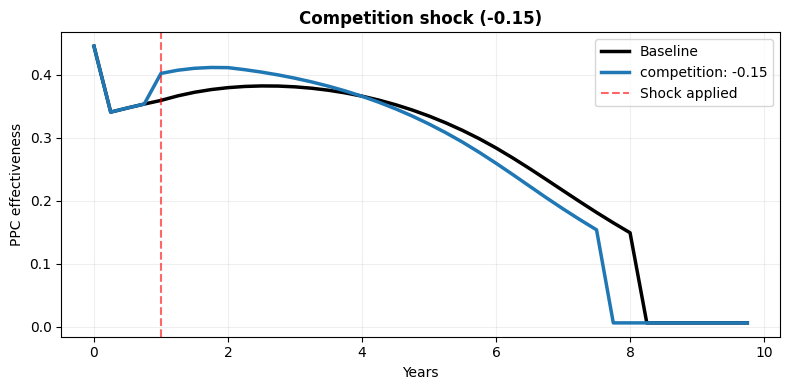

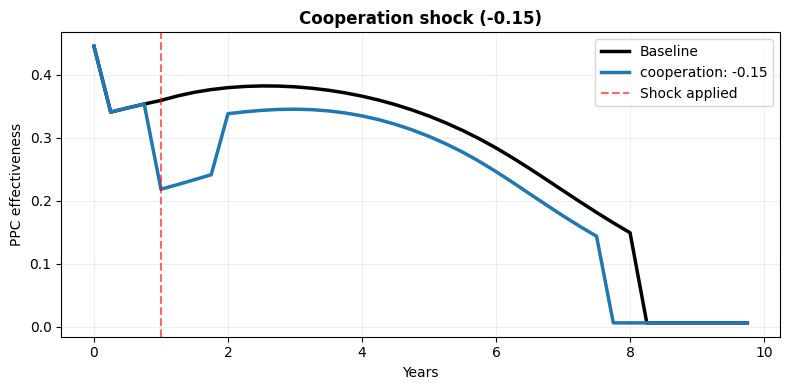

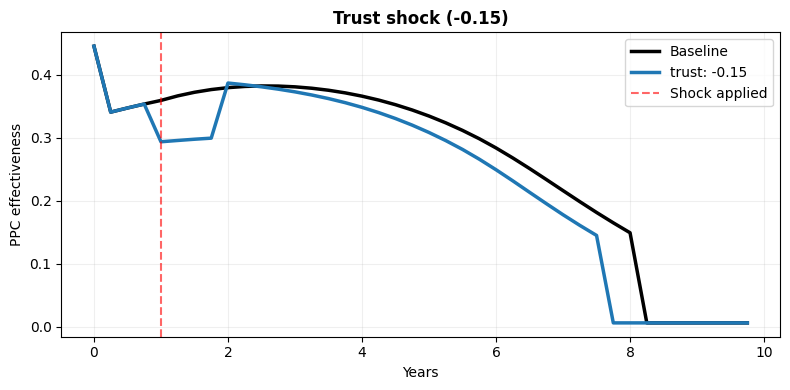

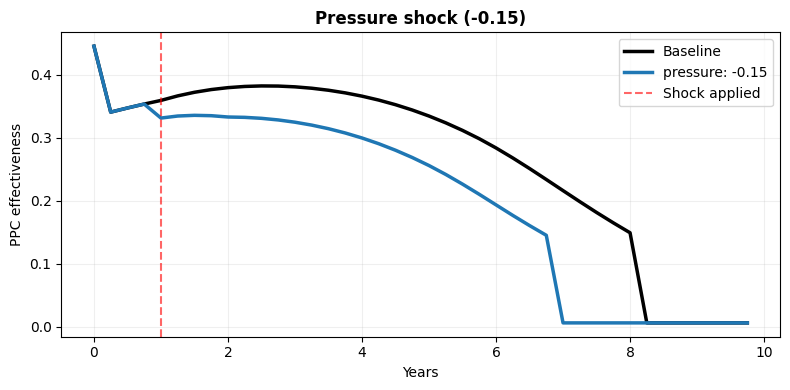

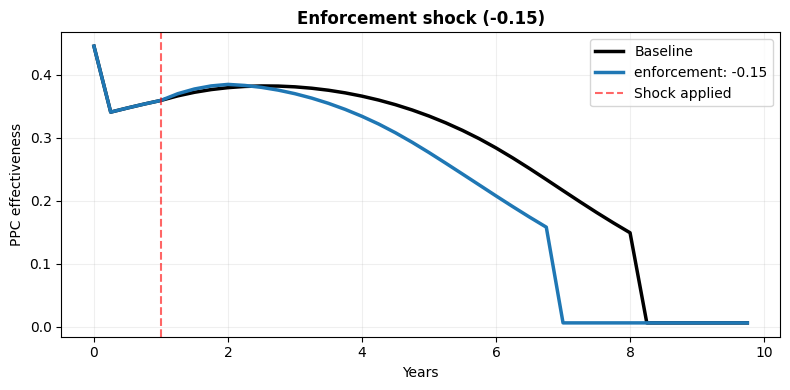

...

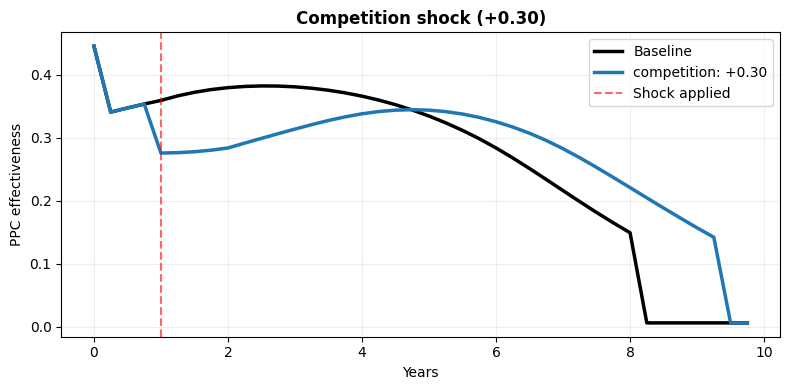

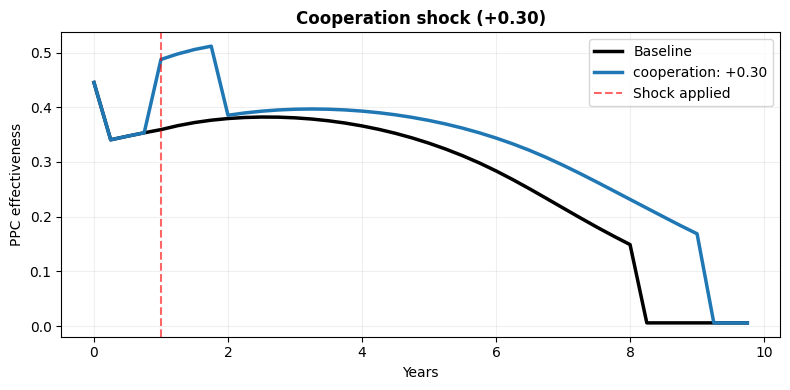

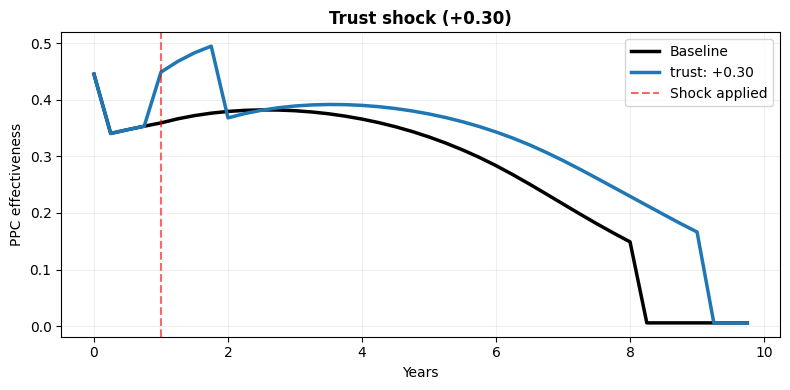

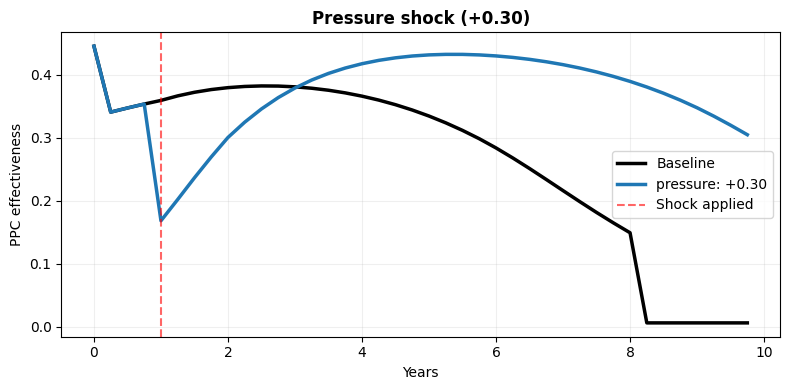

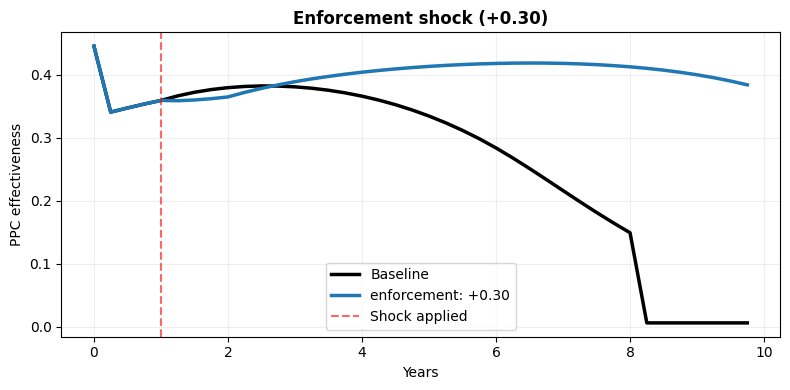

In [26]:
shock_values = [-0.15, -0.30, +0.15, +0.30]

t_years = [h["t"] * 3 / 12 for h in baseline_history]

for shock_value in shock_values:
    for param in RELATION_PARAMS:

        scenario_name = f"{param}_{shock_value:+.2f}"
        history = shock_histories[scenario_name]

        fig, ax = plt.subplots(figsize=(8, 4))

        # Baseline
        ax.plot(
            t_years,
            [h["ppc_effectiveness"] for h in baseline_history],
            label="Baseline",
            color="black",
            linewidth=2.5
        )

        # Shocked scenario
        ax.plot(
            t_years,
            [h["ppc_effectiveness"] for h in history],
            label=f"{param}: {shock_value:+.2f}",
            linewidth=2.5
        )

        # Shock timing
        ax.axvline(
            4 * 3 / 12,
            color="red",
            linestyle="--",
            alpha=0.6,
            label="Shock applied"
        )

        ax.set_title(
            f"{param.capitalize()} shock ({shock_value:+.2f})",
            fontweight="bold"
        )
        ax.set_xlabel("Years")
        ax.set_ylabel("PPC effectiveness")
        ax.grid(alpha=0.2)
        ax.legend()

        plt.tight_layout()
        plt.show()

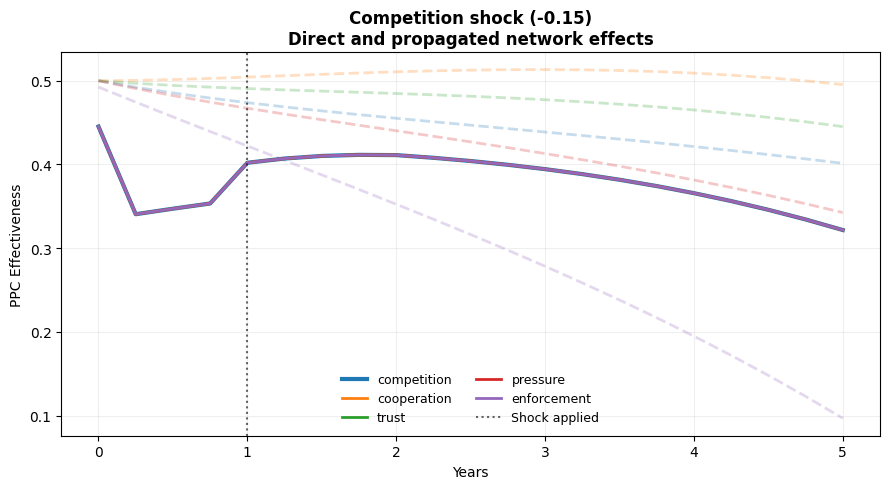

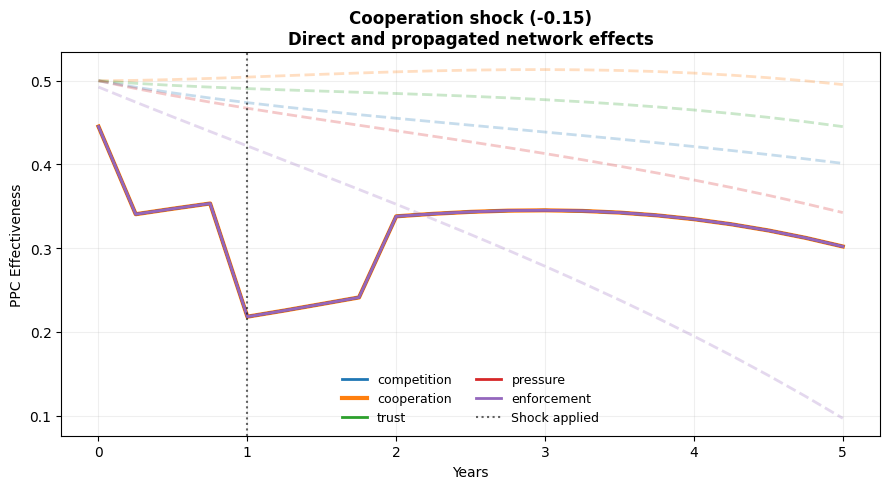

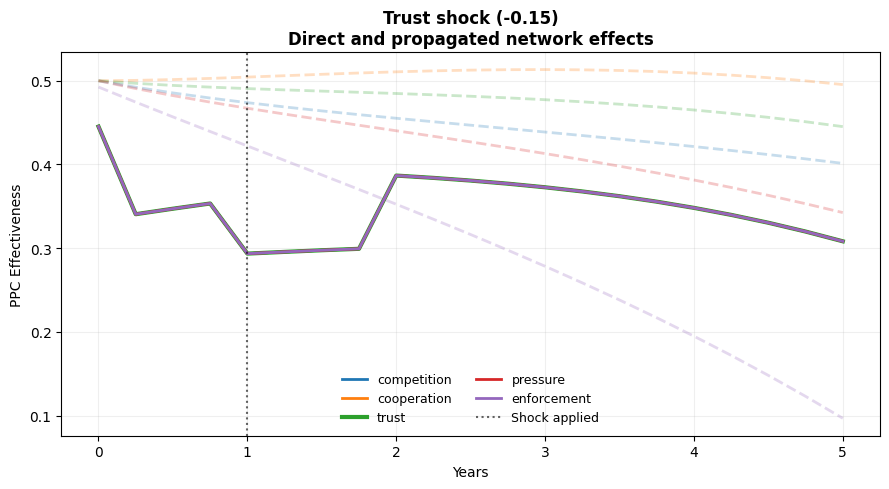

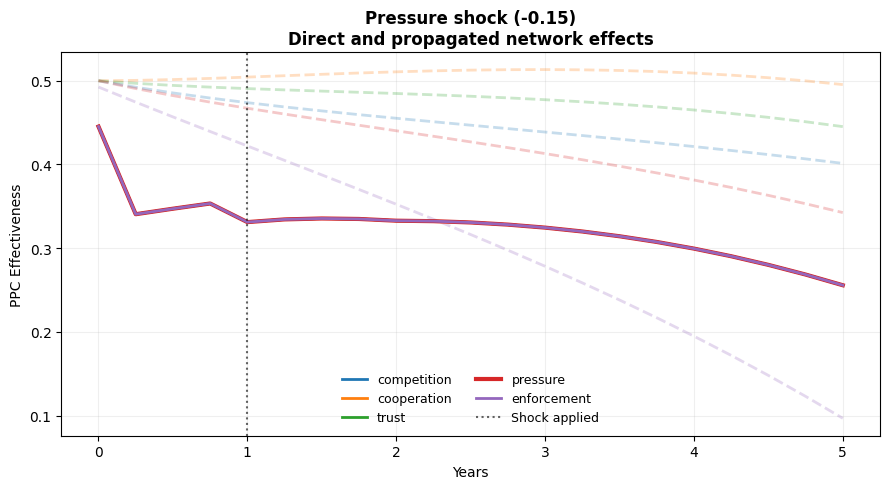

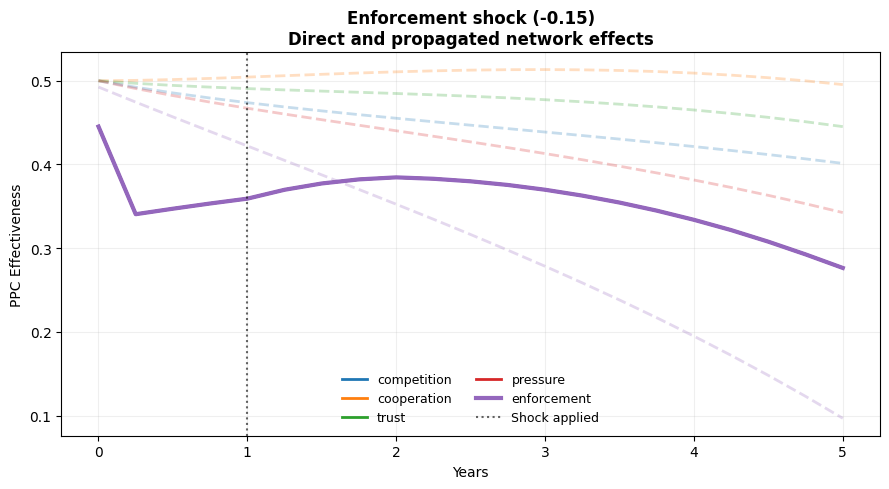

...

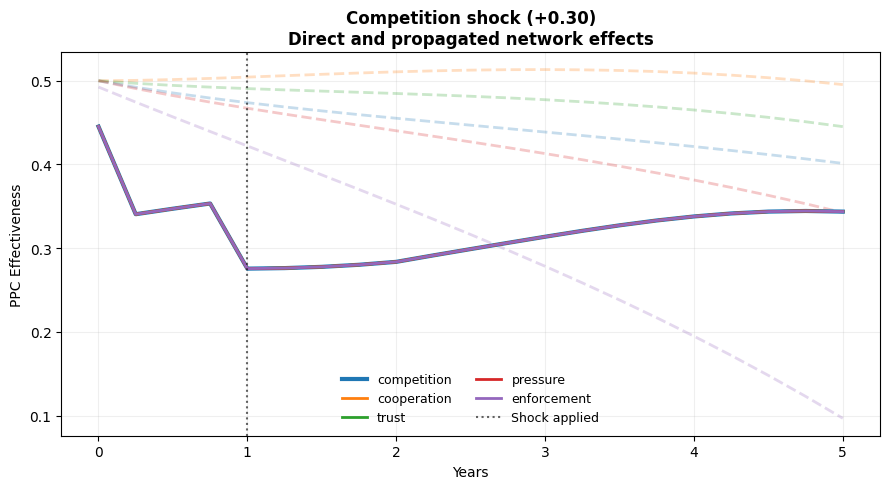

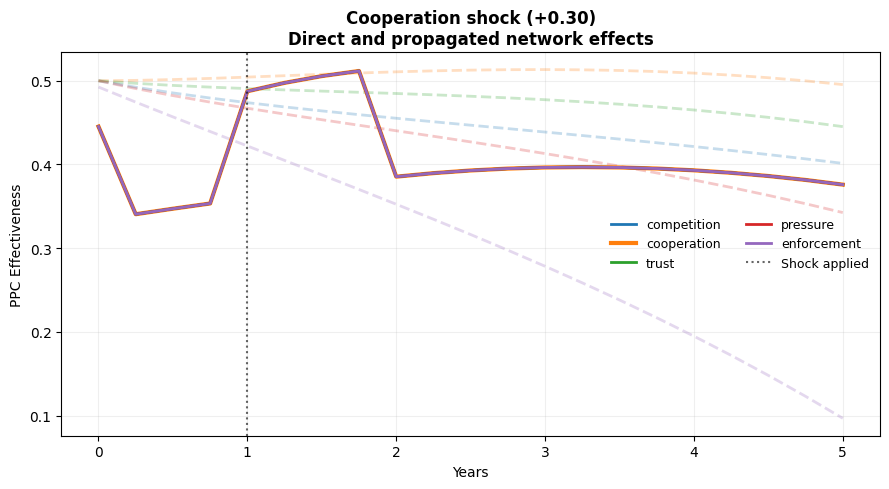

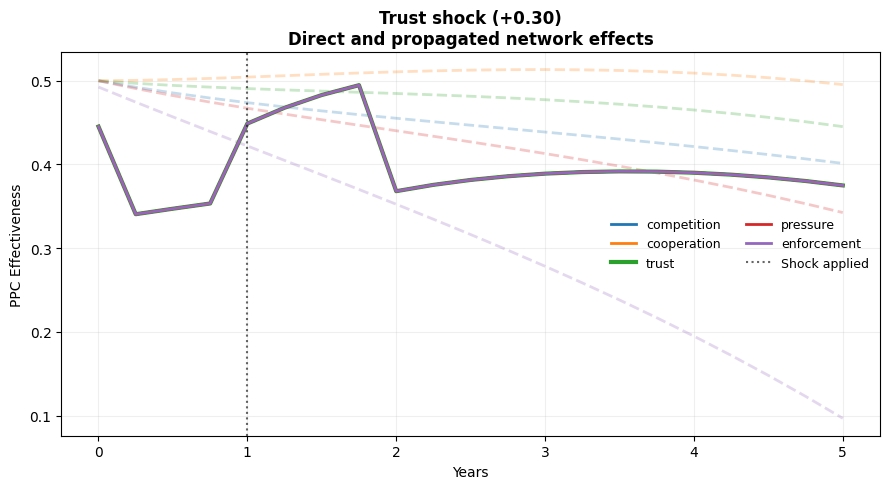

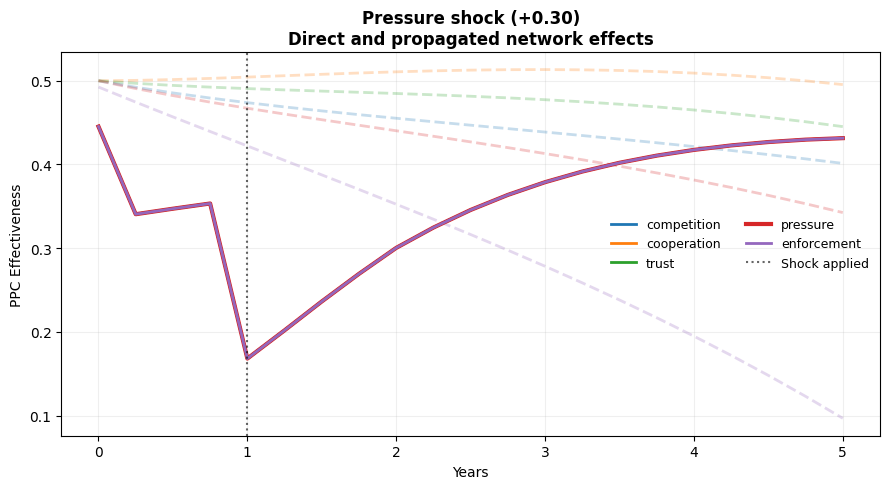

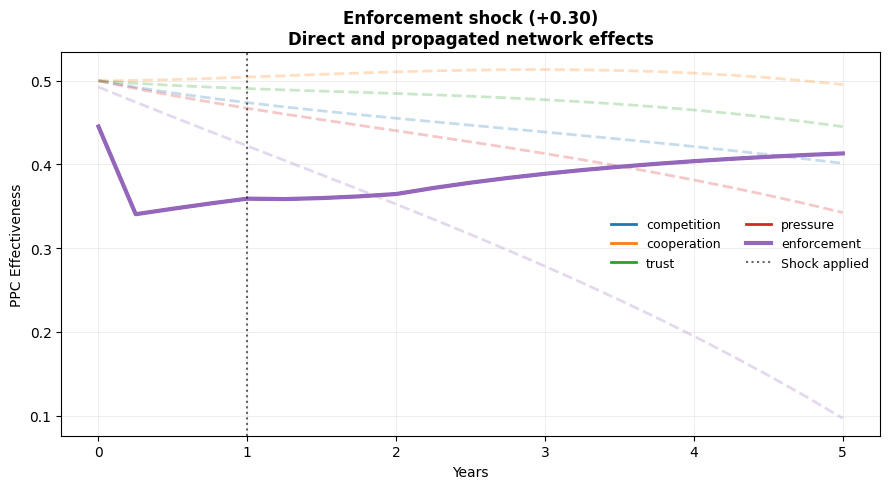

In [27]:


shock_values = [-0.15, -0.30, +0.15, +0.30]

param_colors = {
    "competition": "tab:blue",
    "cooperation": "tab:orange",
    "trust": "tab:green",
    "pressure": "tab:red",
    "enforcement": "tab:purple"
}

#t_years = [h["t"] * 3 / 12 for h in baseline_history]
# Only plot first 5 years
max_years = 5

t_years = [
    h["t"] * 3 / 12
    for h in baseline_history
    if h["t"] * 3 / 12 <= max_years
]

baseline_history_5y = [
    h
    for h in baseline_history
    if h["t"] * 3 / 12 <= max_years
]


for shock_value in shock_values:

    for shocked_param in RELATION_PARAMS:

        scenario_name = f"{shocked_param}_{shock_value:+.2f}"
        #history = shock_histories[scenario_name]
        history = [
            h
            for h in shock_histories[scenario_name]
            if h["t"] * 3 / 12 <= max_years
        ]

        fig, ax = plt.subplots(figsize=(9, 5))


        # =========================================
        # BASELINE: no shock (muted dashed lines)
        # =========================================
        for param in RELATION_PARAMS:

            baseline_values = [
                h["indicators"][param]
                for h in baseline_history_5y
            ]

            ax.plot(
                t_years,
                baseline_values,
                color=param_colors[param],
                alpha=0.25,
                linestyle="--",
                linewidth=2
            )


        # =========================================
        # SHOCKED RUN: all parameters
        # =========================================
        for param in RELATION_PARAMS:

            shocked_values = [
            # [
            #     h["indicators"][param]
            #     for h in history
            # ]
                h["ppc_effectiveness"] for h in history]

            ax.plot(
                t_years,
                shocked_values,
                color=param_colors[param],
                linewidth=3 if param == shocked_param else 2,
                label=param
            )


        # Shock application point
        ax.axvline(
            4 * 3 / 12,
            color="black",
            linestyle=":",
            alpha=0.6,
            label="Shock applied"
        )


        ax.set_title(
            f"{shocked_param.capitalize()} shock ({shock_value:+.2f})\n"
            "Direct and propagated network effects",
            fontweight="bold"
        )

        ax.set_xlabel("Years")
        ax.set_ylabel("PPC Effectiveness")

        ax.grid(alpha=0.2)

        ax.legend(
            fontsize=9,
            frameon=False,
            ncol=2
        )

        plt.tight_layout()
        plt.show()

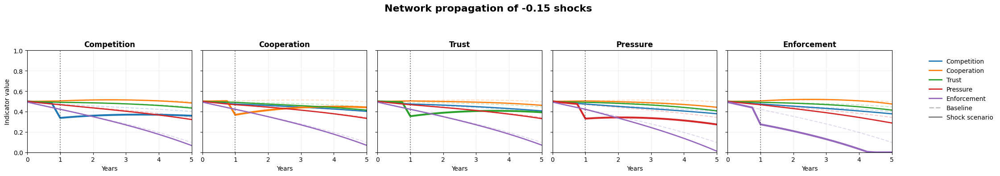

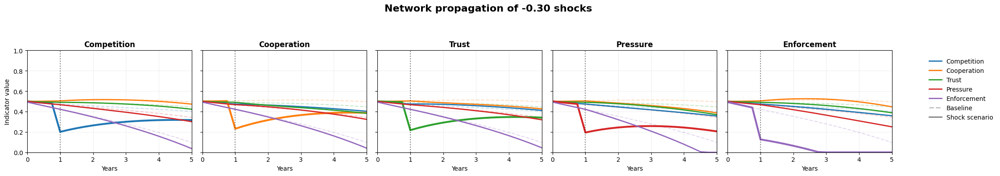

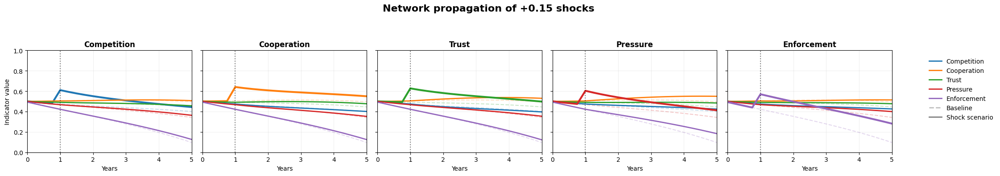

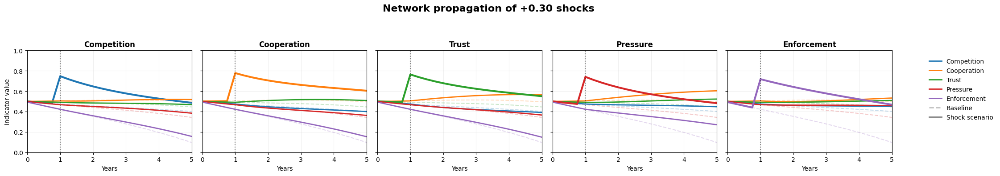

In [28]:


shock_values = [-0.15, -0.30, +0.15, +0.30]

param_colors = {
    "competition": "tab:blue",
    "cooperation": "tab:orange",
    "trust": "tab:green",
    "pressure": "tab:red",
    "enforcement": "tab:purple"
}

max_years = 5


# =========================================
# FILTER BASELINE TO 5 YEARS
# =========================================

baseline_history_5y = [
    h for h in baseline_history
    if h["t"] * 3 / 12 <= max_years
]

t_years = [
    h["t"] * 3 / 12
    for h in baseline_history_5y
]


# =========================================
# FIXED AXIS SCALE
# =========================================

# X-axis: 0-5 years
x_ticks = np.arange(
    0,
    max_years + 1,
    1
)

# Y-axis: normalized indicators 0-1
ymin = 0
ymax = 1

y_ticks = np.arange(
    0,
    1.01,
    0.2
)


# =========================================
# PLOT SHOCK SCENARIOS
# =========================================

for shock_value in shock_values:

    fig, axes = plt.subplots(
        1,
        len(RELATION_PARAMS),
        figsize=(22, 4),
        sharex=True,
        sharey=True
    )

    fig.suptitle(
        f"Network propagation of {shock_value:+.2f} shocks",
        fontsize=16,
        fontweight="bold"
    )


    for ax, shocked_param in zip(axes, RELATION_PARAMS):

        scenario_name = f"{shocked_param}_{shock_value:+.2f}"

        history = [
            h for h in shock_histories[scenario_name]
            if h["t"] * 3 / 12 <= max_years
        ]


        # =========================================
        # BASELINE
        # =========================================

        for param in RELATION_PARAMS:

            baseline_values = [
                h["indicators"][param]
                for h in baseline_history_5y
            ]

            ax.plot(
                t_years,
                baseline_values,
                color=param_colors[param],
                alpha=0.25,
                linestyle="--",
                linewidth=1.5
            )


        # =========================================
        # SHOCKED RUN
        # =========================================

        for param in RELATION_PARAMS:

            shocked_values = [
                h["indicators"][param]
                for h in history
            ]

            ax.plot(
                t_years,
                shocked_values,
                color=param_colors[param],
                linewidth=3 if param == shocked_param else 2,
                label=param
            )


        # =========================================
        # SHOCK TIMING
        # =========================================

        ax.axvline(
            4 * 3 / 12,
            color="black",
            linestyle=":",
            alpha=0.5
        )


        # =========================================
        # UNIFORM AXES
        # =========================================

        ax.set_xlim(
            0,
            max_years
        )

        ax.set_ylim(
            ymin,
            ymax
        )

        ax.set_xticks(
            x_ticks
        )

        ax.set_yticks(
            y_ticks
        )


        ax.set_title(
            shocked_param.capitalize(),
            fontweight="bold"
        )

        ax.set_xlabel(
            "Years"
        )

        ax.grid(
            alpha=0.2
        )


    axes[0].set_ylabel(
        "Indicator value"
    )


    # =========================================
    # SHARED LEGEND
    # =========================================

    legend_elements = [

        Line2D(
            [0],
            [0],
            color=param_colors["competition"],
            lw=2,
            label="Competition"
        ),

        Line2D(
            [0],
            [0],
            color=param_colors["cooperation"],
            lw=2,
            label="Cooperation"
        ),

        Line2D(
            [0],
            [0],
            color=param_colors["trust"],
            lw=2,
            label="Trust"
        ),

        Line2D(
            [0],
            [0],
            color=param_colors["pressure"],
            lw=2,
            label="Pressure"
        ),

        Line2D(
            [0],
            [0],
            color=param_colors["enforcement"],
            lw=2,
            label="Enforcement"
        ),

        Line2D(
            [0],
            [0],
            color="grey",
            lw=2,
            linestyle="--",
            alpha=0.5,
            label="Baseline"
        ),

        Line2D(
            [0],
            [0],
            color="grey",
            lw=2,
            linestyle="-",
            label="Shock scenario"
        ),
    ]


    fig.legend(
        handles=legend_elements,
        loc="center right",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )


    plt.tight_layout(
        rect=[0, 0, 0.92, 0.9]
    )

    plt.show()

In [29]:
#print(baseline_history[0])
#print(baseline_history[0]["relations"].keys())
print(baseline_history[0].keys())

dict_keys(['t', 'skills', 'indicators', 'network', 'dominant_node', 'structural_valid', 'press_factor', 'ppc_effectiveness', 'traits', 'modifiers'])


In [30]:
for key, value in baseline_history[0].items():
    print("\nKEY:", key)
    print(type(value))
    
    if hasattr(value, "columns"):
        print("columns:", value.columns.tolist())
    
    if isinstance(value, dict):
        print("dict keys:", value.keys())


KEY: t
<class 'int'>

KEY: skills
<class 'pandas.core.frame.DataFrame'>
columns: ['Risk Mentality', 'Punishment Mentality', 'Enforcement of rules/laws', 'Pressure', 'Economic Capital', 'Cultural Capital', 'Social Capital', 'Reputation', 'Sense of Urgency', 'Formal responsibility', 'Informal Responsibility']

KEY: indicators
<class 'dict'>
dict keys: dict_keys(['competition', 'cooperation', 'trust', 'pressure', 'enforcement'])

KEY: network
<class 'networkx.classes.graph.Graph'>

KEY: dominant_node
<class 'str'>

KEY: structural_valid
<class 'float'>

KEY: press_factor
<class 'float'>

KEY: ppc_effectiveness
<class 'float'>

KEY: traits
<class 'pandas.core.frame.DataFrame'>
columns: ['cooperation', 'competition', 'trust']

KEY: modifiers
<class 'dict'>
dict keys: dict_keys(['public_enforcement_boost', 'public_pressure_boost', 'private_competition_boost'])


### Running the 3 initial scenarios through all 4 shock types

Each of the 3 `initial_scenarios` (`null_point`, `balance`, `heterogeneous`) is now
run as its own baseline (no shock) plus the same battery of individual shocks used
above (`-0.30, -0.15, +0.15, +0.30` applied to each of the 5 relation parameters at
step 4). `balance` (all parameters at 0.5) reproduces exactly the same numbers as
the un-labelled `baseline_history` / `shock_histories` computed earlier in the
notebook -- it's just re-run here so all 3 scenarios are available side by side.

In [31]:
# =========================================
# RUN BASELINE + ALL 4 SHOCK TYPES FOR EACH INITIAL SCENARIO
# =========================================

def run_scenario(initial_values, steps=STEPS, shock_values=(-0.15, -0.30, +0.15, +0.30), shock_step=4):
    """Runs one baseline (no-shock) history, plus one history per
    (parameter, shock_value) combination -- all starting from
    `initial_values` (one of the `initial_scenarios` dicts) instead of the
    neutral 0.5 default."""

    baseline = run_simulation(
        data, signed_matrices, steps=steps, initial_indicators=initial_values, seed=42
    )

    shocks = {}
    for param in RELATION_PARAMS:
        for value in shock_values:
            scenario_key = f"{param}_{value:+.2f}"
            shocks[scenario_key] = run_simulation(
                data, signed_matrices, steps=steps,
                shocks={shock_step: {param: value}},
                initial_indicators=initial_values, seed=42
            )

    return baseline, shocks


scenario_baselines = {}
scenario_shock_histories = {}

for scenario_name, initial_values in initial_scenarios.items():
    print(f"Running scenario: {scenario_name}  (initial values: {initial_values})")
    baseline_hist, shock_hists = run_scenario(initial_values)
    scenario_baselines[scenario_name] = baseline_hist
    scenario_shock_histories[scenario_name] = shock_hists

print("\nDone. Scenarios available:", list(scenario_baselines.keys()))

Running scenario: nullpoint  (initial values: {'competition': 0.0, 'cooperation': 0.0, 'trust': 0.0, 'pressure': 0.0, 'enforcement': 0.0})
skills_state memory: 1424189314048
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.0, 'cooperation': 0.0, 'trust': 0.0, 'pressure': 0.0, 'enforcement': 0.0}
Average skill: 0.37792207792207794
skills_state memory: 1424161856384
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.0, 'cooperation': 0.0, 'trust': 0.0, 'pressure': 0.0, 'enforcement': 0.0}
Average skill: 0.37792207792207794
skills_state memory: 1424162150096
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.0, 'cooperation': 0.0, 'trust': 0.0, 'pressure': 0.0, 'enforcement': 0.0}
Average skill: 0.37792207792207794
skills_state memory: 1424184326960
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.0, 'cooperation': 0.0, 'trust': 0.0, 'pressure': 0

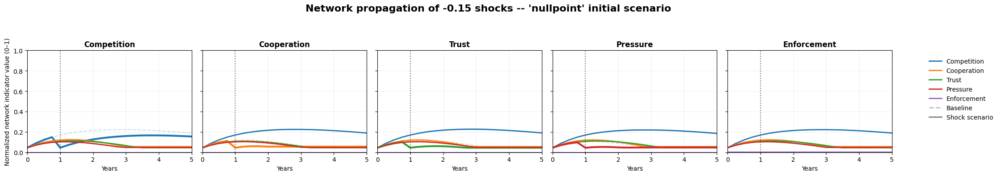

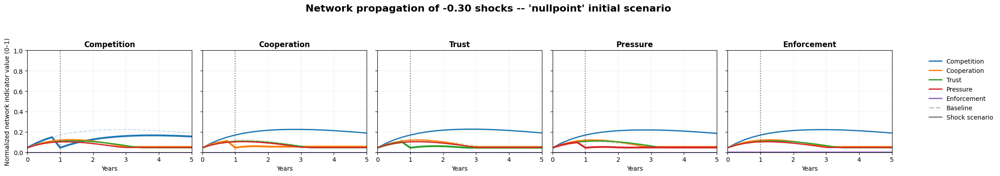

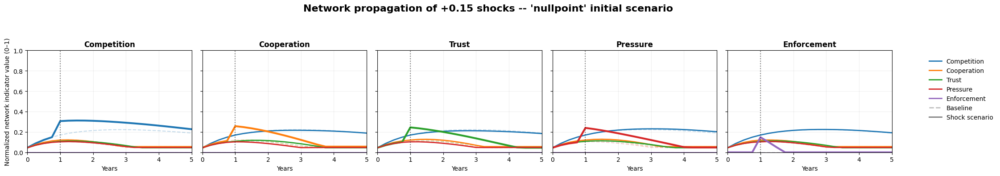

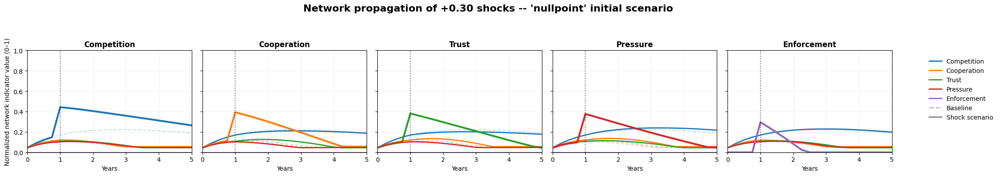

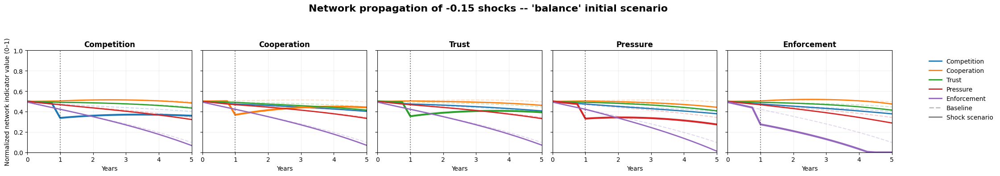

...

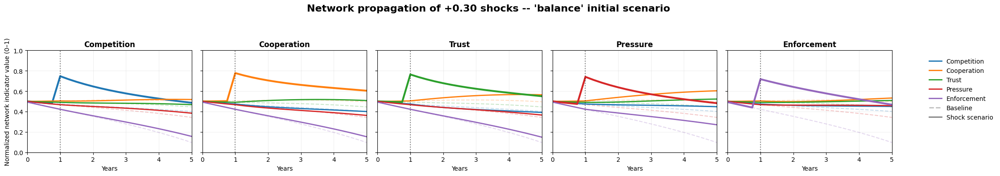

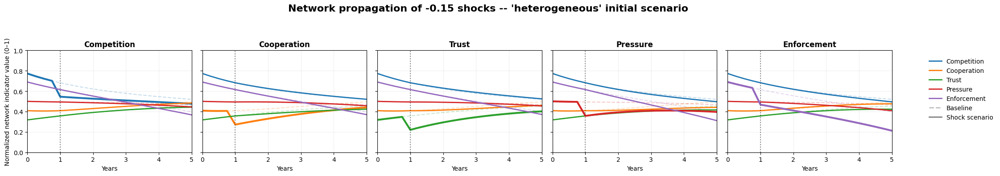

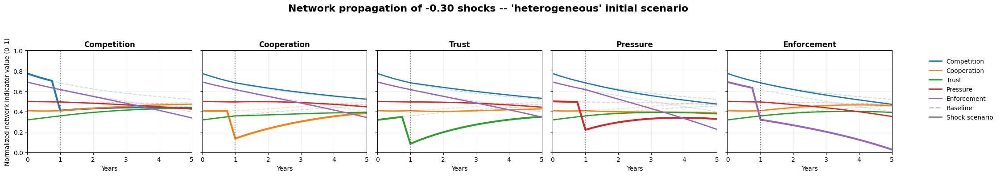

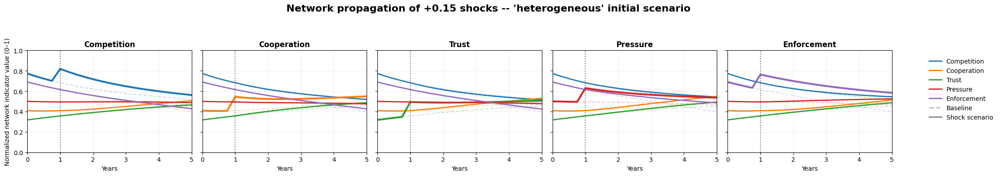

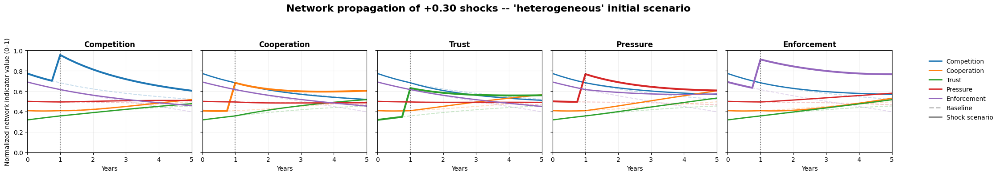

In [32]:
# Labels on Y
# 
# Indicator	What the y-value represents
# Competition	The modeled intensity/state of competitive relations in the network
# Cooperation	The modeled intensity/state of cooperative relations
# Trust	The modeled level of trust within the network
# Pressure	The modeled level of pressure dynamics
# Enforcement	The modeled strength/intensity of enforcement mechanisms

# =========================================
# "NETWORK PROPAGATION OF ... SHOCKS" PLOTS, PER INITIAL SCENARIO
# =========================================


def plot_network_propagation(scenario_name, baseline_history, shock_histories,
                              shock_values=(-0.15, -0.30, +0.15, +0.30), max_years=5):
    """Same figure as the single-scenario 'Network propagation of ... shocks'
    plot above, generalised to take any (baseline_history, shock_histories)
    pair -- so it can be reused for every entry in `initial_scenarios`."""

    param_colors = {
        "competition": "tab:blue",
        "cooperation": "tab:orange",
        "trust": "tab:green",
        "pressure": "tab:red",
        "enforcement": "tab:purple"
    }

    baseline_history_5y = [h for h in baseline_history if h["t"] * 3 / 12 <= max_years]
    t_years = [h["t"] * 3 / 12 for h in baseline_history_5y]

    x_ticks = np.arange(0, max_years + 1, 1)
    y_ticks = np.arange(0, 1.01, 0.2)

    for shock_value in shock_values:

        fig, axes = plt.subplots(1, len(RELATION_PARAMS), figsize=(22, 4), sharex=True, sharey=True)

        fig.suptitle(
            f"Network propagation of {shock_value:+.2f} shocks -- '{scenario_name}' initial scenario",
            fontsize=16,
            fontweight="bold"
        )

        for ax, shocked_param in zip(axes, RELATION_PARAMS):

            scenario_key = f"{shocked_param}_{shock_value:+.2f}"
            history = [h for h in shock_histories[scenario_key] if h["t"] * 3 / 12 <= max_years]

            # baseline (muted dashed)
            for param in RELATION_PARAMS:
                baseline_values = [h["indicators"][param] for h in baseline_history_5y]
                ax.plot(t_years, baseline_values, color=param_colors[param],
                        alpha=0.25, linestyle="--", linewidth=1.5)

            # shocked run
            for param in RELATION_PARAMS:
                shocked_values = [h["indicators"][param] for h in history]
                ax.plot(t_years, shocked_values, color=param_colors[param],
                        linewidth=3 if param == shocked_param else 2, label=param)

            ax.axvline(4 * 3 / 12, color="black", linestyle=":", alpha=0.5)

            ax.set_xlim(0, max_years)
            ax.set_ylim(0, 1)
            ax.set_xticks(x_ticks)
            ax.set_yticks(y_ticks)
            ax.set_title(shocked_param.capitalize(), fontweight="bold")
            ax.set_xlabel("Years")
            ax.grid(alpha=0.2)

        axes[0].set_ylabel("Normalized network indicator value (0–1)")

        legend_elements = [
            Line2D([0], [0], color=param_colors[p], lw=2, label=p.capitalize())
            for p in RELATION_PARAMS
        ] + [
            Line2D([0], [0], color="grey", lw=2, linestyle="--", alpha=0.5, label="Baseline"),
            Line2D([0], [0], color="grey", lw=2, linestyle="-", label="Shock scenario"),
        ]

        fig.legend(handles=legend_elements, loc="center right", bbox_to_anchor=(1.02, 0.5), frameon=False)

        plt.tight_layout(rect=[0, 0, 0.92, 0.9])
        plt.show()


for scenario_name in initial_scenarios:
    plot_network_propagation(
        scenario_name,
        scenario_baselines[scenario_name],
        scenario_shock_histories[scenario_name]
    )

### now we measure against effectiveness

In [33]:
def plot_effectiveness_response_matrix(
    scenario_name,
    baseline_history,
    shock_histories,
    shock_values=(-0.15, -0.30, +0.15, +0.30),
    max_years=5
):

    param_colors = {
        "competition": "tab:blue",
        "cooperation": "tab:orange",
        "trust": "tab:green",
        "pressure": "tab:red",
        "enforcement": "tab:purple"
    }


    # ----------------------------
    # Filter baseline
    # ----------------------------

    baseline_history_5y = [
        h for h in baseline_history
        if h["t"] * 3 / 12 <= max_years
    ]

    t_years = [
        h["t"] * 3 / 12
        for h in baseline_history_5y
    ]


    # ----------------------------
    # Create 2x2 shock layout
    # ----------------------------

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 8),
        sharex=True,
        sharey=True
    )

    axes = axes.flatten()


    fig.suptitle(
        f"PPC effectiveness response to parameter shocks\n"
        f"Initial scenario: {scenario_name}",
        fontsize=16,
        fontweight="bold"
    )


    for ax, shock_value in zip(axes, shock_values):


        # ----------------------------
        # Baseline
        # ----------------------------

        baseline_values = [
            h["ppc_effectiveness"]
            for h in baseline_history_5y
        ]

        ax.plot(
            t_years,
            baseline_values,
            color="black",
            linewidth=2.5,
            linestyle="--",
            label="Baseline"
        )


        # ----------------------------
        # Effectiveness after each shock
        # ----------------------------

        for param in RELATION_PARAMS:

            scenario_key = f"{param}_{shock_value:+.2f}"

            history = [
                h for h in shock_histories[scenario_key]
                if h["t"] * 3 / 12 <= max_years
            ]


            shocked_values = [
                h["ppc_effectiveness"]
                for h in history
            ]


            ax.plot(
                t_years,
                shocked_values,
                color=param_colors[param],
                linewidth=2.5,
                label=f"{param.capitalize()} shock"
            )


        # ----------------------------
        # Shock timing
        # ----------------------------

        ax.axvline(
            4 * 3 / 12,
            color="black",
            linestyle=":",
            alpha=0.5
        )


        ax.set_title(
            f"Shock = {shock_value:+.2f}",
            fontweight="bold"
        )

        ax.set_xlabel("Years")
        ax.set_ylabel("PPC effectiveness")

        ax.set_ylim(0,1)

        ax.grid(alpha=0.2)


    # ----------------------------
    # Shared legend
    # ----------------------------

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="center right",
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    plt.show()

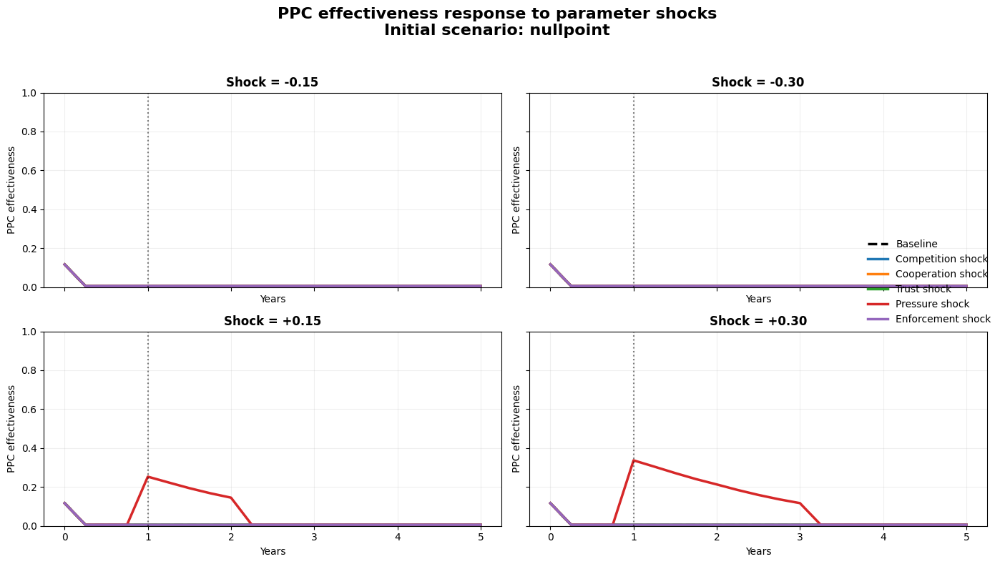

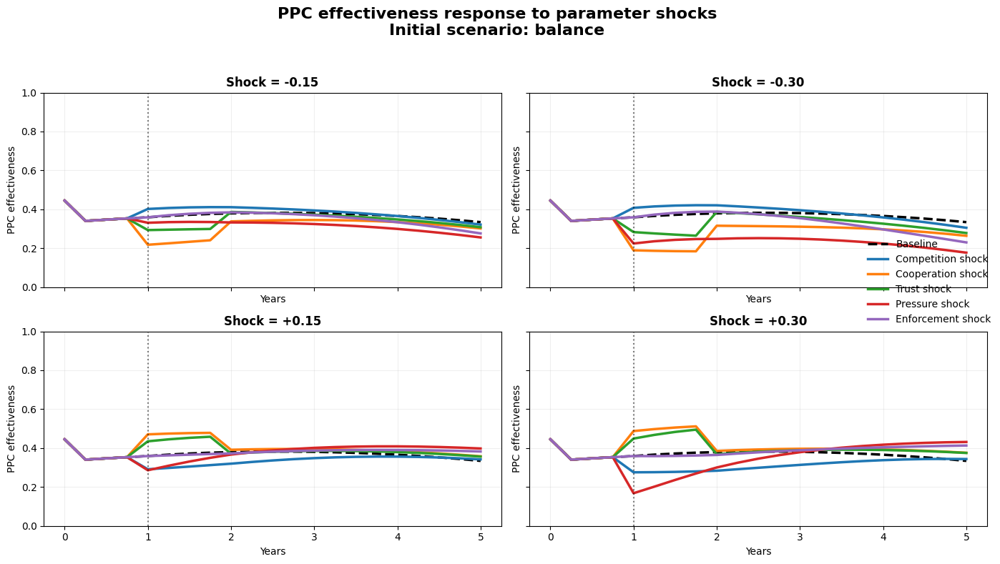

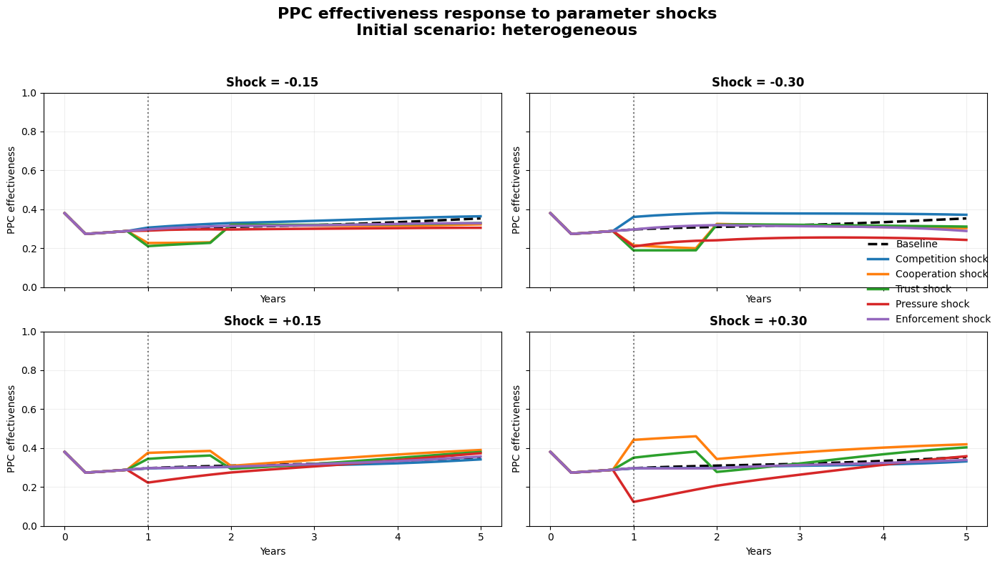

In [34]:
for scenario_name in initial_scenarios:

    plot_effectiveness_response_matrix(
        scenario_name,
        scenario_baselines[scenario_name],
        scenario_shock_histories[scenario_name]
    )

### end of all shocks

### Layer visualization

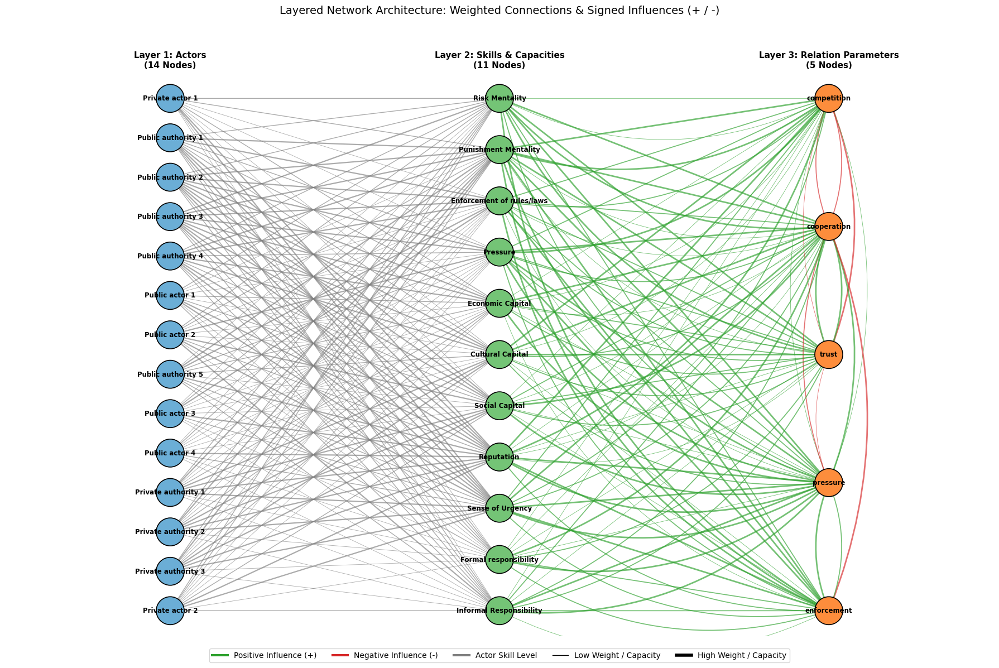

In [35]:


# =============================================================================
# 1. BUILD MULTI-LAYER DIRECTED GRAPH
# =============================================================================
G = nx.DiGraph()

# Define Node Sets
actors = list(data["skills_df"].index)
skills = list(data["skill_cols"])
parameters = RELATION_PARAMS

# Add Nodes with Layer Attributes
for a in actors:
    G.add_node(a, layer=0, node_type="Actor")

for s in skills:
    G.add_node(s, layer=1, node_type="Skill")

for p in parameters:
    G.add_node(p, layer=2, node_type="Parameter")

# --- Edge Type 1: Actor -> Skill ---
skills_df = data["skills_df"]
for a in actors:
    for s in skills:
        val = skills_df.loc[a, s]
        if pd.notna(val) and val != 0:
            G.add_edge(a, s, weight=val, edge_type="actor_skill")

# --- Edge Type 2: Skill -> Parameter ---
for s in skills:
    for p in parameters:
        val = signed_skill_param.loc[s, p]
        if pd.notna(val) and val != 0:
            G.add_edge(s, p, weight=val, edge_type="skill_param")

# --- Edge Type 3: Parameter -> Parameter (CLD Core) ---
for p1 in parameters:
    for p2 in parameters:
        val = signed_rel_rel.loc[p1, p2]
        if pd.notna(val) and val != 0:
            G.add_edge(p1, p2, weight=val, edge_type="param_param")

# --- Edge Type 4: Parameter -> Skill (Feedback Loop) ---
for p in parameters:
    for s in skills:
        val = signed_param_skill.loc[p, s]
        if pd.notna(val) and val != 0:
            G.add_edge(p, s, weight=val, edge_type="param_skill")


# =============================================================================
# 2. CUSTOM LAYERED LAYOUT
# =============================================================================
pos = {}


def assign_y_positions(node_list, x_val):
    n = len(node_list)
    y_vals = np.linspace(1, 0, n) if n > 1 else [0.5]
    for node, y in zip(node_list, y_vals):
        pos[node] = (x_val, y)


assign_y_positions(actors, x_val=0.0)
assign_y_positions(skills, x_val=0.5)
assign_y_positions(parameters, x_val=1.0)


# =============================================================================
# 3. PLOTTING THE NETWORK WITH SIGNED & WEIGHTED EDGES
# =============================================================================
plt.figure(figsize=(18, 12))
ax = plt.gca()

# Node Colors by Layer
color_map = {
    "Actor": "#6BAED6",  # Light Blue
    "Skill": "#74C476",  # Soft Green
    "Parameter": "#FD8D3C",  # Warm Orange
}

node_colors = [color_map[G.nodes[node]["node_type"]] for node in G.nodes()]

# Draw Nodes
nx.draw_networkx_nodes(
    G, pos, node_color=node_colors, node_size=1300, edgecolors="black", linewidths=1.2, ax=ax
)

# Draw Labels
node_labels = {node: node for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8.5, font_weight="bold", ax=ax)


# Helper function to render weighted and signed edge groups
def draw_custom_edges(edge_type, connectionstyle=None, scale_factor=2.5, default_color=None):
    edges_data = [
        (u, v, d["weight"]) for u, v, d in G.edges(data=True) if d.get("edge_type") == edge_type
    ]
    if not edges_data:
        return

    edges = [(u, v) for u, v, w in edges_data]
    weights = [w for u, v, w in edges_data]

    # Calculate widths proportional to absolute weight magnitude
    widths = [max(0.6, abs(w) * scale_factor) for w in weights]

    # Color logic: Red for negative (-), Green/Blue for positive (+), Neutral for skill amounts
    if default_color:
        colors = [default_color] * len(weights)
    else:
        colors = [
            "#2CA02C" if w > 0 else "#D62728" for w in weights
        ]  # Green for +, Red for -

    kwargs = {
        "G": G,
        "pos": pos,
        "edgelist": edges,
        "width": widths,
        "edge_color": colors,
        "alpha": 0.65,
        "arrows": True,
        "arrowsize": 12,
        "ax": ax,
    }

    if connectionstyle:
        kwargs["connectionstyle"] = connectionstyle

    nx.draw_networkx_edges(**kwargs)


# 1. Actor -> Skill (Width = Skill Level, Color = Neutral Gray)
draw_custom_edges("actor_skill", scale_factor=2.0, default_color="#7F7F7F")

# 2. Skill -> Parameter (Width = Weight, Color = Red/Green Sign)
draw_custom_edges("skill_param", scale_factor=2.5)

# 3. Parameter -> Parameter (CLD Core: Curved, Width = Weight, Color = Red/Green Sign)
draw_custom_edges("param_param", connectionstyle="arc3,rad=0.2", scale_factor=2.5)

# 4. Parameter -> Skill (Feedback Loops: Curved, Width = Weight, Color = Red/Green Sign)
draw_custom_edges("param_skill", connectionstyle="arc3,rad=-0.25", scale_factor=2.5)


# =============================================================================
# 4. TITLES & LEGEND
# =============================================================================
plt.text(
    0.0,
    1.06,
    "Layer 1: Actors\n(14 Nodes)",
    fontsize=11,
    fontweight="bold",
    ha="center",
    backgroundcolor="white",
)
plt.text(
    0.5,
    1.06,
    "Layer 2: Skills & Capacities\n(11 Nodes)",
    fontsize=11,
    fontweight="bold",
    ha="center",
    backgroundcolor="white",
)
plt.text(
    1.0,
    1.06,
    "Layer 3: Relation Parameters\n(5 Nodes)",
    fontsize=11,
    fontweight="bold",
    ha="center",
    backgroundcolor="white",
)

plt.title(
    "Layered Network Architecture: Weighted Connections & Signed Influences (+ / -)",
    fontsize=14,
    pad=30,
)

# Custom Visual Legend
legend_elements = [
    Line2D([0], [0], color="#2CA02C", lw=3, label="Positive Influence (+)"),
    Line2D([0], [0], color="#D62728", lw=3, label="Negative Influence (-)"),
    Line2D([0], [0], color="#7F7F7F", lw=3, label="Actor Skill Level"),
    Line2D([0], [0], color="black", lw=1, label="Low Weight / Capacity"),
    Line2D([0], [0], color="black", lw=4, label="High Weight / Capacity"),
]
ax.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=5,
    bbox_to_anchor=(0.5, -0.05),
    frameon=True,
    fontsize=10,
)

plt.xlim(-0.25, 1.25)
plt.ylim(-0.05, 1.12)
plt.axis("off")
plt.tight_layout()
plt.show()
#needs clear arrows

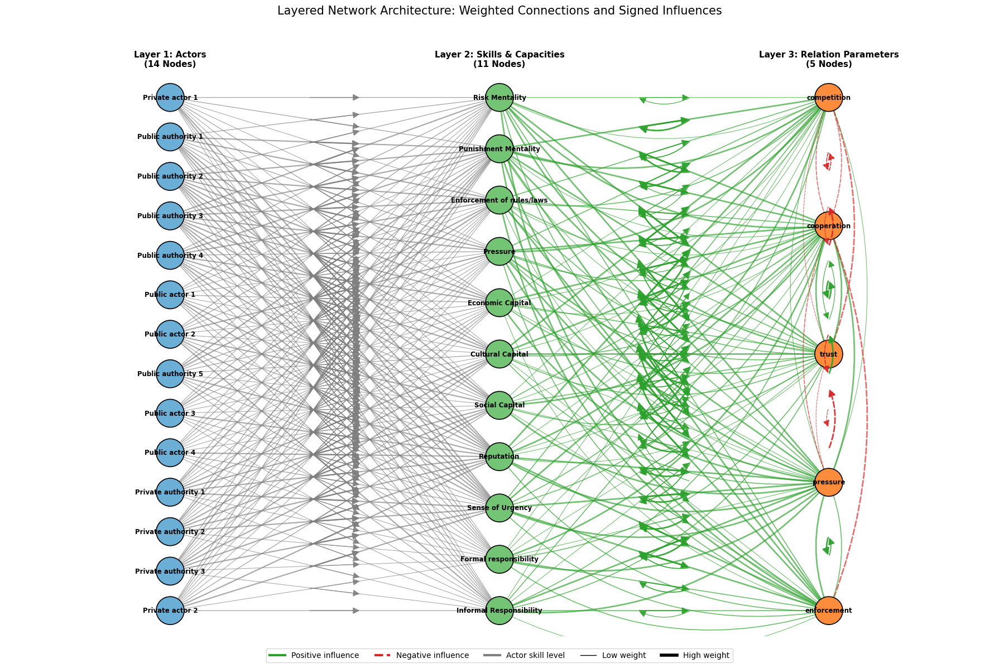

In [36]:


# =============================================================================
# 1. BUILD MULTI-LAYER DIRECTED GRAPH
# =============================================================================
G = nx.DiGraph()

# -------------------------------------------------------------------------
# Nodes
# -------------------------------------------------------------------------
actors = list(data["skills_df"].index)
skills = list(data["skill_cols"])
parameters = RELATION_PARAMS

for a in actors:
    G.add_node(a, layer=0, node_type="Actor")

for s in skills:
    G.add_node(s, layer=1, node_type="Skill")

for p in parameters:
    G.add_node(p, layer=2, node_type="Parameter")


# -------------------------------------------------------------------------
# Actor -> Skill
# -------------------------------------------------------------------------
skills_df = data["skills_df"]

for a in actors:
    for s in skills:
        val = skills_df.loc[a, s]
        if pd.notna(val) and val != 0:
            G.add_edge(
                a,
                s,
                weight=val,
                edge_type="actor_skill"
            )


# -------------------------------------------------------------------------
# Skill -> Parameter
# -------------------------------------------------------------------------
for s in skills:
    for p in parameters:
        val = signed_skill_param.loc[s, p]
        if pd.notna(val) and val != 0:
            G.add_edge(
                s,
                p,
                weight=val,
                edge_type="skill_param"
            )


# -------------------------------------------------------------------------
# Parameter -> Parameter
# -------------------------------------------------------------------------
for p1 in parameters:
    for p2 in parameters:
        val = signed_rel_rel.loc[p1, p2]
        if pd.notna(val) and val != 0:
            G.add_edge(
                p1,
                p2,
                weight=val,
                edge_type="param_param"
            )


# -------------------------------------------------------------------------
# Parameter -> Skill
# -------------------------------------------------------------------------
for p in parameters:
    for s in skills:
        val = signed_param_skill.loc[p, s]
        if pd.notna(val) and val != 0:
            G.add_edge(
                p,
                s,
                weight=val,
                edge_type="param_skill"
            )


# =============================================================================
# 2. LAYERED LAYOUT
# =============================================================================
pos = {}


def assign_y_positions(nodes, x):

    y = np.linspace(1, 0, len(nodes))

    for n, yy in zip(nodes, y):
        pos[n] = (x, yy)


assign_y_positions(actors, 0.00)
assign_y_positions(skills, 0.50)
assign_y_positions(parameters, 1.00)


# =============================================================================
# 3. DRAW FIGURE
# =============================================================================
fig, ax = plt.subplots(figsize=(18, 12))

# -------------------------------------------------------------------------
# Node colours
# -------------------------------------------------------------------------
color_map = {
    "Actor": "#6BAED6",
    "Skill": "#74C476",
    "Parameter": "#FD8D3C",
}

node_colors = [
    color_map[G.nodes[n]["node_type"]]
    for n in G.nodes()
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=1300,
    edgecolors="black",
    linewidths=1.2,
    ax=ax
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8.5,
    font_weight="bold",
    ax=ax
)


# =============================================================================
# EDGE DRAWING WITH MID-EDGE ARROWS
# =============================================================================
def draw_custom_edges(
    edge_type,
    rad=0.0,
    scale_factor=2.5,
    default_color=None
):

    edge_list = [
        (u, v, d["weight"])
        for u, v, d in G.edges(data=True)
        if d["edge_type"] == edge_type
    ]

    for u, v, w in edge_list:

        x1, y1 = pos[u]
        x2, y2 = pos[v]

        width = max(0.8, abs(w) * scale_factor)

        if default_color is None:
            colour = "#2CA02C" if w > 0 else "#D62728"
        else:
            colour = default_color

        linestyle = "-" if (default_color is not None or w > 0) else "--"

        # -----------------------------------------------------------------
        # Full edge
        # -----------------------------------------------------------------
        edge = FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-",
            linewidth=width,
            color=colour,
            linestyle=linestyle,
            alpha=0.65,
            shrinkA=18,
            shrinkB=18,
            connectionstyle=f"arc3,rad={rad}",
            zorder=1
        )

        ax.add_patch(edge)

        # -----------------------------------------------------------------
        # Arrow in middle of edge
        # -----------------------------------------------------------------
        mx1 = x1 + 0.42 * (x2 - x1)
        my1 = y1 + 0.42 * (y2 - y1)

        mx2 = x1 + 0.58 * (x2 - x1)
        my2 = y1 + 0.58 * (y2 - y1)

        arrow = FancyArrowPatch(
            (mx1, my1),
            (mx2, my2),
            arrowstyle="-|>",
            mutation_scale=18,
            linewidth=width,
            color=colour,
            linestyle=linestyle,
            connectionstyle=f"arc3,rad={rad}",
            alpha=0.9,
            zorder=2
        )

        ax.add_patch(arrow)


# =============================================================================
# DRAW EDGE GROUPS
# =============================================================================

draw_custom_edges(
    "actor_skill",
    rad=0,
    scale_factor=2.0,
    default_color="#7F7F7F"
)

draw_custom_edges(
    "skill_param",
    rad=0,
    scale_factor=2.5
)

draw_custom_edges(
    "param_param",
    rad=0.20,
    scale_factor=2.5
)

draw_custom_edges(
    "param_skill",
    rad=-0.25,
    scale_factor=2.5
)


# =============================================================================
# LAYER LABELS
# =============================================================================
plt.text(
    0.00,
    1.06,
    "Layer 1: Actors\n(14 Nodes)",
    ha="center",
    fontsize=11,
    fontweight="bold",
    backgroundcolor="white"
)

plt.text(
    0.50,
    1.06,
    "Layer 2: Skills & Capacities\n(11 Nodes)",
    ha="center",
    fontsize=11,
    fontweight="bold",
    backgroundcolor="white"
)

plt.text(
    1.00,
    1.06,
    "Layer 3: Relation Parameters\n(5 Nodes)",
    ha="center",
    fontsize=11,
    fontweight="bold",
    backgroundcolor="white"
)


# =============================================================================
# TITLE
# =============================================================================
plt.title(
    "Layered Network Architecture: Weighted Connections and Signed Influences",
    fontsize=15,
    pad=28
)


# =============================================================================
# LEGEND
# =============================================================================
legend_elements = [

    Line2D(
        [0],
        [0],
        color="#2CA02C",
        lw=3,
        label="Positive influence"
    ),

    Line2D(
        [0],
        [0],
        color="#D62728",
        lw=3,
        linestyle="--",
        label="Negative influence"
    ),

    Line2D(
        [0],
        [0],
        color="#7F7F7F",
        lw=3,
        label="Actor skill level"
    ),

    Line2D(
        [0],
        [0],
        color="black",
        lw=1,
        label="Low weight"
    ),

    Line2D(
        [0],
        [0],
        color="black",
        lw=4,
        label="High weight"
    ),
]

ax.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=5,
    frameon=True,
    fontsize=10
)


plt.xlim(-0.25, 1.25)
plt.ylim(-0.05, 1.12)

plt.axis("off")

plt.tight_layout()

plt.show()

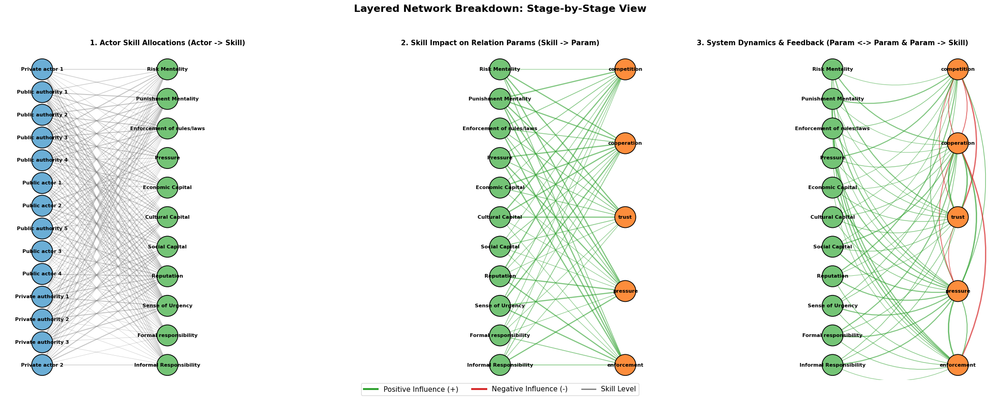

In [37]:


# =============================================================================
# 1. PARAMETERS & CONFIGURATION
# =============================================================================
MIN_WEIGHT = 0.1  # Filter out trivial ties below this absolute weight

actors = list(data["skills_df"].index)
skills = list(data["skill_cols"])
parameters = RELATION_PARAMS


def get_pos():
    pos = {}
    for i, node in enumerate(actors):
        pos[node] = (0.0, np.linspace(1, 0, len(actors))[i])
    for i, node in enumerate(skills):
        pos[node] = (0.5, np.linspace(1, 0, len(skills))[i])
    for i, node in enumerate(parameters):
        pos[node] = (1.0, np.linspace(1, 0, len(parameters))[i])
    return pos


pos = get_pos()

# Node Colors
node_colors = {
    **{a: "#6BAED6" for a in actors},
    **{s: "#74C476" for s in skills},
    **{p: "#FD8D3C" for p in parameters},
}

# =============================================================================
# 2. SUBPLOT VISUALIZATION
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.suptitle(
    "Layered Network Breakdown: Stage-by-Stage View",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

panel_titles = [
    "1. Actor Skill Allocations (Actor -> Skill)",
    "2. Skill Impact on Relation Params (Skill -> Param)",
    "3. System Dynamics & Feedback (Param <-> Param & Param -> Skill)",
]

for ax, title in zip(axes, panel_titles):
    ax.set_title(title, fontsize=11, fontweight="bold", pad=15)
    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.05, 1.05)
    ax.axis("off")

# Helper to draw node subsets in a panel
def draw_nodes_in_panel(ax, nodes_to_draw):
    sub_colors = [node_colors[n] for n in nodes_to_draw]
    nx.draw_networkx_nodes(
        nx.Graph(),
        pos,
        nodelist=nodes_to_draw,
        node_color=sub_colors,
        node_size=1100,
        edgecolors="black",
        linewidths=1.2,
        ax=ax,
    )
    labels = {n: n for n in nodes_to_draw}
    nx.draw_networkx_labels(
        nx.Graph(), pos, labels=labels, font_size=8, font_weight="bold", ax=ax
    )


# --- Panel 1: Actor -> Skill ---
G1 = nx.DiGraph()
skills_df = data["skills_df"]
for a in actors:
    for s in skills:
        val = skills_df.loc[a, s]
        if pd.notna(val) and abs(val) >= MIN_WEIGHT:
            G1.add_edge(a, s, weight=val)

draw_nodes_in_panel(axes[0], actors + skills)
for u, v, d in G1.edges(data=True):
    w = d["weight"]
    nx.draw_networkx_edges(
        G1,
        pos,
        edgelist=[(u, v)],
        width=max(0.5, abs(w) * 1.8),
        edge_color="#7F7F7F",
        alpha=0.45,
        arrows=True,
        arrowsize=10,
        ax=axes[0],
    )

# --- Panel 2: Skill -> Parameter ---
G2 = nx.DiGraph()
for s in skills:
    for p in parameters:
        val = signed_skill_param.loc[s, p]
        if pd.notna(val) and abs(val) >= MIN_WEIGHT:
            G2.add_edge(s, p, weight=val)

draw_nodes_in_panel(axes[1], skills + parameters)
for u, v, d in G2.edges(data=True):
    w = d["weight"]
    color = "#2CA02C" if w > 0 else "#D62728"
    nx.draw_networkx_edges(
        G2,
        pos,
        edgelist=[(u, v)],
        width=max(0.8, abs(w) * 2.2),
        edge_color=color,
        alpha=0.6,
        arrows=True,
        arrowsize=11,
        ax=axes[1],
    )

# --- Panel 3: Dynamics & Feedback ---
G3 = nx.DiGraph()
for p1 in parameters:
    for p2 in parameters:
        val = signed_rel_rel.loc[p1, p2]
        if pd.notna(val) and abs(val) >= MIN_WEIGHT:
            G3.add_edge(p1, p2, weight=val, edge_type="param_param")

for p in parameters:
    for s in skills:
        val = signed_param_skill.loc[p, s]
        if pd.notna(val) and abs(val) >= MIN_WEIGHT:
            G3.add_edge(p, s, weight=val, edge_type="param_skill")

draw_nodes_in_panel(axes[2], skills + parameters)

# Parameter -> Parameter
pp_edges = [
    (u, v, d)
    for u, v, d in G3.edges(data=True)
    if d.get("edge_type") == "param_param"
]
for u, v, d in pp_edges:
    w = d["weight"]
    color = "#2CA02C" if w > 0 else "#D62728"
    nx.draw_networkx_edges(
        G3,
        pos,
        edgelist=[(u, v)],
        width=max(1.0, abs(w) * 2.5),
        edge_color=color,
        connectionstyle="arc3,rad=0.25",
        alpha=0.7,
        arrows=True,
        arrowsize=12,
        ax=axes[2],
    )

# Parameter -> Skill (Feedback)
ps_edges = [
    (u, v, d)
    for u, v, d in G3.edges(data=True)
    if d.get("edge_type") == "param_skill"
]
for u, v, d in ps_edges:
    w = d["weight"]
    color = "#2CA02C" if w > 0 else "#D62728"
    nx.draw_networkx_edges(
        G3,
        pos,
        edgelist=[(u, v)],
        width=max(0.8, abs(w) * 2.0),
        edge_color=color,
        connectionstyle="arc3,rad=-0.25",
        alpha=0.6,
        arrows=True,
        arrowsize=11,
        ax=axes[2],
    )

# Shared Legend
legend_elements = [
    Line2D([0], [0], color="#2CA02C", lw=3, label="Positive Influence (+)"),
    Line2D([0], [0], color="#D62728", lw=3, label="Negative Influence (-)"),
    Line2D([0], [0], color="#7F7F7F", lw=2, label="Skill Level"),
]
fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=3,
    frameon=True,
    fontsize=11,
    bbox_to_anchor=(0.5, 0.02),
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

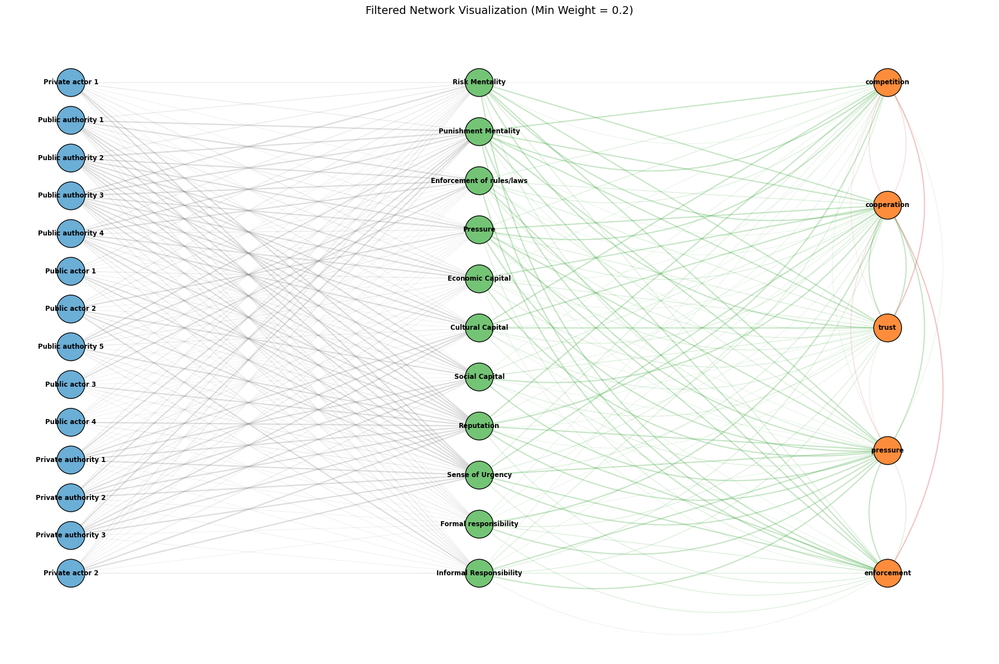

In [38]:


# Threshold to eliminate line clutter (adjust higher if still too dense)
MIN_WEIGHT_THRESHOLD = 0.2

G = nx.DiGraph()

actors = list(data["skills_df"].index)
skills = list(data["skill_cols"])
parameters = RELATION_PARAMS

for a in actors:
    G.add_node(a, node_type="Actor")
for s in skills:
    G.add_node(s, node_type="Skill")
for p in parameters:
    G.add_node(p, node_type="Parameter")

# Filtered Edges
skills_df = data["skills_df"]
for a in actors:
    for s in skills:
        val = skills_df.loc[a, s]
        if pd.notna(val) and abs(val) >= MIN_WEIGHT_THRESHOLD:
            G.add_edge(a, s, weight=val, edge_type="actor_skill")

for s in skills:
    for p in parameters:
        val = signed_skill_param.loc[s, p]
        if pd.notna(val) and abs(val) >= MIN_WEIGHT_THRESHOLD:
            G.add_edge(s, p, weight=val, edge_type="skill_param")

for p1 in parameters:
    for p2 in parameters:
        val = signed_rel_rel.loc[p1, p2]
        if pd.notna(val) and abs(val) >= MIN_WEIGHT_THRESHOLD:
            G.add_edge(p1, p2, weight=val, edge_type="param_param")

for p in parameters:
    for s in skills:
        val = signed_param_skill.loc[p, s]
        if pd.notna(val) and abs(val) >= MIN_WEIGHT_THRESHOLD:
            G.add_edge(p, s, weight=val, edge_type="param_skill")

# Position Assignment
pos = {}
for i, a in enumerate(actors):
    pos[a] = (0.0, np.linspace(1, 0, len(actors))[i])
for i, s in enumerate(skills):
    pos[s] = (0.5, np.linspace(1, 0, len(skills))[i])
for i, p in enumerate(parameters):
    pos[p] = (1.0, np.linspace(1, 0, len(parameters))[i])

plt.figure(figsize=(18, 12))
ax = plt.gca()

color_map = {"Actor": "#6BAED6", "Skill": "#74C476", "Parameter": "#FD8D3C"}
node_colors = [color_map[G.nodes[node]["node_type"]] for node in G.nodes()]

nx.draw_networkx_nodes(
    G, pos, node_color=node_colors, node_size=1300, edgecolors="black", ax=ax
)
nx.draw_networkx_labels(
    G, pos, font_size=8.5, font_weight="bold", ax=ax
)

# Render Edges with Opacity Fading
for u, v, d in G.edges(data=True):
    w = d["weight"]
    e_type = d["edge_type"]

    # Opacity scales with weight magnitude (0.15 to 0.85)
    alpha_val = max(0.15, min(0.85, abs(w) / 3.0))
    width_val = max(0.6, abs(w) * 2.0)

    if e_type == "actor_skill":
        color = "#7F7F7F"
        conn = "arc3,rad=0.0"
    else:
        color = "#2CA02C" if w > 0 else "#D62728"
        if e_type == "skill_param":
            conn = "arc3,rad=0.0"
        elif e_type == "param_param":
            conn = "arc3,rad=0.3"
        else:
            conn = "arc3,rad=-0.3"

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        width=width_val,
        edge_color=color,
        alpha=alpha_val,
        connectionstyle=conn,
        arrows=True,
        arrowsize=11,
        ax=ax,
    )

plt.title(
    f"Filtered Network Visualization (Min Weight = {MIN_WEIGHT_THRESHOLD})",
    fontsize=14,
    pad=20,
)
plt.axis("off")
plt.tight_layout()
plt.show()

### End of layer visualization

skills_state memory: 1424270494128
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.5, 'cooperation': 0.5, 'trust': 0.5, 'pressure': 0.5, 'enforcement': 0.5}
Average skill: 0.37792207792207794
skills_state memory: 1424267763664
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.5, 'cooperation': 0.5, 'trust': 0.5, 'pressure': 0.5, 'enforcement': 0.5}
Average skill: 0.37792207792207794
skills_state memory: 1424304758928
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.5, 'cooperation': 0.5, 'trust': 0.5, 'pressure': 0.5, 'enforcement': 0.5}
Average skill: 0.37792207792207794
skills_state memory: 1424290372432
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.5, 'cooperation': 0.5, 'trust': 0.5, 'pressure': 0.5, 'enforcement': 0.5}
Average skill: 0.37792207792207794
skills_state memory: 1424265225920
original data memory: 1424096066064
Starting 

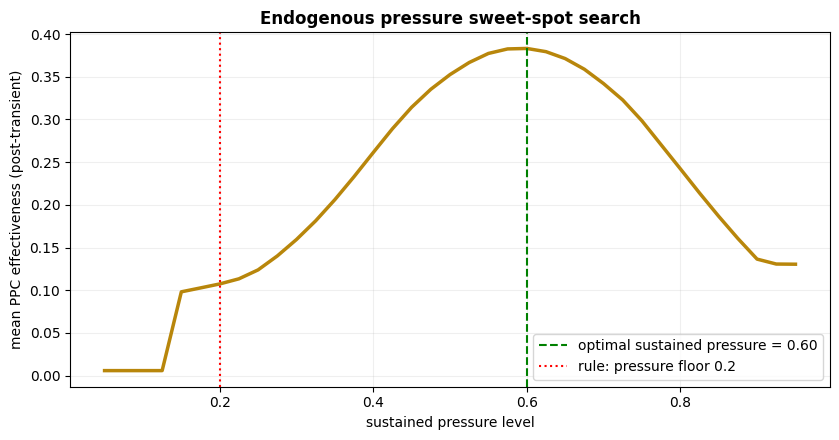

Optimal sustained pressure level: 0.600


,pressure,mean_effectiveness,final_trust,final_cooperation,final_competition
0,0.05,0.005839,0.045000,0.055920,0.153732
4,0.15,0.098128,0.045000,0.055920,0.194018
8,0.25,0.123848,0.050787,0.055920,0.234035
12,0.35,0.206100,0.167578,0.197909,0.272266
16,0.45,0.314325,0.306299,0.384265,0.319782
20,0.55,0.377354,0.481370,0.606330,0.390041
24,0.65,0.371359,0.680882,0.812569,0.483320
28,0.75,0.298466,0.856725,0.947710,0.560896
32,0.85,0.186600,0.955000,0.944080,0.614648
36,0.95,0.130477,0.955000,0.944080,0.644795


In [39]:
#original way

# def optimize_pressure(data, signed_matrices, pressure_levels=None, steps=40, rates=None, tail=8):
#     pressure_levels = pressure_levels if pressure_levels is not None else np.linspace(0.05, 0.95, 37)
#     rows = []
#     for p in pressure_levels:
#         hist = run_simulation(data, signed_matrices, steps=steps, rates=rates, pinned_pressure=float(p))
#         tail_hist = hist[-tail:]
#         rows.append({
#             "pressure": float(p),
#             "mean_effectiveness": float(np.mean([h["ppc_effectiveness"] for h in tail_hist])),
#             "final_trust": hist[-1]["indicators"]["trust"],
#             "final_cooperation": hist[-1]["indicators"]["cooperation"],
#             "final_competition": hist[-1]["indicators"]["competition"],
#         })
#     results = pd.DataFrame(rows)
#     best_row = results.loc[results["mean_effectiveness"].idxmax()]
#     return results, float(best_row["pressure"])

#new way
def optimize_pressure(data, signed_matrices, pressure_levels=None, steps=40, rates=None, tail=8, initial_indicators=None):
    """[assumption] EXTENDED with initial_indicators so the sweep can start from any
    of the `initial_scenarios` instead of always starting neutral -- everything else
    (the real run_simulation engine, the real ppc_effectiveness score) is unchanged."""
    pressure_levels = pressure_levels if pressure_levels is not None else np.linspace(0.05, 0.95, 37)
    rows = []
    for p in pressure_levels:
        hist = run_simulation(data, signed_matrices, steps=steps, rates=rates, pinned_pressure=float(p), initial_indicators=initial_indicators)
        tail_hist = hist[-tail:]
        rows.append({
            "pressure": float(p),
            "mean_effectiveness": float(np.mean([h["ppc_effectiveness"] for h in tail_hist])),
            "final_trust": hist[-1]["indicators"]["trust"],
            "final_cooperation": hist[-1]["indicators"]["cooperation"],
            "final_competition": hist[-1]["indicators"]["competition"],
        })
    results = pd.DataFrame(rows)
    best_row = results.loc[results["mean_effectiveness"].idxmax()]
    return results, float(best_row["pressure"])

pressure_results, optimal_pressure = optimize_pressure(data, signed_matrices, steps=STEPS)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(pressure_results["pressure"], pressure_results["mean_effectiveness"], color="#B8860B", linewidth=2.5)
ax.axvline(optimal_pressure, color="green", linestyle="--", label=f"optimal sustained pressure = {optimal_pressure:.2f}")
ax.axvline(DEFAULT_RATES["pressure_floor"], color="red", linestyle=":", label="rule: pressure floor 0.2")
ax.set_xlabel("sustained pressure level"); ax.set_ylabel("mean PPC effectiveness (post-transient)")
ax.set_title("Endogenous pressure sweet-spot search", fontweight="bold")
ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

print(f"Optimal sustained pressure level: {optimal_pressure:.3f}")
pressure_results.iloc[::4]


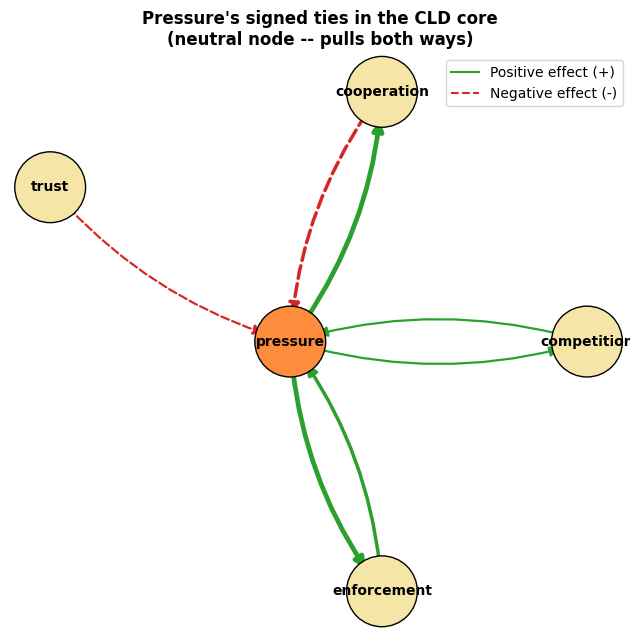

In [40]:
#if doesn't work, comment out

fig, ax = plt.subplots(figsize=(6.5, 6.5))

G_pressure = nx.DiGraph()
G_pressure.add_nodes_from(RELATION_PARAMS)

for other in RELATION_PARAMS:
    if other == "pressure":
        continue
    w_out = signed_rel_rel.loc["pressure", other]   # pressure -> other
    w_in = signed_rel_rel.loc[other, "pressure"]     # other -> pressure
    if pd.notna(w_out) and w_out != 0:
        G_pressure.add_edge("pressure", other, weight=w_out)
    if pd.notna(w_in) and w_in != 0:
        G_pressure.add_edge(other, "pressure", weight=w_in)

pos = nx.circular_layout(G_pressure)
pos["pressure"] = np.array([0.0, 0.0])

node_colors = ["#FD8D3C" if n == "pressure" else "#F5E6A8" for n in G_pressure.nodes()]
nx.draw_networkx_nodes(G_pressure, pos, node_size=2600, node_color=node_colors,
                        edgecolors="black", ax=ax)
nx.draw_networkx_labels(G_pressure, pos, font_size=10, font_weight="bold", ax=ax)

for u, v, d in G_pressure.edges(data=True):
    w = d["weight"]
    color = "#2CA02C" if w > 0 else "#D62728"
    style = "-" if w > 0 else "--"
    nx.draw_networkx_edges(G_pressure, pos, edgelist=[(u, v)], ax=ax,
                            width=1 + 3 * abs(w), edge_color=color, style=style,
                            connectionstyle="arc3,rad=0.15", arrowsize=15,
                            min_source_margin=20, min_target_margin=20)

ax.plot([], [], color="#2CA02C", label="Positive effect (+)")
ax.plot([], [], color="#D62728", linestyle="--", label="Negative effect (-)")
ax.legend(loc="upper right")
ax.set_title("Pressure's signed ties in the CLD core\n(neutral node -- pulls both ways)", fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

skills_state memory: 1424268977280
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.0, 'cooperation': 0.0, 'trust': 0.0, 'pressure': 0.0, 'enforcement': 0.0}
Average skill: 0.37792207792207794
skills_state memory: 1424258473792
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.0, 'cooperation': 0.0, 'trust': 0.0, 'pressure': 0.0, 'enforcement': 0.0}
Average skill: 0.37792207792207794
skills_state memory: 1424271066992
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.0, 'cooperation': 0.0, 'trust': 0.0, 'pressure': 0.0, 'enforcement': 0.0}
Average skill: 0.37792207792207794
skills_state memory: 1424269751984
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.0, 'cooperation': 0.0, 'trust': 0.0, 'pressure': 0.0, 'enforcement': 0.0}
Average skill: 0.37792207792207794
skills_state memory: 1424291997232
original data memory: 1424096066064
Starting 

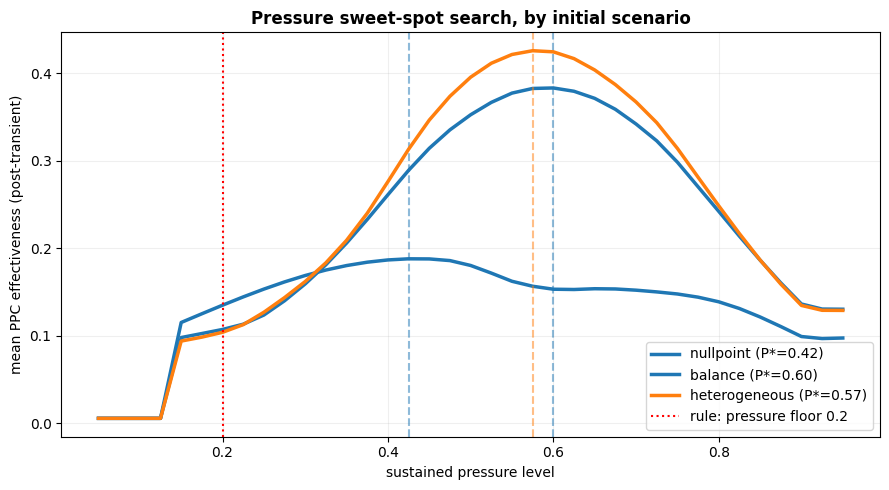

In [41]:
# if doesn't work, comment out

scenario_pressure_results = {}
scenario_optimal_pressure = {}

for scenario_name, initial_values in initial_scenarios.items():
    results, optimal_p = optimize_pressure(
        data, signed_matrices, steps=STEPS, initial_indicators=initial_values
    )
    scenario_pressure_results[scenario_name] = results
    scenario_optimal_pressure[scenario_name] = optimal_p

# ---- summary table ----
summary_rows = []
for scenario_name, results in scenario_pressure_results.items():
    best = results.loc[results["mean_effectiveness"].idxmax()]
    summary_rows.append({
        "scenario": scenario_name,
        "optimal_pressure": round(scenario_optimal_pressure[scenario_name], 3),
        "mean_effectiveness_at_optimum": round(best["mean_effectiveness"], 4),
        "final_trust": round(best["final_trust"], 3),
        "final_cooperation": round(best["final_cooperation"], 3),
        "final_competition": round(best["final_competition"], 3),
    })
sweet_spot_summary = pd.DataFrame(summary_rows)
print("Pressure sweet spot by initial scenario:")
print(sweet_spot_summary.to_string(index=False))

# ---- comparison plot: one sweep curve per scenario ----
fig, ax = plt.subplots(figsize=(9, 5))
scenario_line_colors = {"null_point": "tab:grey", "balance": "tab:blue", "heterogeneous": "tab:orange"}

for scenario_name, results in scenario_pressure_results.items():
    color = scenario_line_colors.get(scenario_name, None)
    ax.plot(results["pressure"], results["mean_effectiveness"],
            label=f"{scenario_name} (P*={scenario_optimal_pressure[scenario_name]:.2f})",
            linewidth=2.5, color=color)
    ax.axvline(scenario_optimal_pressure[scenario_name], color=color, linestyle="--", alpha=0.5)

ax.axvline(DEFAULT_RATES["pressure_floor"], color="red", linestyle=":", label="rule: pressure floor 0.2")
ax.set_xlabel("sustained pressure level")
ax.set_ylabel("mean PPC effectiveness (post-transient)")
ax.set_title("Pressure sweet-spot search, by initial scenario", fontweight="bold")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

skills_state memory: 1424265223376
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.5, 'cooperation': 0.5, 'trust': 0.5, 'pressure': 0.5, 'enforcement': 0.5}
Average skill: 0.37792207792207794


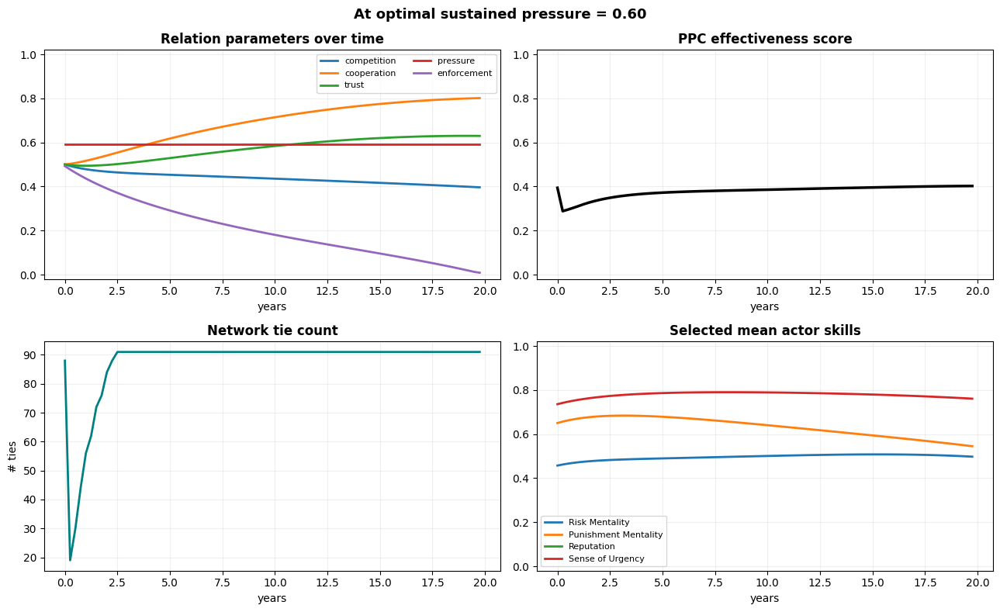

Equilibrium reached: False at step 79 (~19.8 years)
Effectiveness at equilibrium: 0.402


,scenario,equilibrium_reached,step,years,final_effectiveness
0,Baseline (free pressure),False,39,9.8,0.006
1,Trust-collapse scenario,False,39,9.8,0.006
2,Optimal sustained pressure (0.60),False,79,19.8,0.402


In [42]:
#original treatment

optimal_history = run_simulation(data, signed_matrices, steps=80, pinned_pressure=optimal_pressure)
eq_t, reached = find_equilibrium(optimal_history)
plot_run(optimal_history, f"At optimal sustained pressure = {optimal_pressure:.2f}")
print(f"Equilibrium reached: {reached} at step {eq_t} (~{eq_t*3/12:.1f} years)")
print(f"Effectiveness at equilibrium: {optimal_history[eq_t]['ppc_effectiveness']:.3f}")

comparison = pd.DataFrame([
    {"scenario": "Baseline (free pressure)", "equilibrium_reached": find_equilibrium(baseline_history)[1],
     "step": find_equilibrium(baseline_history)[0], "years": round(find_equilibrium(baseline_history)[0]*3/12, 1),
     "final_effectiveness": round(baseline_history[-1]["ppc_effectiveness"], 3)},
    {"scenario": "Trust-collapse scenario", "equilibrium_reached": find_equilibrium(shock_history)[1],
     "step": find_equilibrium(shock_history)[0], "years": round(find_equilibrium(shock_history)[0]*3/12, 1),
     "final_effectiveness": round(shock_history[-1]["ppc_effectiveness"], 3)},
    {"scenario": f"Optimal sustained pressure ({optimal_pressure:.2f})", "equilibrium_reached": reached,
     "step": eq_t, "years": round(eq_t*3/12, 1),
     "final_effectiveness": round(optimal_history[eq_t]["ppc_effectiveness"], 3)},
])
comparison


### now we do a combination of shocks testing effectiveness


In [43]:


print(inspect.signature(apply_shock))

(skills_state, indicators, shock, actor_names)


In [44]:

import itertools

# ============================================================
# FULL PARAMETER SHOCK EXPERIMENTS
# Produces df_para_shock_effectiveness
#
# Does NOT modify existing model code
# Does NOT use apply_shock()
# ============================================================




# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

STEPS = 40

SHOCK_LEVELS = np.round(
    np.arange(0.1, 1.01, 0.1),
    2
)



# ------------------------------------------------------------
# Parameter combinations
# ------------------------------------------------------------

def generate_parameter_combinations(parameters):

    combinations = []

    for r in range(1, len(parameters)+1):

        combinations.extend(
            itertools.combinations(
                parameters,
                r
            )
        )

    return combinations



# ------------------------------------------------------------
# Feasible shocks
# ------------------------------------------------------------

def feasible_shock_levels(
        initial_indicators,
        parameters
):

    feasible = None


    for p in parameters:

        current = initial_indicators[p]

        allowed = set()


        for shock in SHOCK_LEVELS:

            if current + shock <= 1:
                allowed.add(
                    float(shock)
                )


            if current - shock >= 0:
                allowed.add(
                    float(-shock)
                )


        if feasible is None:
            feasible = allowed

        else:
            feasible = feasible.intersection(
                allowed
            )


    return sorted(feasible)



# ------------------------------------------------------------
# Shock design generator
# ------------------------------------------------------------

def create_parameter_shock_design(
        initial_indicators
):

    experiments = []


    for params in generate_parameter_combinations(
        RELATION_PARAMS
    ):

        levels = feasible_shock_levels(
            initial_indicators,
            params
        )


        for level in levels:

            experiments.append(
                {
                    "parameters": params,
                    "shock": level
                }
            )


    return experiments



# ------------------------------------------------------------
# Apply shock directly to indicators
# (avoids apply_shock conflict)
# ------------------------------------------------------------

def manually_apply_indicator_shock(
        initial_indicators,
        parameters,
        shock
):

    shocked = copy.deepcopy(
        initial_indicators
    )


    for p in parameters:

        shocked[p] = np.clip(
            shocked[p] + shock,
            0,
            1
        )


    return shocked



# ============================================================
# RUN EXPERIMENTS
# ============================================================

records = []

baseline_results = {}



for scenario_name, initial_indicators in initial_scenarios.items():


    print(
        "\nRunning scenario:",
        scenario_name
    )


    # --------------------------
    # Baseline
    # --------------------------

    baseline_history = run_simulation(
        data,
        signed_matrices,
        steps=STEPS,
        seed=42,
        initial_indicators=initial_indicators
    )


    baseline_effectiveness = (
        baseline_history[-1]
        ["ppc_effectiveness"]
    )


    baseline_results[
        scenario_name
    ] = baseline_history



    # --------------------------
    # Shock experiments
    # --------------------------

    experiments = create_parameter_shock_design(
        initial_indicators
    )


    print(
        "Experiments:",
        len(experiments)
    )



    for exp in experiments:


        shocked_indicators = manually_apply_indicator_shock(
            initial_indicators,
            exp["parameters"],
            exp["shock"]
        )


        history = run_simulation(
            data,
            signed_matrices,
            steps=STEPS,
            seed=42,
            initial_indicators=shocked_indicators
        )


        final_effectiveness = (
            history[-1]
            ["ppc_effectiveness"]
        )


        records.append(
            {

                "initial_scenario":
                    scenario_name,


                "parameter_combination":
                    "+".join(
                        exp["parameters"]
                    ),


                "number_of_parameters":
                    len(
                        exp["parameters"]
                    ),


                "shock":
                    exp["shock"],


                "shock_direction":
                    (
                        "positive"
                        if exp["shock"] > 0
                        else "negative"
                    ),


                "baseline_effectiveness":
                    baseline_effectiveness,


                "shock_effectiveness":
                    final_effectiveness,


                "effectiveness_change":
                    (
                        final_effectiveness
                        -
                        baseline_effectiveness
                    )

            }
        )



# ============================================================
# Final dataframe
# ============================================================

df_para_shock_effectiveness = pd.DataFrame(
    records
)


df_para_shock_effectiveness = (
    df_para_shock_effectiveness
    .sort_values(
        [
            "initial_scenario",
            "number_of_parameters",
            "parameter_combination",
            "shock"
        ]
    )
    .reset_index(drop=True)
)



print(
    "\nCompleted."
)


print(
    "Total scenarios:",
    len(df_para_shock_effectiveness)
)


df_para_shock_effectiveness.head()


Running scenario: nullpoint
skills_state memory: 1424263292800
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.0, 'cooperation': 0.0, 'trust': 0.0, 'pressure': 0.0, 'enforcement': 0.0}
Average skill: 0.37792207792207794
Experiments: 310
skills_state memory: 1424093713552
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.1, 'cooperation': 0.0, 'trust': 0.0, 'pressure': 0.0, 'enforcement': 0.0}
Average skill: 0.37792207792207794
skills_state memory: 1424095468176
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.2, 'cooperation': 0.0, 'trust': 0.0, 'pressure': 0.0, 'enforcement': 0.0}
Average skill: 0.37792207792207794
skills_state memory: 1424259773408
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.3, 'cooperation': 0.0, 'trust': 0.0, 'pressure': 0.0, 'enforcement': 0.0}
Average skill: 0.37792207792207794
skills_state memory: 1424246518128

,initial_scenario,parameter_combination,number_of_parameters,shock,shock_direction,baseline_effectiveness,shock_effectiveness,effectiveness_change
0,balance,competition,1,-0.5,negative,0.005839,0.005839,0.0
1,balance,competition,1,-0.4,negative,0.005839,0.005839,0.0
2,balance,competition,1,-0.3,negative,0.005839,0.005839,0.0
3,balance,competition,1,-0.2,negative,0.005839,0.005839,0.0
4,balance,competition,1,-0.1,negative,0.005839,0.005839,0.0


In [45]:
df_para_shock_effectiveness

,initial_scenario,parameter_combination,number_of_parameters,shock,shock_direction,baseline_effectiveness,shock_effectiveness,effectiveness_change
0,balance,competition,1,-0.5,negative,0.005839,0.005839,0.000000
1,balance,competition,1,-0.4,negative,0.005839,0.005839,0.000000
2,balance,competition,1,-0.3,negative,0.005839,0.005839,0.000000
3,balance,competition,1,-0.2,negative,0.005839,0.005839,0.000000
4,balance,competition,1,-0.1,negative,0.005839,0.005839,0.000000
...,...,...,...,...,...,...,...,...
832,nullpoint,competition+cooperation+trust+pressure+enforce...,5,0.6,positive,0.005839,0.460301,0.454462
833,nullpoint,competition+cooperation+trust+pressure+enforce...,5,0.7,positive,0.005839,0.155437,0.149598
834,nullpoint,competition+cooperation+trust+pressure+enforce...,5,0.8,positive,0.005839,0.128149,0.122310
835,nullpoint,competition+cooperation+trust+pressure+enforce...,5,0.9,positive,0.005839,0.129644,0.123805


In [46]:
df_positive_effects = (
    df_para_shock_effectiveness[
        df_para_shock_effectiveness["effectiveness_change"] > 0
    ]
    .sort_values(
        by="effectiveness_change",
        ascending=False
    )
    .reset_index(drop=True)
)

df_positive_effects.head(20)

,initial_scenario,parameter_combination,number_of_parameters,shock,shock_direction,baseline_effectiveness,shock_effectiveness,effectiveness_change
0,balance,cooperation+trust,2,0.5,positive,0.005839,0.539659,0.533820
1,nullpoint,competition+cooperation+trust+pressure,4,1.0,positive,0.005839,0.502451,0.496612
2,nullpoint,cooperation+trust+pressure+enforcement,4,0.7,positive,0.005839,0.496644,0.490805
3,balance,cooperation+trust+pressure,3,0.2,positive,0.005839,0.487807,0.481968
4,balance,competition+trust,2,0.5,positive,0.005839,0.485560,0.479721
5,balance,competition+cooperation+trust,3,0.3,positive,0.005839,0.483948,0.478108
6,balance,competition+cooperation,2,0.5,positive,0.005839,0.482175,0.476336
7,balance,trust+pressure,2,0.3,positive,0.005839,0.481335,0.475496
8,balance,cooperation+trust+enforcement,3,0.2,positive,0.005839,0.477783,0.471944
9,balance,cooperation+pressure,2,0.3,positive,0.005839,0.476795,0.470956


In [47]:
# Split dataframe by initial scenario

df_null_point = df_para_shock_effectiveness[
    df_para_shock_effectiveness["initial_scenario"] == "nullpoint"
].reset_index(drop=True)


df_balance = df_para_shock_effectiveness[
    df_para_shock_effectiveness["initial_scenario"] == "balance"
].reset_index(drop=True)


df_heterogeneous = df_para_shock_effectiveness[
    df_para_shock_effectiveness["initial_scenario"] == "heterogeneous"
].reset_index(drop=True)


# Check sizes
print("Null point scenarios:", len(df_null_point))
print("Balance scenarios:", len(df_balance))
print("Heterogeneous scenarios:", len(df_heterogeneous))

Null point scenarios: 310
Balance scenarios: 310
Heterogeneous scenarios: 217


In [48]:
df_positive_effects_heterogeneous = (
    df_heterogeneous[
        df_heterogeneous["shock_effectiveness"] > 0
    ]
    .sort_values(
        by="shock_effectiveness",
        ascending=False
    )
    .reset_index(drop=True)
)

df_positive_effects_heterogeneous.head(20)

,initial_scenario,parameter_combination,number_of_parameters,shock,shock_direction,baseline_effectiveness,shock_effectiveness,effectiveness_change
0,heterogeneous,cooperation,1,0.3,positive,0.322541,0.456146,0.133605
1,heterogeneous,trust,1,0.3,positive,0.322541,0.456127,0.133586
2,heterogeneous,trust,1,0.4,positive,0.322541,0.454007,0.131466
3,heterogeneous,cooperation+trust,2,0.2,positive,0.322541,0.451945,0.129405
4,heterogeneous,competition+cooperation+trust,3,0.1,positive,0.322541,0.451152,0.128611
5,heterogeneous,cooperation,1,0.4,positive,0.322541,0.449605,0.127064
6,heterogeneous,trust+pressure,2,0.1,positive,0.322541,0.447941,0.125400
7,heterogeneous,cooperation+pressure,2,0.1,positive,0.322541,0.447215,0.124675
8,heterogeneous,pressure,1,0.1,positive,0.322541,0.443673,0.121133
9,heterogeneous,competition+pressure,2,0.1,positive,0.322541,0.441677,0.119136


### full factorial

In [49]:
# ------------------------------------------------------------
# Count total simulations for progress bar
# ------------------------------------------------------------

total_runs = 0

for params in generate_parameter_combinations(RELATION_PARAMS):

    feasible_lists = []

    for p in params:

        current = initial_indicators[p]

        feasible = []

        for shock in SHOCK_LEVELS:

            if current + shock <= 1:
                feasible.append(float(shock))

            if current - shock >= 0:
                feasible.append(float(-shock))

        feasible_lists.append(feasible)

    total_runs += np.prod([len(f) for f in feasible_lists])

print(f"Total simulations: {total_runs:,}")

Total simulations: 161,050


In [50]:
stop

NameError: name 'stop' is not defined

In [ ]:
# ============================================================
# EXTENSION:
# ALL INDIVIDUAL SHOCK COMBINATIONS
# (heterogeneous scenario only)
# ============================================================



# ------------------------------------------------------------
# Autosave settings
# ------------------------------------------------------------

SAVE_EVERY = 100

PICKLE_PARTIAL = (
    "df_heterogeneous_all_shock_combinations_partial.pkl"
)

PICKLE_FINAL = (
    "df_heterogeneous_all_shock_combinations.pkl"
)


# ------------------------------------------------------------
# Heterogeneous initial state
# ------------------------------------------------------------

initial_indicators = initial_scenarios["heterogeneous"]


# ------------------------------------------------------------
# Baseline
# ------------------------------------------------------------

baseline_history = run_simulation(
    data,
    signed_matrices,
    steps=STEPS,
    seed=42,
    initial_indicators=initial_indicators
)

baseline_effectiveness = baseline_history[-1]["ppc_effectiveness"]


# ------------------------------------------------------------
# Feasible shocks per parameter
# ------------------------------------------------------------

def feasible_levels(value):

    levels = []

    for s in np.round(np.arange(0.1, 1.01, 0.1), 2):

        if value + s <= 1:
            levels.append(float(s))

        if value - s >= 0:
            levels.append(float(-s))

    return sorted(levels)


parameter_levels = {
    p: feasible_levels(initial_indicators[p])
    for p in RELATION_PARAMS
}


# ------------------------------------------------------------
# Count total experiments
# ------------------------------------------------------------

total = 0

for r in range(1, len(RELATION_PARAMS)+1):

    for params in combinations(RELATION_PARAMS, r):

        n = 1

        for p in params:
            n *= len(parameter_levels[p])

        total += n


print(f"Total heterogeneous experiments = {total:,}")


# ------------------------------------------------------------
# Run experiments
# ------------------------------------------------------------

records = []

with tqdm(total=total) as pbar:

    for r in range(1, len(RELATION_PARAMS)+1):

        for params in combinations(RELATION_PARAMS, r):

            shock_lists = [
                parameter_levels[p]
                for p in params
            ]

            for shock_values in product(*shock_lists):

                shocked = copy.deepcopy(initial_indicators)

                shock_dict = {}

                for p, shock in zip(params, shock_values):

                    shocked[p] = np.clip(
                        shocked[p] + shock,
                        0,
                        1
                    )

                    shock_dict[p] = shock

                history = run_simulation(
                    data,
                    signed_matrices,
                    steps=STEPS,
                    seed=42,
                    initial_indicators=shocked
                )

                final_effectiveness = history[-1]["ppc_effectiveness"]

                records.append({

                    "parameter_combination":
                        "+".join(params),

                    "number_of_parameters":
                        len(params),

                    "shock_pattern":
                        shock_dict,

                    "shock_vector":
                        tuple(shock_values),

                    "shock_effectiveness":
                        final_effectiveness,

                    "baseline_effectiveness":
                        baseline_effectiveness,

                    "effectiveness_change":
                        final_effectiveness
                        - baseline_effectiveness

                })

                # --------------------------------------------
                # Autosave every SAVE_EVERY experiments
                # --------------------------------------------

                if len(records) % SAVE_EVERY == 0:

                    pd.DataFrame(records).to_pickle(
                        PICKLE_PARTIAL
                    )

                pbar.update(1)


# ------------------------------------------------------------
# Final dataframe
# ------------------------------------------------------------

# ------------------------------------------------------------
# Final dataframe
# ------------------------------------------------------------

df_heterogeneous_all_shock_combinations = pd.DataFrame(
    records
)

df_heterogeneous_all_shock_combinations = (
    df_heterogeneous_all_shock_combinations
    .sort_values(
        "effectiveness_change",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Save final pickle
# ------------------------------------------------------------

df_heterogeneous_all_shock_combinations.to_pickle(
    PICKLE_FINAL
)

print("\nFinished.")
print("Rows:", len(df_heterogeneous_all_shock_combinations))
print(f"Final pickle saved as: {PICKLE_FINAL}")

display(df_heterogeneous_all_shock_combinations.head(20))


skills_state memory: 2191161067760
original data memory: 2190987555952
Starting simulation
Indicators: {'competition': 0.8, 'cooperation': 0.4, 'trust': 0.3, 'pressure': 0.5, 'enforcement': 0.7}
Average skill: 0.37792207792207794


NameError: name 'combinations' is not defined

In [ ]:
pick up here

In [51]:
# ============================================================
# LOAD SAVED HETEROGENEOUS SHOCK EXPERIMENT RESULTS
# (Skip full simulation rerun)
# ============================================================



PICKLE_FINAL = (
    "df_heterogeneous_all_shock_combinations.pkl"
)


# ------------------------------------------------------------
# Load dataframe
# ------------------------------------------------------------

df_heterogeneous_all_shock_combinations = pd.read_pickle(
    PICKLE_FINAL
)


# Ensure correct ordering
df_heterogeneous_all_shock_combinations = (
    df_heterogeneous_all_shock_combinations
    .sort_values(
        "effectiveness_change",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "Loaded heterogeneous shock experiments"
)

print(
    "Rows:",
    len(df_heterogeneous_all_shock_combinations)
)


display(
    df_heterogeneous_all_shock_combinations.head(20)
)

Loaded heterogeneous shock experiments
Rows: 161050


,parameter_combination,number_of_parameters,shock_pattern,shock_vector,shock_effectiveness,baseline_effectiveness,effectiveness_change
0,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.6, 'cooperation': 0.6, 'tru...","(-0.6, 0.6, 0.7, 0.5, -0.5)",0.568490,0.322541,0.245950
1,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.8, 'cooperation': 0.5, 'tru...","(-0.8, 0.5, 0.7, 0.5, -0.4)",0.567868,0.322541,0.245327
2,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.8, 'cooperation': 0.6, 'tru...","(-0.8, 0.6, 0.6, 0.5, -0.4)",0.567626,0.322541,0.245086
3,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.7, 'cooperation': 0.6, 'tru...","(-0.7, 0.6, 0.7, 0.4, -0.4)",0.567126,0.322541,0.244586
4,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.8, 'cooperation': 0.6, 'tru...","(-0.8, 0.6, 0.7, 0.5, -0.4)",0.565110,0.322541,0.242570
5,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.5, 'cooperation': 0.6, 'tru...","(-0.5, 0.6, 0.7, 0.5, -0.5)",0.563500,0.322541,0.240959
6,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.7, 'cooperation': 0.6, 'tru...","(-0.7, 0.6, 0.7, 0.3, -0.3)",0.563147,0.322541,0.240607
7,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.6, 'cooperation': 0.6, 'tru...","(-0.6, 0.6, 0.7, 0.4, -0.4)",0.561414,0.322541,0.238873
8,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.8, 'cooperation': 0.6, 'tru...","(-0.8, 0.6, 0.7, 0.2, -0.2)",0.561294,0.322541,0.238753
9,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.5, 'cooperation': 0.5, 'tru...","(-0.5, 0.5, 0.7, 0.5, -0.5)",0.560594,0.322541,0.238054


In [52]:
# for when crashed:
df_heterogeneous_all_shock_combinations = pd.read_pickle(
    "df_heterogeneous_all_shock_combinations_partial.pkl"
)

#for when finished:

df_heterogeneous_all_shock_combinations = pd.read_pickle(
    "df_heterogeneous_all_shock_combinations.pkl"
)

In [53]:
df_all_combos = (
    df_heterogeneous_all_shock_combinations[
        df_heterogeneous_all_shock_combinations["shock_effectiveness"] > 0
    ]
    .sort_values(
        by="shock_effectiveness",
        ascending=False
    )
    .reset_index(drop=True)
)

df_all_combos.head(10)

,parameter_combination,number_of_parameters,shock_pattern,shock_vector,shock_effectiveness,baseline_effectiveness,effectiveness_change
0,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.6, 'cooperation': 0.6, 'tru...","(-0.6, 0.6, 0.7, 0.5, -0.5)",0.568490,0.322541,0.245950
1,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.8, 'cooperation': 0.5, 'tru...","(-0.8, 0.5, 0.7, 0.5, -0.4)",0.567868,0.322541,0.245327
2,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.8, 'cooperation': 0.6, 'tru...","(-0.8, 0.6, 0.6, 0.5, -0.4)",0.567626,0.322541,0.245086
3,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.7, 'cooperation': 0.6, 'tru...","(-0.7, 0.6, 0.7, 0.4, -0.4)",0.567126,0.322541,0.244586
4,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.8, 'cooperation': 0.6, 'tru...","(-0.8, 0.6, 0.7, 0.5, -0.4)",0.565110,0.322541,0.242570
5,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.5, 'cooperation': 0.6, 'tru...","(-0.5, 0.6, 0.7, 0.5, -0.5)",0.563500,0.322541,0.240959
6,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.7, 'cooperation': 0.6, 'tru...","(-0.7, 0.6, 0.7, 0.3, -0.3)",0.563147,0.322541,0.240607
7,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.6, 'cooperation': 0.6, 'tru...","(-0.6, 0.6, 0.7, 0.4, -0.4)",0.561414,0.322541,0.238873
8,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.8, 'cooperation': 0.6, 'tru...","(-0.8, 0.6, 0.7, 0.2, -0.2)",0.561294,0.322541,0.238753
9,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.5, 'cooperation': 0.5, 'tru...","(-0.5, 0.5, 0.7, 0.5, -0.5)",0.560594,0.322541,0.238054


In [54]:
df_all_combos.columns

Index(['parameter_combination', 'number_of_parameters', 'shock_pattern',
       'shock_vector', 'shock_effectiveness', 'baseline_effectiveness',
       'effectiveness_change'],
      dtype='object')

skills_state memory: 1424266761168
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.8, 'cooperation': 0.4, 'trust': 0.3, 'pressure': 0.5, 'enforcement': 0.7}
Average skill: 0.37792207792207794
skills_state memory: 1424265535632
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.20000000000000007, 'cooperation': 1.0, 'trust': 1.0, 'pressure': 1.0, 'enforcement': 0.19999999999999996}
Average skill: 0.37792207792207794
skills_state memory: 1424092706576
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.0, 'cooperation': 0.9, 'trust': 1.0, 'pressure': 1.0, 'enforcement': 0.29999999999999993}
Average skill: 0.37792207792207794
skills_state memory: 1424152152688
original data memory: 1424096066064
Starting simulation
Indicators: {'competition': 0.0, 'cooperation': 1.0, 'trust': 0.8999999999999999, 'pressure': 1.0, 'enforcement': 0.29999999999999993}
Average skill: 0.37792207792207794
s

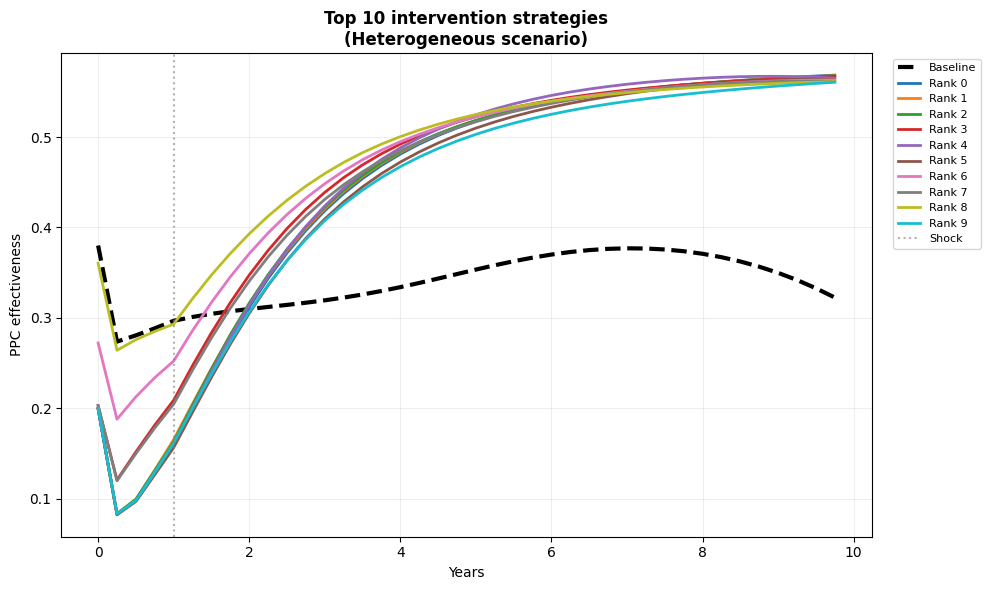

In [55]:
# ============================================================
# PPC EFFECTIVENESS OF TOP 10 SHOCK COMBINATIONS
# ============================================================


# ------------------------------------------------------------
# Select top 10 combinations
# ------------------------------------------------------------

top10 = (
    df_all_combos
    .sort_values(
        "shock_effectiveness",
        ascending=False
    )
    .head(10)
)

# ------------------------------------------------------------
# Baseline
# ------------------------------------------------------------

baseline_history = run_simulation(
    data,
    signed_matrices,
    steps=STEPS,
    seed=42,
    initial_indicators=initial_scenarios["heterogeneous"]
)

t_years = [h["t"] * 3 / 12 for h in baseline_history]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

# baseline
plt.plot(
    t_years,
    [h["ppc_effectiveness"] for h in baseline_history],
    color="black",
    linewidth=3,
    linestyle="--",
    label="Baseline"
)

# top 10
for idx, row in top10.iterrows():

    shocked = copy.deepcopy(
        initial_scenarios["heterogeneous"]
    )

    for parameter, shock in row["shock_pattern"].items():

        shocked[parameter] = np.clip(
            shocked[parameter] + shock,
            0,
            1
        )

    history = run_simulation(
        data,
        signed_matrices,
        steps=STEPS,
        seed=42,
        initial_indicators=shocked
    )

    plt.plot(
        t_years,
        [h["ppc_effectiveness"] for h in history],
        linewidth=2,
        label=f"Rank {len(plt.gca().lines)-1}"
    )

plt.axvline(
    1,
    color="grey",
    linestyle=":",
    alpha=0.6,
    label="Shock"
)

plt.xlabel("Years")
plt.ylabel("PPC effectiveness")
plt.title(
    "Top 10 intervention strategies\n(Heterogeneous scenario)",
    fontweight="bold"
)

plt.grid(alpha=0.2)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

plt.show()

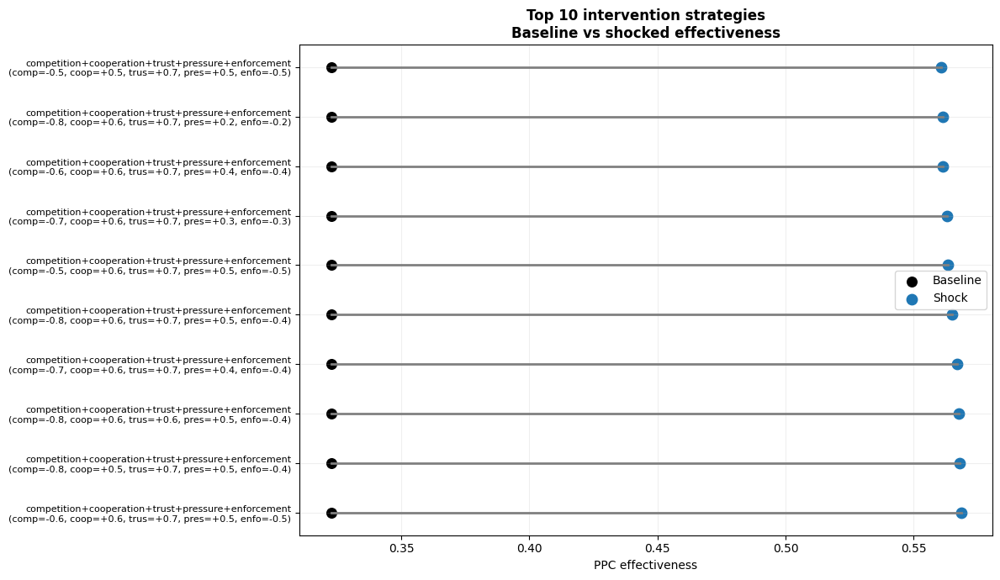

In [56]:


# -------------------------------------------------
# Top 10 interventions
# -------------------------------------------------

top10 = (
    df_heterogeneous_all_shock_combinations
    .nlargest(10, "shock_effectiveness")
    .copy()
)

fig, ax = plt.subplots(figsize=(12,7))

y = np.arange(len(top10))

for i, (_, row) in enumerate(top10.iterrows()):

    baseline = row["baseline_effectiveness"]
    shocked = row["shock_effectiveness"]

    ax.plot(
        [baseline, shocked],
        [i, i],
        color="grey",
        lw=2
    )

    ax.scatter(
        baseline,
        i,
        color="black",
        s=70,
        label="Baseline" if i==0 else ""
    )

    ax.scatter(
        shocked,
        i,
        color="tab:blue",
        s=80,
        label="Shock" if i==0 else ""
    )

labels = []

for _, row in top10.iterrows():

    shock_string = ", ".join(
        f"{k[:4]}={v:+.1f}"
        for k,v in row["shock_pattern"].items()
    )

    labels.append(
        row["parameter_combination"] +
        "\n(" + shock_string + ")"
    )

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)

ax.set_xlabel("PPC effectiveness")
ax.set_title(
    "Top 10 intervention strategies\nBaseline vs shocked effectiveness",
    fontweight="bold"
)

ax.legend()
ax.grid(alpha=.2)

plt.tight_layout()
plt.show()

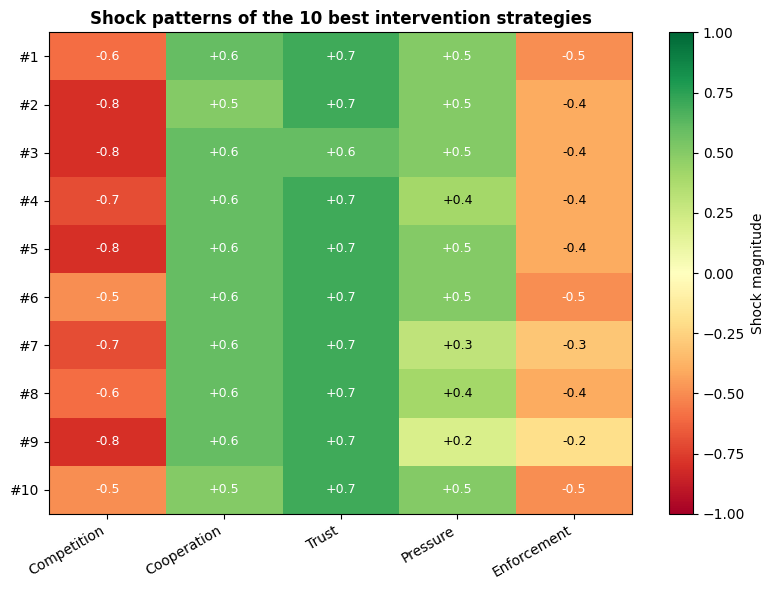

In [57]:


# -------------------------------------------------
# Choose your colour map here
# -------------------------------------------------

CMAP = "RdYlGn"      # Examples:
# "coolwarm"
# "RdBu"
# "RdYlGn"
# "viridis"
# "plasma"
# "Spectral"
# "bwr"
# "PiYG"
# "BrBG"
# "PRGn"
# "PuOr"
# "seismic"

# -------------------------------------------------

top10 = (
    df_heterogeneous_all_shock_combinations
    .nlargest(10, "shock_effectiveness")
    .copy()
)

heat = []

for _, row in top10.iterrows():

    pattern = row["shock_pattern"]

    heat.append([
        pattern.get("competition", 0),
        pattern.get("cooperation", 0),
        pattern.get("trust", 0),
        pattern.get("pressure", 0),
        pattern.get("enforcement", 0)
    ])

heat = pd.DataFrame(
    heat,
    columns=[
        "Competition",
        "Cooperation",
        "Trust",
        "Pressure",
        "Enforcement"
    ]
)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    heat,
    cmap=CMAP,          # <-- Change colour map here
    aspect="auto",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(
    heat.columns,
    rotation=30,
    ha="right"
)

ax.set_yticks(range(10))
ax.set_yticklabels(
    [f"#{i}" for i in range(1, 11)]
)

ax.set_title(
    "Shock patterns of the 10 best intervention strategies",
    fontweight="bold"
)

# Automatically choose black/white text for readability
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):

        value = heat.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:+.1f}",
            ha="center",
            va="center",
            fontsize=9,
            color="white" if abs(value) > 0.45 else "black"
        )

cbar = plt.colorbar(
    im,
    label="Shock magnitude"
)

plt.tight_layout()
plt.show()

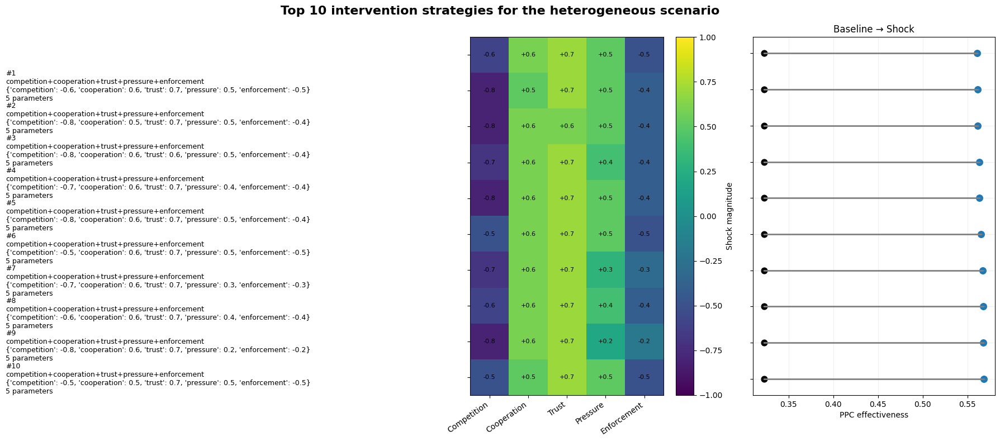

In [58]:

top10 = (
    df_heterogeneous_all_shock_combinations
    .nlargest(10, "shock_effectiveness")
    .copy()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,8),
    gridspec_kw={"width_ratios":[3.5,2,2]}
)

ax0, ax1, ax2 = axes

# --------------------------------------------------
# Left: intervention description
# --------------------------------------------------

ax0.axis("off")

for i, (_, row) in enumerate(top10.iterrows()):

    txt = (
        f"#{i+1}\n"
        f"{row['parameter_combination']}\n"
        f"{row['shock_pattern']}\n"
        f"{row['number_of_parameters']} parameters"
    )

    ax0.text(
        0,
        10-i,
        txt,
        fontsize=9,
        va="top"
    )

ax0.set_ylim(0,11)

# --------------------------------------------------
# Middle: shock vectors
# --------------------------------------------------

params = [
    "competition",
    "cooperation",
    "trust",
    "pressure",
    "enforcement"
]

heat = np.zeros((10,5))

for i, (_, row) in enumerate(top10.iterrows()):

    for j,p in enumerate(params):

        heat[i,j] = row["shock_pattern"].get(p,0)

im = ax1.imshow(
    heat,
    aspect="auto",
    vmin=-1,
    vmax=1
)

ax1.set_xticks(range(5))
ax1.set_xticklabels(
    [p.capitalize() for p in params],
    rotation=35,
    ha="right"
)

ax1.set_yticks(range(10))
ax1.set_yticklabels([])

for i in range(10):
    for j in range(5):

        ax1.text(
            j,
            i,
            f"{heat[i,j]:+.1f}",
            ha="center",
            va="center",
            fontsize=8
        )

# --------------------------------------------------
# Right: effectiveness comparison
# --------------------------------------------------

y = np.arange(10)

for i, (_, row) in enumerate(top10.iterrows()):

    ax2.plot(
        [
            row["baseline_effectiveness"],
            row["shock_effectiveness"]
        ],
        [i,i],
        color="grey",
        lw=2
    )

    ax2.scatter(
        row["baseline_effectiveness"],
        i,
        color="black",
        s=60
    )

    ax2.scatter(
        row["shock_effectiveness"],
        i,
        color="tab:blue",
        s=70
    )

ax2.set_yticks(y)
ax2.set_yticklabels([])

ax2.set_xlabel("PPC effectiveness")

ax2.set_title("Baseline → Shock")

ax2.grid(alpha=.2)

plt.colorbar(
    im,
    ax=ax1,
    label="Shock magnitude"
)

fig.suptitle(
    "Top 10 intervention strategies for the heterogeneous scenario",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [59]:
df_best_by_parameter_count = (
    df_all_combos
    .sort_values(
        "shock_effectiveness",
        ascending=False
    )
    .groupby(
        "number_of_parameters",
        as_index=False
    )
    .first()
    .reset_index(drop=True)
)

df_best_by_parameter_count

,number_of_parameters,parameter_combination,shock_pattern,shock_vector,shock_effectiveness,baseline_effectiveness,effectiveness_change
0,1,cooperation,{'cooperation': 0.3},"(0.3,)",0.456146,0.322541,0.133605
1,2,competition+trust,"{'competition': -0.4, 'trust': 0.7}","(-0.4, 0.7)",0.481767,0.322541,0.159226
2,3,competition+cooperation+trust,"{'competition': -0.8, 'cooperation': 0.5, 'tru...","(-0.8, 0.5, 0.7)",0.538622,0.322541,0.216081
3,4,cooperation+trust+pressure+enforcement,"{'cooperation': 0.6, 'trust': 0.7, 'pressure':...","(0.6, 0.7, 0.5, -0.7)",0.555122,0.322541,0.232581
4,5,competition+cooperation+trust+pressure+enforce...,"{'competition': -0.6, 'cooperation': 0.6, 'tru...","(-0.6, 0.6, 0.7, 0.5, -0.5)",0.568490,0.322541,0.245950


In [60]:
df_best_by_parameter_count = (
    df_all_combos
    .loc[
        df_all_combos
        .groupby("number_of_parameters")["shock_effectiveness"]
        .idxmax()
    ]
    .sort_values(
        "number_of_parameters"
    )
    .reset_index(drop=True)
)

df_best_by_parameter_count

,parameter_combination,number_of_parameters,shock_pattern,shock_vector,shock_effectiveness,baseline_effectiveness,effectiveness_change
0,cooperation,1,{'cooperation': 0.3},"(0.3,)",0.456146,0.322541,0.133605
1,competition+trust,2,"{'competition': -0.4, 'trust': 0.7}","(-0.4, 0.7)",0.481767,0.322541,0.159226
2,competition+cooperation+trust,3,"{'competition': -0.8, 'cooperation': 0.5, 'tru...","(-0.8, 0.5, 0.7)",0.538622,0.322541,0.216081
3,cooperation+trust+pressure+enforcement,4,"{'cooperation': 0.6, 'trust': 0.7, 'pressure':...","(0.6, 0.7, 0.5, -0.7)",0.555122,0.322541,0.232581
4,competition+cooperation+trust+pressure+enforce...,5,"{'competition': -0.6, 'cooperation': 0.6, 'tru...","(-0.6, 0.6, 0.7, 0.5, -0.5)",0.568490,0.322541,0.245950


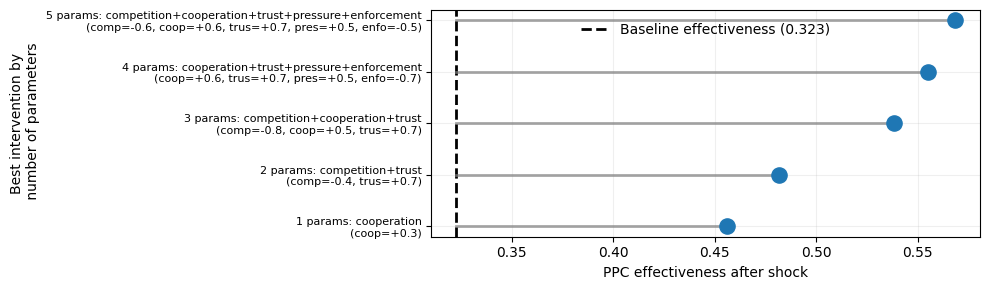

In [74]:



# -------------------------------------------------
# Prepare data
# -------------------------------------------------

df_param_amounts = (
    df_best_by_parameter_count
    .sort_values(
        "number_of_parameters"
    )
    .copy()
)


# -------------------------------------------------
# Plot
# -------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10,3)
)


y = np.arange(
    len(df_param_amounts)
)


# baseline line
baseline = df_param_amounts["baseline_effectiveness"].iloc[0]

ax.axvline(
    baseline,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Baseline effectiveness ({baseline:.3f})"
)


# effectiveness points

ax.scatter(
    df_param_amounts["shock_effectiveness"],
    y,
    s=120,
    color="tab:blue",
    zorder=3
)


# improvement lines

for i, (_, row) in enumerate(df_param_amounts.iterrows()):

    ax.plot(
        [
            row["baseline_effectiveness"],
            row["shock_effectiveness"]
        ],
        [
            i,
            i
        ],
        color="grey",
        linewidth=2,
        alpha=0.7
    )


# labels

labels = []

for _, row in df_param_amounts.iterrows():

    shock_text = ", ".join(
        [
            f"{k[:4]}={v:+.1f}"
            for k,v in row["shock_pattern"].items()
        ]
    )

    labels.append(
        f"{row['number_of_parameters']} params: "
        f"{row['parameter_combination']}\n"
        f"({shock_text})"
    )


ax.set_yticks(y)
ax.set_yticklabels(
    labels,
    fontsize=8
)


ax.set_xlabel(
    "PPC effectiveness after shock"
)

ax.set_ylabel(
    "Best intervention by\n number of parameters"
)


# ax.set_title(
#     "Optimal shock effectiveness by intervention complexity",
#     fontsize=14,
#     fontweight="bold"
# )


ax.grid(
    alpha=0.2
)


ax.legend(
    frameon=False
)


plt.tight_layout()
plt.show()

#### Sensitivity analysis on which param is most effective for effectiveness

In [62]:
# ============================================================
# PARAMETER SENSITIVITY ANALYSIS
# Based on df_heterogeneous_all_shock_combinations
# ============================================================



df = df_heterogeneous_all_shock_combinations.copy()


# ------------------------------------------------------------
# Extract parameter-level effects
# ------------------------------------------------------------

parameter_records = []


for _, row in df.iterrows():

    params = row["parameter_combination"].split("+")

    for p in params:

        parameter_records.append({

            "parameter": p,

            "effectiveness_change":
                row["effectiveness_change"],

            "shock_effectiveness":
                row["shock_effectiveness"],

            "shock_magnitude":
                abs(
                    row["shock_vector"][
                        params.index(p)
                    ]
                ),

            "shock_direction":
                np.sign(
                    row["shock_vector"][
                        params.index(p)
                    ]
                )

        })


df_parameter_effects = pd.DataFrame(
    parameter_records
)



# ------------------------------------------------------------
# Aggregate sensitivity metrics
# ------------------------------------------------------------

df_parameter_sensitivity = (
    df_parameter_effects
    .groupby("parameter")
    .agg(

        mean_effectiveness_change=(
            "effectiveness_change",
            "mean"
        ),

        max_effectiveness_change=(
            "effectiveness_change",
            "max"
        ),

        mean_absolute_effect=(
            "effectiveness_change",
            lambda x: np.mean(np.abs(x))
        ),

        average_shock_magnitude=(
            "shock_magnitude",
            "mean"
        ),

        number_of_tests=(
            "effectiveness_change",
            "count"
        )

    )
    .reset_index()
)



df_parameter_sensitivity = (
    df_parameter_sensitivity
    .sort_values(
        "mean_effectiveness_change",
        ascending=False
    )
    .reset_index(drop=True)
)



df_parameter_sensitivity

,parameter,mean_effectiveness_change,max_effectiveness_change,mean_absolute_effect,average_shock_magnitude,number_of_tests
0,trust,-0.203952,0.24595,0.233707,0.34,146410
1,cooperation,-0.204584,0.24595,0.234091,0.31,146410
2,pressure,-0.206165,0.24595,0.234941,0.30,146410
3,competition,-0.207070,0.24595,0.236043,0.39,146410
4,enforcement,-0.210883,0.24595,0.238434,0.34,146410


### end of combination shocks

## sensitivity analysis

In [63]:
# ============================================================
# Sensitivity analysis:
# Which relational parameter contributes most to effectiveness?
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

parameters = [
    "competition",
    "cooperation",
    "trust",
    "pressure",
    "enforcement"
]

results = []

for p in parameters:

    temp = []

    for _, row in df_heterogeneous_all_shock_combinations.iterrows():

        shock = row["shock_pattern"].get(p, 0)

        temp.append({
            "shock": shock,
            "effectiveness": row["shock_effectiveness"]
        })

    temp = pd.DataFrame(temp)

    results.append({

        "parameter": p,

        "pearson_r":
            temp["shock"].corr(
                temp["effectiveness"],
                method="pearson"
            ),

        "spearman_r":
            temp["shock"].corr(
                temp["effectiveness"],
                method="spearman"
            ),

        "mean_shock":
            temp["shock"].mean(),

        "std_shock":
            temp["shock"].std()

    })


df_parameter_sensitivity = (
    pd.DataFrame(results)
    .sort_values(
        "pearson_r",
        ascending=False
    )
    .reset_index(drop=True)
)

display(df_parameter_sensitivity)

,parameter,pearson_r,spearman_r,mean_shock,std_shock
0,enforcement,0.429393,0.516370,-2.000012e-01,0.316229
1,pressure,0.335285,0.406063,5.647282e-18,0.316230
2,cooperation,0.141526,0.158329,1.000006e-01,0.316230
3,trust,0.136239,0.150374,2.000012e-01,0.316229
4,competition,0.117722,0.150150,-3.000019e-01,0.316229


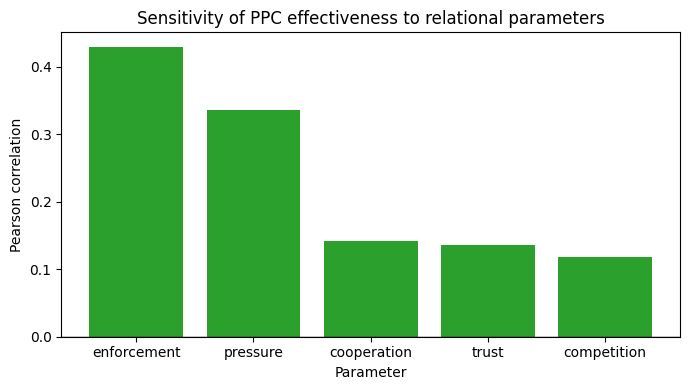

In [64]:
plt.figure(figsize=(7,4))

colors = [
    "tab:green" if x > 0 else "tab:red"
    for x in df_parameter_sensitivity["pearson_r"]
]

plt.bar(
    df_parameter_sensitivity["parameter"],
    df_parameter_sensitivity["pearson_r"],
    color=colors
)

plt.axhline(
    0,
    color="black",
    linewidth=1
)

plt.ylabel("Pearson correlation")
plt.xlabel("Parameter")
plt.title("Sensitivity of PPC effectiveness to relational parameters")

plt.tight_layout()
plt.show()

In [65]:
import ast
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Ensure 'pressure_level' exists
if "pressure_level" not in df_heterogeneous_all_shock_combinations.columns:

    def extract_pressure(pattern):
        if isinstance(pattern, str):
            pattern = ast.literal_eval(pattern)
        return pattern.get("pressure", np.nan)

    df_heterogeneous_all_shock_combinations["pressure_level"] = (
        df_heterogeneous_all_shock_combinations["shock_pattern"].apply(
            extract_pressure
        )
    )

# Filter for pressure range [0.0, 1.0]
df_filtered = df_heterogeneous_all_shock_combinations[
    (df_heterogeneous_all_shock_combinations["pressure_level"] >= 0.0)
    & (df_heterogeneous_all_shock_combinations["pressure_level"] <= 1.0)
].copy()

# 2. Identify potential year/time columns
possible_year_cols = [
    col
    for col in ["year", "Year", "timestep", "time", "step", "t"]
    if col in df_filtered.columns
]
metric_col = "shock_effectiveness"

if possible_year_cols:
    year_col = possible_year_cols[0]
    unique_years = sorted(df_filtered[year_col].unique())
    print(
        f"Detected time column '{year_col}' with values: {unique_years[:5]}..."
    )

    # Plot each year separately in a single comparison figure
    plt.figure(figsize=(10, 6))

    for y in unique_years:
        df_y = df_filtered[df_filtered[year_col] == y]
        sens_y = (
            df_y.groupby("pressure_level")[metric_col].mean().reset_index()
        )

        # Sweet spot for this specific year
        opt_idx = sens_y[metric_col].idxmax()
        opt_p = sens_y.loc[opt_idx, "pressure_level"]
        opt_score = sens_y.loc[opt_idx, metric_col]

        print(
            f"Year {y:2d} -> Sweet Spot Pressure: {opt_p} | Max {metric_col}: {opt_score:.6f}"
        )

        plt.plot(
            sens_y["pressure_level"],
            sens_y[metric_col],
            marker="o",
            linewidth=2,
            label=f"Year {y}",
        )

    plt.xlim(0.0, 1.0)
    plt.title(
        f"Pressure Sensitivity Analysis Across Years ({metric_col})",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Pressure Shock Value", fontsize=12)
    plt.ylabel(f"Mean {metric_col}", fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(title="Years")
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ No explicit 'year' column found in DataFrame columns:")
    print(df_filtered.columns.tolist())
    print(
        "\nIf the simulation outputs multiple timesteps per combination, check if time steps are nested in vectors or separate DataFrames."
    )

⚠️ No explicit 'year' column found in DataFrame columns:
['parameter_combination', 'number_of_parameters', 'shock_pattern', 'shock_vector', 'shock_effectiveness', 'baseline_effectiveness', 'effectiveness_change', 'pressure_level']

If the simulation outputs multiple timesteps per combination, check if time steps are nested in vectors or separate DataFrames.


Year 1 -> Sweet Spot Pressure: 0.5 | Max Effectiveness: 0.993926
Year 2 -> Sweet Spot Pressure: 0.5 | Max Effectiveness: 1.162075
Year 3 -> Sweet Spot Pressure: 0.5 | Max Effectiveness: 1.324564
Year 4 -> Sweet Spot Pressure: 0.5 | Max Effectiveness: 1.479443
Year 5 -> Sweet Spot Pressure: 0.5 | Max Effectiveness: 1.624324


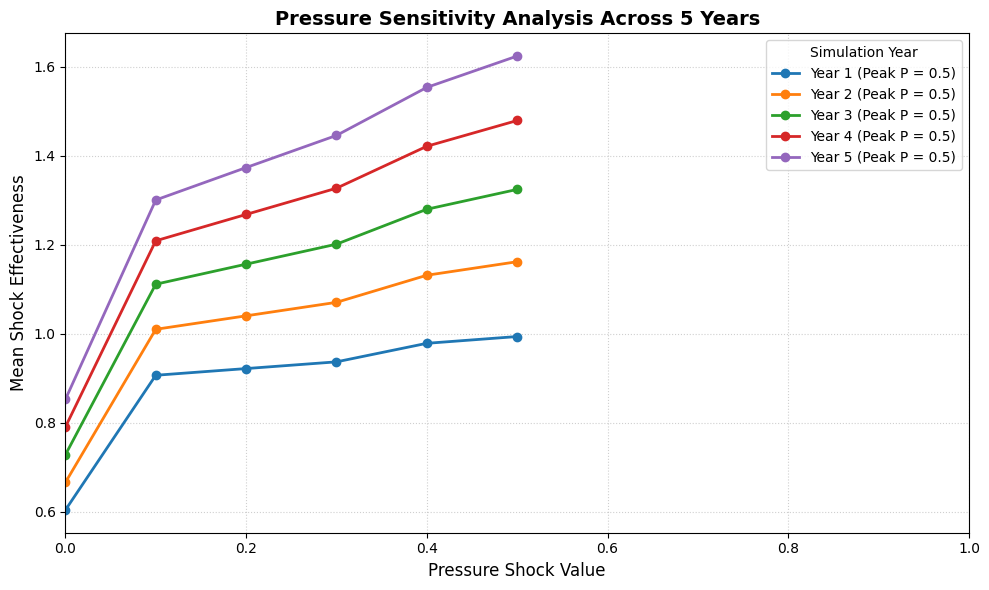

In [66]:
import ast
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# 1. Robust vector parser with fixed length (5)
def parse_vector_fixed(val, target_len=5):
    if isinstance(val, str):
        try:
            val = ast.literal_eval(val)
        except Exception:
            return [0.0] * target_len

    # Flatten if nested (e.g., ((1,2,3,4,5),))
    if (
        isinstance(val, (tuple, list))
        and len(val) == 1
        and isinstance(val[0], (tuple, list))
    ):
        val = val[0]

    # Convert to list of floats
    res = [float(x) for x in val]

    # Ensure exact length of 5
    if len(res) < target_len:
        res.extend([0.0] * (target_len - len(res)))
    elif len(res) > target_len:
        res = res[:target_len]

    return res


# Parse shock_vector safely into a 2D NumPy array
parsed_vectors = [
    parse_vector_fixed(v)
    for v in df_heterogeneous_all_shock_combinations["shock_vector"]
]
shock_matrix = np.array(parsed_vectors, dtype=float)  # Shape: (161050, 5)

# Baseline state (0.2 for each variable)
baseline = 0.2
state = np.clip(baseline + shock_matrix, 0.0, 1.0)

# 2. Interaction Matrix M (5 x 5)
# Columns: [competition, cooperation, trust, pressure, enforcement]
M = np.array(
    [
        [0.0, -0.5, -0.2, 0.2, 0.0],  # competition
        [-0.5, 0.0, 0.8, -0.5, 0.0],  # cooperation
        [-0.8, 0.8, 0.0, -0.2, 0.0],  # trust
        [0.2, 0.8, 0.0, 0.0, 0.8],  # pressure
        [0.0, -0.8, 0.0, 0.5, 0.0],  # enforcement
    ]
)

# Effectiveness weights: [+cooperation, +trust, +enforcement, -competition]
weights = np.array([-1.0, 1.0, 1.0, 0.0, 1.0])

# Extract pressure levels (4th element in vector: index 3)
df_analysis = df_heterogeneous_all_shock_combinations.copy()
df_analysis["pressure_level"] = shock_matrix[:, 3]

# Filter for pressure levels between 0.0 and 1.0
valid_mask = (df_analysis["pressure_level"] >= 0.0) & (
    df_analysis["pressure_level"] <= 1.0
)
df_filtered = df_analysis[valid_mask].copy()
state_filtered = state[valid_mask]

# 3. Fast Vectorized Simulation across 5 years (< 2 seconds)
lr = 0.1

plt.figure(figsize=(10, 6))

for year in range(1, 6):
    # Matrix update: State = State + lr * (State @ M)
    delta = state_filtered @ M
    state_filtered = np.clip(state_filtered + lr * delta, 0.0, 1.0)

    # Compute effectiveness
    effectiveness = state_filtered @ weights
    df_filtered[f"year_{year}"] = effectiveness

    # Group by pressure level
    sens_y = (
        df_filtered.groupby("pressure_level")[f"year_{year}"]
        .mean()
        .reset_index()
    )

    opt_idx = sens_y[f"year_{year}"].idxmax()
    opt_p = sens_y.loc[opt_idx, "pressure_level"]
    max_score = sens_y.loc[opt_idx, f"year_{year}"]

    print(
        f"Year {year} -> Sweet Spot Pressure: {opt_p} | Max Effectiveness: {max_score:.6f}"
    )

    plt.plot(
        sens_y["pressure_level"],
        sens_y[f"year_{year}"],
        marker="o",
        linewidth=2,
        label=f"Year {year} (Peak P = {opt_p})",
    )

plt.xlim(0.0, 1.0)
plt.title(
    "Pressure Sensitivity Analysis Across 5 Years",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Pressure Shock Value", fontsize=12)
plt.ylabel("Mean Shock Effectiveness", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(title="Simulation Year")
plt.tight_layout()
plt.show()

In [67]:
# import scipy.stats as stats

# # 1. Prepare parameter matrix and names
# param_names = [
#     "competition",
#     "cooperation",
#     "trust",
#     "pressure",
#     "enforcement",
# ]

# # Create a DataFrame of the shock parameters (161050 rows x 5 columns)
# df_params = pd.DataFrame(shock_matrix, columns=param_names)

# # 2. Compute Pearson correlations for each year separately
# yearly_correlations = {}

# for year in range(1, 6):
#     y_col = f"year_{year}"
#     y_values = df_filtered[y_col].values

#     # Compute correlation between each parameter shock and year effectiveness
#     corrs = []
#     for param in param_names:
#         r, _ = stats.pearsonr(df_params.loc[valid_mask, param], y_values)
#         corrs.append(r)

#     yearly_correlations[f"Year {year}"] = corrs

# df_sens_by_year = pd.DataFrame(yearly_correlations, index=param_names)
# print("--- Pearson Correlations by Year ---")
# print(df_sens_by_year)


# # 3. Option A: Plot 5 Individual Bar Charts (1 per year)
# for year in range(1, 6):
#     y_key = f"Year {year}"
#     r_vals = df_sens_by_year[y_key]
#     colors = ["tab:green" if x > 0 else "tab:red" for x in r_vals]

#     plt.figure(figsize=(7, 4))
#     plt.bar(param_names, r_vals, color=colors)
#     plt.axhline(0, color="black", linewidth=1)

#     plt.ylabel("Pearson correlation")
#     plt.xlabel("Parameter")
#     plt.title(
#         f"Sensitivity of Effectiveness to Relational Parameters ({y_key})"
#     )

#     plt.ylim(-1.0, 1.0)
#     plt.tight_layout()
#     plt.show()

### can we run sensitivity per year!

In [68]:
# import scipy.stats as stats

# # 1. Prepare parameter matrix and names
# param_names = [
#     "competition",
#     "cooperation",
#     "trust",
#     "pressure",
#     "enforcement",
# ]

# # Create a DataFrame of the shock parameters (161050 rows x 5 columns)
# df_params = pd.DataFrame(shock_matrix, columns=param_names)

# # 2. Compute Pearson correlations for each year separately
# yearly_correlations = {}

# for year in range(0, 6):
#     y_col = f"year_{year}"
#     y_values = df_filtered[y_col].values

#     # Compute correlation between each parameter shock and year effectiveness
#     corrs = []
#     for param in param_names:
#         r, _ = stats.pearsonr(df_params.loc[valid_mask, param], y_values)
#         corrs.append(r)

#     yearly_correlations[f"Year {year}"] = corrs

# df_sens_by_year = pd.DataFrame(yearly_correlations, index=param_names)
# print("--- Pearson Correlations by Year ---")
# print(df_sens_by_year)


# # 3. Option A: Plot 5 Individual Bar Charts (1 per year)
# for year in range(0, 6):
#     y_key = f"Year {year}"
#     r_vals = df_sens_by_year[y_key]
#     colors = ["tab:green" if x > 0 else "tab:red" for x in r_vals]

#     plt.figure(figsize=(7, 4))
#     plt.bar(param_names, r_vals, color=colors)
#     plt.axhline(0, color="black", linewidth=1)

#     plt.ylabel("Pearson correlation")
#     plt.xlabel("Parameter")
#     plt.title(
#         f"Sensitivity of Effectiveness to Relational Parameters ({y_key})"
#     )

#     plt.ylim(-1.0, 1.0)
#     plt.tight_layout()
#     plt.show()

In [69]:
# Grouped Bar Plot across all 5 years
x = np.arange(len(param_names))
width = 0.15

plt.figure(figsize=(10, 5))

for i, year in enumerate(range(1, 6)):
    y_key = f"Year {year}"
    plt.bar(
        x + i * width,
        df_sens_by_year[y_key],
        width,
        label=y_key,
    )

plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Pearson correlation")
plt.xlabel("Parameter")
plt.xticks(x + width * 2, param_names)
plt.title(
    "Parameter Sensitivity (Pearson Correlation) Across Years 1-5",
    fontsize=13,
    fontweight="bold",
)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'param_names' is not defined

In [ ]:
df_heterogeneous_all_shock_combinations.columns

Index(['parameter_combination', 'number_of_parameters', 'shock_pattern',
       'shock_vector', 'shock_effectiveness', 'baseline_effectiveness',
       'effectiveness_change', 'pressure_level'],
      dtype='object')

### multi year sensitivity


In [ ]:
# Step 1: Select top 20 shock combinations per 'number_of_parameters' based on 'shock_effectiveness'
top20_combinations = (
    df_heterogeneous_all_shock_combinations
    .groupby("number_of_parameters", group_keys=False)
    .apply(lambda group: group.nlargest(20, "shock_effectiveness"))
    .reset_index(drop=True)
)

print(f"Selected {len(top20_combinations)} top combinations across parameter counts.")

Selected 100 top combinations across parameter counts.


C:\Users\foetker\AppData\Local\Temp\ipykernel_24916\1408220296.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.nlargest(20, "shock_effectiveness"))


In [ ]:
#For just top 20 overall, uncomment the following line:

# NUM_YEARS = 5

# def run_100_sensitivity(base_skills_df, initial_rel_params, shocks, years=NUM_YEARS):
#     history = []
#     current_skills = base_skills_df.copy()
#     current_params = pd.Series(initial_rel_params)

#     for yr in range(years):
#         # Apply initial shock at Year 0
#         if yr == 0 and shocks:
#             for skill, shock_val in shocks.items():
#                 if skill in current_skills.columns:
#                     current_skills[skill] += shock_val

#         # Record state for current year
#         history.append({
#             "year": yr,
#             "skills": current_skills.copy(),
#             "relation_params": current_params.copy()
#         })

#         # --- Corrected Network Influence Updates ---
#         # 1. Parameter -> Skill updates: (5,) @ (5, 11) -> (11,)
#         skill_delta_vals = current_params.values @ signed_param_skill.values
#         skill_delta = pd.Series(skill_delta_vals, index=signed_param_skill.columns)

#         # 2. Skill -> Parameter updates: (11,) @ (11, 5) -> (5,)
#         param_delta_skills_vals = current_skills.mean().values @ signed_skill_param.values
        
#         # 3. Parameter -> Parameter updates: (5,) @ (5, 5) -> (5,)
#         param_delta_rel_vals = current_params.values @ signed_rel_rel.values
        
#         param_delta = pd.Series(
#             param_delta_skills_vals + param_delta_rel_vals, 
#             index=current_params.index
#         )

#         # Apply state updates
#         current_skills = current_skills + (skill_delta * 0.1)
#         current_params = current_params + (param_delta * 0.1)

#     return history


# # Execute simulation over top20_combinations using run_100_sensitivity
# yearly_simulation_records = []

# for idx, row in tqdm(top20_combinations.iterrows(), total=len(top20_combinations), desc="Simulating Top Combos"):
#     combo_id = row["parameter_combination"]
    
#     # Parse shock_vector into dict
#     shocks = row["shock_vector"]
#     if not isinstance(shocks, dict) and hasattr(shocks, "to_dict"):
#         shocks = shocks.to_dict()
#     elif not isinstance(shocks, dict):
#         shocks = {}
    
#     # Run time-series simulation with the new function name
#     history = run_100_sensitivity(
#         base_skills_df=data["skills_df"],
#         initial_rel_params=initial_scenarios["heterogeneous"],
#         shocks=shocks,
#         years=NUM_YEARS
#     )
    
#     # Unpack yearly steps into flat table
#     for step in history:
#         record = {
#             "parameter_combination": combo_id,
#             "number_of_parameters": row["number_of_parameters"],
#             "shock_pattern": row["shock_pattern"],
#             "shock_effectiveness": row["shock_effectiveness"],
#             "baseline_effectiveness": row["baseline_effectiveness"],
#             "effectiveness_change": row["effectiveness_change"],
#             "pressure_level": row["pressure_level"],
#             "year": step["year"],
#         }
        
#         # Add yearly relational parameters
#         for p_name, p_val in step["relation_params"].items():
#             record[f"param_{p_name}"] = p_val
            
#         # Add yearly macro skill means
#         for s_name, s_val in step["skills"].mean().items():
#             record[f"skill_{s_name}"] = s_val
            
#         yearly_simulation_records.append(record)

# # Final output DataFrame for annual sensitivity analysis
# df_top_yearly = pd.DataFrame(yearly_simulation_records)

# ============================================================
# 1. Full Scope Simulation Execution
# ============================================================

full_simulation_records = []

for idx, row in tqdm(df_heterogeneous_all_shock_combinations.iterrows(), 
                    total=len(df_heterogeneous_all_shock_combinations), 
                    desc="Simulating Full Scope"):
    
    combo_id = row["parameter_combination"]
    
    # Parse shock_vector / shock_pattern
    shocks = row["shock_vector"]
    if not isinstance(shocks, dict) and hasattr(shocks, "to_dict"):
        shocks = shocks.to_dict()
    elif not isinstance(shocks, dict):
        shocks = {}

    # Run time-series simulation
    history = run_100_sensitivity(
        base_skills_df=data["skills_df"],
        initial_rel_params=initial_scenarios["heterogeneous"],
        shocks=shocks,
        years=NUM_YEARS
    )
    
    # Unpack yearly steps
    for step in history:
        record = {
            "parameter_combination": combo_id,
            "number_of_parameters": row["number_of_parameters"],
            "shock_pattern": row["shock_pattern"],
            "shock_effectiveness": row["shock_effectiveness"],
            "baseline_effectiveness": row["baseline_effectiveness"],
            "effectiveness_change": row["effectiveness_change"],
            "pressure_level": row["pressure_level"],
            "year": step["year"],
        }
        
        # Add yearly relational parameters
        for p_name, p_val in step["relation_params"].items():
            record[f"param_{p_name}"] = p_val
            
        # Add yearly macro skill means
        for s_name, s_val in step["skills"].mean().items():
            record[f"skill_{s_name}"] = s_val
            
        full_simulation_records.append(record)

df_full_yearly = pd.DataFrame(full_simulation_records)

Simulating Full Scope:   0%|          | 0/161050 [00:00<?, ?it/s]

In [ ]:
df_full_yearly.head(5)

,parameter_combination,number_of_parameters,shock_pattern,shock_effectiveness,baseline_effectiveness,effectiveness_change,pressure_level,year,param_competition,param_cooperation,...,skill_Punishment Mentality,skill_Enforcement of rules/laws,skill_Pressure,skill_Economic Capital,skill_Cultural Capital,skill_Social Capital,skill_Reputation,skill_Sense of Urgency,skill_Formal responsibility,skill_Informal Responsibility
0,competition+cooperation+trust+pressure+enforcement,5,"{'competition': -0.6, 'cooperation': 0.6, 'trust': 0.7, 'pressure': 0.5, 'enforcement': -0.5}",0.56849,0.322541,0.24595,0.5,0,0.800000,0.400000,...,0.650000,0.457143,0.392857,0.478571,0.500000,0.564286,-0.778571,0.735714,0.307143,0.392857
1,competition+cooperation+trust+pressure+enforcement,5,"{'competition': -0.6, 'cooperation': 0.6, 'trust': 0.7, 'pressure': 0.5, 'enforcement': -0.5}",0.56849,0.322541,0.24595,0.5,1,0.919000,0.686429,...,0.824000,0.586143,0.566857,0.571571,0.576000,0.667286,-0.625571,0.870714,0.429143,0.481857
2,competition+cooperation+trust+pressure+enforcement,5,"{'competition': -0.6, 'cooperation': 0.6, 'trust': 0.7, 'pressure': 0.5, 'enforcement': -0.5}",0.56849,0.322541,0.24595,0.5,2,1.074664,1.071640,...,1.055487,0.762218,0.806995,0.707905,0.692226,0.826091,-0.422156,1.056400,0.616354,0.620404
3,competition+cooperation+trust+pressure+enforcement,5,"{'competition': -0.6, 'cooperation': 0.6, 'trust': 0.7, 'pressure': 0.5, 'enforcement': -0.5}",0.56849,0.322541,0.24595,0.5,3,1.282666,1.595394,...,1.365572,1.003149,1.136847,0.902936,0.862585,1.059960,-0.150262,1.310997,0.892381,0.826091
4,competition+cooperation+trust+pressure+enforcement,5,"{'competition': -0.6, 'cooperation': 0.6, 'trust': 0.7, 'pressure': 0.5, 'enforcement': -0.5}",0.56849,0.322541,0.24595,0.5,4,1.563862,2.312122,...,1.783957,1.333872,1.589634,1.178357,1.106705,1.396074,0.215578,1.660162,1.290417,1.123720


In [ ]:
NUM_YEARS = 5

def run_100_sensitivity(base_skills_df, initial_rel_params, shocks, years=NUM_YEARS):
    history = []
    current_skills = base_skills_df.copy()
    current_params = pd.Series(initial_rel_params).copy()

    for yr in range(years):
        # Apply initial shocks at Year 0 to BOTH skills and relational parameters
        if yr == 0 and shocks:
            for k, shock_val in shocks.items():
                if k in current_skills.columns:
                    current_skills[k] += shock_val
                elif k in current_params.index:
                    current_params[k] += shock_val  # <--- THIS WAS MISSING!

        # Record state for current year
        history.append({
            "year": yr,
            "skills": current_skills.copy(),
            "relation_params": current_params.copy()
        })

        # --- Network Influence Updates ---
        skill_delta_vals = current_params.values @ signed_param_skill.values
        skill_delta = pd.Series(skill_delta_vals, index=signed_param_skill.columns)

        param_delta_skills_vals = current_skills.mean().values @ signed_skill_param.values
        param_delta_rel_vals = current_params.values @ signed_rel_rel.values
        
        param_delta = pd.Series(
            param_delta_skills_vals + param_delta_rel_vals, 
            index=current_params.index
        )

        # Apply updates
        current_skills = current_skills + (skill_delta * 0.1)
        current_params = current_params + (param_delta * 0.1)

    return history

In [ ]:
parameters = [
    "competition",
    "cooperation",
    "trust",
    "pressure",
    "enforcement"
]

yearly_sensitivity_dfs = {}
years = sorted(df_full_yearly["year"].unique())

for year in years:
    df_year = df_full_yearly[df_full_yearly["year"] == year]
    year_results = []

    for p in parameters:
        param_col = f"param_{p}"
        
        temp = pd.DataFrame({
            "param_value": df_year[param_col],
            "effectiveness": df_year["shock_effectiveness"]
        }).dropna()

        year_results.append({
            "parameter": p,
            "pearson_r": temp["param_value"].corr(temp["effectiveness"], method="pearson"),
            "spearman_r": temp["param_value"].corr(temp["effectiveness"], method="spearman"),
            "mean_param": temp["param_value"].mean(),
            "std_param": temp["param_value"].std()
        })

    df_year_sens = (
        pd.DataFrame(year_results)
        .sort_values(by="pearson_r", ascending=False)
        .reset_index(drop=True)
    )
    
    yearly_sensitivity_dfs[year] = df_year_sens
    globals()[f"df_sensitivity_year_{year}"] = df_year_sens

# Display Year 0 to Year 4 sensitivity tables
for year, df_sens in yearly_sensitivity_dfs.items():
    print(f"\n==================== Year {year} Sensitivity ====================")
    display(df_sens)

c:\Users\foetker\Documents\Heatmap Model\myenv\Lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
c:\Users\foetker\Documents\Heatmap Model\myenv\Lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
c:\Users\foetker\Documents\Heatmap Model\myenv\Lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
c:\Users\foetker\Documents\Heatmap Model\myenv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\foetker\Documents\Heatmap Model\myenv\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\


==================== Year 0 Sensitivity ====================


,parameter,pearson_r,spearman_r,mean_param,std_param
0,trust,3.498344e-15,NaN,0.3,1.110226e-16
1,enforcement,3.498344e-15,NaN,0.7,2.220453e-16
2,competition,-2.943010e-15,NaN,0.8,3.330679e-16
3,cooperation,-2.943010e-15,NaN,0.4,1.665340e-16
4,pressure,NaN,NaN,0.5,0.000000e+00



==================== Year 1 Sensitivity ====================


,parameter,pearson_r,spearman_r,mean_param,std_param
0,enforcement,3.498344e-15,NaN,0.935714,4.440906e-16
1,pressure,2.943010e-15,NaN,0.732857,3.330679e-16
2,competition,-3.498344e-15,NaN,0.919000,2.220453e-16
3,trust,-3.498344e-15,NaN,0.537643,1.110226e-16
4,cooperation,NaN,NaN,0.686429,0.000000e+00



==================== Year 2 Sensitivity ====================


,parameter,pearson_r,spearman_r,mean_param,std_param
0,trust,5.299342e-15,NaN,0.860290,7.771585e-16
1,cooperation,3.498344e-15,NaN,1.071640,2.220453e-16
2,enforcement,3.498344e-15,NaN,1.273037,2.220453e-16
3,pressure,-3.498344e-15,NaN,1.045376,4.440906e-16
4,competition,NaN,NaN,1.074664,0.000000e+00



==================== Year 3 Sensitivity ====================


,parameter,pearson_r,spearman_r,mean_param,std_param
0,trust,3.498344e-15,NaN,1.302833,4.440906e-16
1,enforcement,3.498344e-15,NaN,1.751484,4.440906e-16
2,cooperation,2.943010e-15,NaN,1.595394,6.661359e-16
3,pressure,2.943010e-15,NaN,1.471102,6.661359e-16
4,competition,-3.498344e-15,NaN,1.282666,2.220453e-16



==================== Year 4 Sensitivity ====================


,parameter,pearson_r,spearman_r,mean_param,std_param
0,competition,2.943010e-15,NaN,1.563862,6.661359e-16
1,cooperation,-2.943010e-15,NaN,2.312122,1.332272e-15
2,enforcement,-2.943010e-15,NaN,2.425257,1.332272e-15
3,trust,-5.299342e-15,NaN,1.913021,1.554317e-15
4,pressure,NaN,NaN,2.055606,0.000000e+00


In [ ]:
# Check 1: Do keys in shock_pattern match current_params index?
sample_shock = df_heterogeneous_all_shock_combinations["shock_pattern"].iloc[0]
print("Keys in shock_pattern:", list(sample_shock.keys()) if isinstance(sample_shock, dict) else "Not a dict")
print("Index in initial_rel_params:", list(initial_scenarios["heterogeneous"].keys()))

# Check 2: Is there ANY variance in shock values for 'competition' across rows?
comp_shocks = df_heterogeneous_all_shock_combinations["shock_pattern"].apply(
    lambda d: d.get("competition", 0) if isinstance(d, dict) else 0
)
print("Unique shock values for competition:", comp_shocks.unique())

Keys in shock_pattern: ['competition', 'cooperation', 'trust', 'pressure', 'enforcement']
Index in initial_rel_params: ['competition', 'cooperation', 'trust', 'pressure', 'enforcement']
Unique shock values for competition: [-0.6 -0.8 -0.7 -0.5 -0.3 -0.4 -0.2  0.  -0.1  0.1  0.2]


### split

In [ ]:
# ============================================================
# 2. Per-Year Relational Parameter Sensitivity (Full Scope)
# ============================================================

parameters = [
    "competition",
    "cooperation",
    "trust",
    "pressure",
    "enforcement"
]

yearly_full_sensitivity_dfs = {}
years = sorted(df_full_yearly["year"].unique())

for year in years:
    # This slices 161,050 rows per year
    df_year = df_full_yearly[df_full_yearly["year"] == year]
    year_results = []

    for p in parameters:
        param_col = f"param_{p}"
        
        x = df_year[param_col]
        y = df_year["shock_effectiveness"]
        
        x_std = x.std()
        y_std = y.std()
        
        # Handle zero-variance safely
        if x_std < 1e-12 or y_std < 1e-12:
            pearson_val = 0.0
            spearman_val = 0.0
        else:
            pearson_val = x.corr(y, method="pearson")
            spearman_val = x.corr(y, method="spearman")

        year_results.append({
            "parameter": p,
            "pearson_r": pearson_val,
            "spearman_r": spearman_val,
            "mean_param": x.mean(),
            "std_param": x_std
        })

    # Build and sort DataFrame for this specific year
    df_year_sens = (
        pd.DataFrame(year_results)
        .sort_values(by="pearson_r", ascending=False)
        .reset_index(drop=True)
    )
    
    # Save into dictionary and individual global variables
    yearly_full_sensitivity_dfs[year] = df_year_sens
    globals()[f"df_full_sensitivity_year_{year}"] = df_year_sens

# Display results per year
for year, df_sens in yearly_full_sensitivity_dfs.items():
    print(f"\n==================== FULL SCOPE Year {year} Sensitivity (161,050 Combos) ====================")
    display(df_sens)


==================== FULL SCOPE Year 0 Sensitivity (161,050 Combos) ====================


,parameter,pearson_r,spearman_r,mean_param,std_param
0,competition,0.0,0.0,0.8,3.330679e-16
1,cooperation,0.0,0.0,0.4,1.665340e-16
2,trust,0.0,0.0,0.3,1.110226e-16
3,pressure,0.0,0.0,0.5,0.000000e+00
4,enforcement,0.0,0.0,0.7,2.220453e-16



==================== FULL SCOPE Year 1 Sensitivity (161,050 Combos) ====================


,parameter,pearson_r,spearman_r,mean_param,std_param
0,competition,0.0,0.0,0.919000,2.220453e-16
1,cooperation,0.0,0.0,0.686429,0.000000e+00
2,trust,0.0,0.0,0.537643,1.110226e-16
3,pressure,0.0,0.0,0.732857,3.330679e-16
4,enforcement,0.0,0.0,0.935714,4.440906e-16



==================== FULL SCOPE Year 2 Sensitivity (161,050 Combos) ====================


,parameter,pearson_r,spearman_r,mean_param,std_param
0,competition,0.0,0.0,1.074664,0.000000e+00
1,cooperation,0.0,0.0,1.071640,2.220453e-16
2,trust,0.0,0.0,0.860290,7.771585e-16
3,pressure,0.0,0.0,1.045376,4.440906e-16
4,enforcement,0.0,0.0,1.273037,2.220453e-16



==================== FULL SCOPE Year 3 Sensitivity (161,050 Combos) ====================


,parameter,pearson_r,spearman_r,mean_param,std_param
0,competition,0.0,0.0,1.282666,2.220453e-16
1,cooperation,0.0,0.0,1.595394,6.661359e-16
2,trust,0.0,0.0,1.302833,4.440906e-16
3,pressure,0.0,0.0,1.471102,6.661359e-16
4,enforcement,0.0,0.0,1.751484,4.440906e-16



==================== FULL SCOPE Year 4 Sensitivity (161,050 Combos) ====================


,parameter,pearson_r,spearman_r,mean_param,std_param
0,competition,0.0,0.0,1.563862,6.661359e-16
1,cooperation,0.0,0.0,2.312122,1.332272e-15
2,trust,0.0,0.0,1.913021,1.554317e-15
3,pressure,0.0,0.0,2.055606,0.000000e+00
4,enforcement,0.0,0.0,2.425257,1.332272e-15


### end of multi sensitivity

In [ ]:
RULES_OVERVIEW = [
    ("Goal: maximise PPC effectiveness", "xlsx (rules sheet header)", "`ppc_effectiveness` composite score computed every step", "top-level output metric"),
    ("Time step = 3 months", "xlsx (rules sheet header)", "one loop iteration == 1 step; horizon reported in years as steps*3/12", "reporting / all time series"),
    ("Pressure must be > 0.2", "xlsx rules sheet", "`pressure_sweet_spot_factor` hard-zeroes below `pressure_floor=0.2`", "ppc_effectiveness"),
    ("Pressure must be in a 'sweet spot' (not too high/low)", "xlsx rules sheet + relation-parameters picture (inverted-U sketch)", "Gaussian `pressure_sweet_spot_factor`; [assumption] peak=0.5, width=0.28", "ppc_effectiveness, `optimize_pressure` sweep"),
    ("Trust must be >0 AND increasing", "xlsx rules sheet", "`trust_trend_ok` soft-gate on 4-step trend; [assumption] continuous logistic gate replaces hard boolean", "ppc_effectiveness"),
    ("Cooperation must be >0 AND increasing", "xlsx rules sheet", "`coop_trend_ok` soft-gate, same construction as trust", "ppc_effectiveness"),
    ("Cooperation must exceed competition", "xlsx rules sheet", "`coop_vs_comp_ok` soft-gate on (cooperation - effective competition)", "ppc_effectiveness"),
    ("Enforcement must decrease over time", "xlsx rules sheet", "multiplicative `enforcement_decay=0.985`/step; [assumption] exact rate", "enforcement trajectory, ppc_effectiveness"),
    ("Enforcement more powerful for public actors", "xlsx rules sheet", "`public_enforcement_boost=1.15` when dominant node is public; [assumption] exact magnitude", "effective_enforcement -> skill propagation"),
    ("Pressure application more powerful for public actors", "xlsx rules sheet", "`public_pressure_boost=1.15` when dominant node is public; [assumption] exact magnitude", "effective_pressure -> sweet-spot factor, skill propagation"),
    ("Competition more powerful for private actors", "xlsx rules sheet", "`private_competition_boost=1.15` when dominant node is private; [assumption] exact magnitude", "effective_competition -> network ties, coop-vs-competition gate"),
    ("Needs >=1 public AND >=1 private actor", "xlsx rules sheet + Public/Private column", "`structural_valid` hard gate (genuinely structural, binary)", "ppc_effectiveness (multiplicative gate)"),
    ("Needs >=1 actor with authority at container terminal/PoR", "xlsx rules sheet + Scope of Authority column", "`has_authority` hard gate via string match on 'PoR'/'container'", "structural_valid -> ppc_effectiveness"),
    ("Needs >=1 actor at operational level", "xlsx rules sheet + Strategic/Operational column", "`has_operational` hard gate via string match", "structural_valid -> ppc_effectiveness"),
    ("Risk mentality must be >0", "xlsx rules sheet", "soft-gate `soft_gate(risk_mean)`", "mentality_ok -> ppc_effectiveness"),
    ("Risk mentality must exceed punishment mentality", "xlsx rules sheet", "soft-gate `soft_gate(risk_mean-punish_mean)`", "mentality_ok -> ppc_effectiveness"),
    ("Technologies: no explicit rule ('x')", "xlsx rules sheet", "no separate gate -- technologies (enforcement, pressure) already enter via their own rules", "n/a"),
    ("Economic/Cultural/Social capital must each be >0", "xlsx rules sheet", "soft-gates multiplied into `resources_ok`", "ppc_effectiveness"),
    ("Sense of urgency must be >0", "xlsx rules sheet", "soft-gate multiplied into `resources_ok`", "ppc_effectiveness"),
    ("Most powerful node = highest combined resource score", "xlsx rules sheet ('most powerful' section)", "`actor_power_scores`: sum of Risk Mentality, Economic/Cultural/Social Capital, Sense of Urgency, Formal & Informal Responsibility", "dominant_node -> public/private power modifiers"),
    ("High reputation damages PPC over time", "xlsx rules sheet", "`reputation_penalty = mean(Reputation) * 0.15`; [assumption] exact weight; subtracted from ppc_effectiveness", "ppc_effectiveness"),
    ("Formal responsibility effect ~ informal responsibility effect", "xlsx rules sheet", "`responsibility_term` = simple mean of the two (equal weight)", "ppc_effectiveness scaling term"),
    ("Actors have skills grouped by Mentalities/Technologies/Resources/Institutions", "xlsx 'actor skills' sheet", "`skills_df` (continuous [0,1]) + `institutions_df` (categorical)", "all skill-based rules & propagation"),
    ("Skills <-> parameters cross-influence", "xlsx 'Skills x Indicators' & 'Indicators x Skills' sheets", "`signed_skill_param`, `signed_param_skill` matrices, steps 12-13 of the loop", "endogenous ecosystem adaptation each step"),
    ("Parameters influence each other (CLD core)", "xlsx 'scoring relation parameters' sheet", "`signed_rel_rel` matrix, step 14 of the loop", "competition/cooperation/trust/proximity/pressure/enforcement co-evolution"),
    ("Direction (sign) of every relation", "NOT in xlsx (only magnitude given)", "`SKILL_ORIENTATION` / `PARAM_ORIENTATION` polarity dictionaries + `signed()` combinator", "every propagation channel"),
    ("System needs a balancing (homeostatic) force", "NOT in xlsx", "`indicator_relaxation` / `skill_relaxation` mean-reversion terms", "prevents runaway divergence; keeps the CLD bounded"),
    ("Actor-level cooperation/competition/trust propensities", "NOT scored per-actor in xlsx (network-level only)", "`compute_actor_relational_traits`: derived per actor from its own skills via the signed skill->parameter matrix", "network tie formation"),
    ("Network tie formation ('everyone collaborates with everyone' flaw)", "[assumption], replacing a complete-graph placeholder", "sigmoid tie-formation probability; weak ties (< 0.15) dissolve", "baseline connectivity, network evolution under shocks"),
    ("Shocks to any skill or parameter", "user-adjustable, mechanism follows xlsx structure", "`apply_shock`: {step: {target: delta}}; global / per-actor (`Actor:Skill`) / indicator targets", "whatever the shock targets, then propagates through the whole ecosystem"),
    ("Equilibrium detection", "[assumption] method, required by task", "`find_equilibrium`: L2 norm of indicator-vector change < tolerance", "reporting only"),
    ("Pressure sweet-spot search", "required by task", "`optimize_pressure`: sweeps a sustained pinned pressure level, scores by mean effectiveness over the post-transient tail", "the headline 'sweet spot' result"),
]
rules_overview_df = pd.DataFrame(RULES_OVERVIEW, columns=["Rule / mechanism", "Source", "Implementation", "Influences"])
pd.set_option("display.max_colwidth", 100)
rules_overview_df


,Rule / mechanism,Source,Implementation,Influences
0,Goal: maximise PPC effectiveness,xlsx (rules sheet header),`ppc_effectiveness` composite score computed every step,top-level output metric
1,Time step = 3 months,xlsx (rules sheet header),one loop iteration == 1 step; horizon reported in years as steps*3/12,reporting / all time series
2,Pressure must be > 0.2,xlsx rules sheet,`pressure_sweet_spot_factor` hard-zeroes below `pressure_floor=0.2`,ppc_effectiveness
3,Pressure must be in a 'sweet spot' (not too high/low),xlsx rules sheet + relation-parameters picture (inverted-U sketch),"Gaussian `pressure_sweet_spot_factor`; [assumption] peak=0.5, width=0.28","ppc_effectiveness, `optimize_pressure` sweep"
4,Trust must be >0 AND increasing,xlsx rules sheet,`trust_trend_ok` soft-gate on 4-step trend; [assumption] continuous logistic gate replaces hard ...,ppc_effectiveness
5,Cooperation must be >0 AND increasing,xlsx rules sheet,"`coop_trend_ok` soft-gate, same construction as trust",ppc_effectiveness
6,Cooperation must exceed competition,xlsx rules sheet,`coop_vs_comp_ok` soft-gate on (cooperation - effective competition),ppc_effectiveness
7,Enforcement must decrease over time,xlsx rules sheet,multiplicative `enforcement_decay=0.985`/step; [assumption] exact rate,"enforcement trajectory, ppc_effectiveness"
8,Enforcement more powerful for public actors,xlsx rules sheet,`public_enforcement_boost=1.15` when dominant node is public; [assumption] exact magnitude,effective_enforcement -> skill propagation
9,Pressure application more powerful for public actors,xlsx rules sheet,`public_pressure_boost=1.15` when dominant node is public; [assumption] exact magnitude,"effective_pressure -> sweet-spot factor, skill propagation"


### Pressure based on full heterogeneous df parameter shocks

Optimal Pressure Sweet Spot (0 to 1): Pressure = 0.5
Max Mean shock_effectiveness: 0.187588


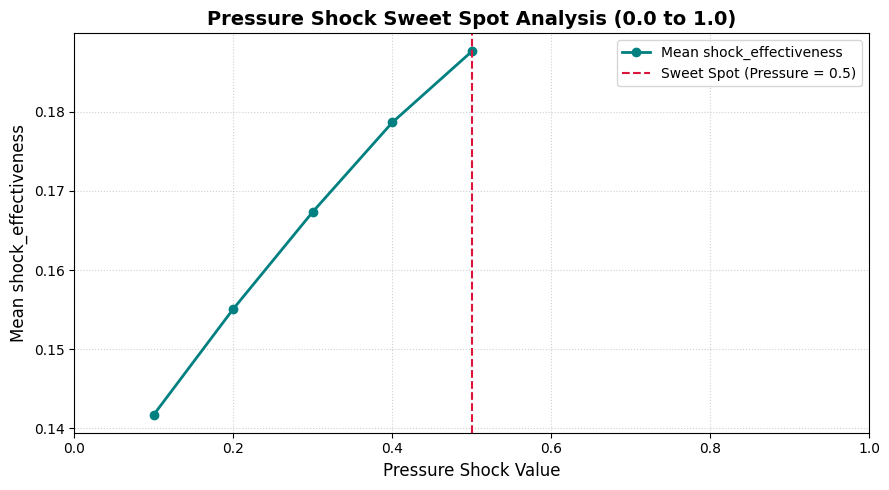

In [ ]:
import ast
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# 1. Safely extract the 'pressure' shock value from 'shock_pattern'
def extract_pressure(pattern):
    if isinstance(pattern, str):
        pattern = ast.literal_eval(pattern)
    return pattern.get("pressure", np.nan)


# Create temporary column for pressure
df_heterogeneous_all_shock_combinations["pressure_level"] = (
    df_heterogeneous_all_shock_combinations["shock_pattern"].apply(
        extract_pressure
    )
)

# 2. Filter data for pressure levels strictly between 0 and 1
df_filtered = df_heterogeneous_all_shock_combinations[
    (df_heterogeneous_all_shock_combinations["pressure_level"] >= 0.0)
    & (df_heterogeneous_all_shock_combinations["pressure_level"] <= 1.0)
].copy()

# 3. Group by pressure level and calculate mean effectiveness
metric_col = "shock_effectiveness"  # or 'shock_effectiveness'

pressure_performance = (
    df_filtered.groupby("pressure_level")[metric_col].mean().reset_index()
)

# 4. Identify the Sweet Spot within [0, 1]
sweet_spot_row = pressure_performance.loc[
    pressure_performance[metric_col].idxmax()
]
sweet_spot_p = sweet_spot_row["pressure_level"]
max_score = sweet_spot_row[metric_col]

print(f"Optimal Pressure Sweet Spot (0 to 1): Pressure = {sweet_spot_p}")
print(f"Max Mean {metric_col}: {max_score:.6f}")

# 5. Plot with forced x-axis limits between 0 and 1
plt.figure(figsize=(9, 5))
plt.plot(
    pressure_performance["pressure_level"],
    pressure_performance[metric_col],
    marker="o",
    color="teal",
    linewidth=2,
    label=f"Mean {metric_col}",
)
plt.axvline(
    x=sweet_spot_p,
    color="crimson",
    linestyle="--",
    label=f"Sweet Spot (Pressure = {sweet_spot_p})",
)

# Set x-axis limit strictly from 0 to 1
plt.xlim(0.0, 1.0)

plt.title(
    "Pressure Shock Sweet Spot Analysis (0.0 to 1.0)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Pressure Shock Value", fontsize=12)
plt.ylabel(f"Mean {metric_col}", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df_heterogeneous_all_shock_combinations

,parameter_combination,number_of_parameters,shock_pattern,shock_vector,shock_effectiveness,baseline_effectiveness,effectiveness_change,pressure_level
0,competition+cooperation+trust+pressure+enforcement,5,"{'competition': -0.6, 'cooperation': 0.6, 'trust': 0.7, 'pressure': 0.5, 'enforcement': -0.5}","(-0.6, 0.6, 0.7, 0.5, -0.5)",0.568490,0.322541,0.245950,0.5
1,competition+cooperation+trust+pressure+enforcement,5,"{'competition': -0.8, 'cooperation': 0.5, 'trust': 0.7, 'pressure': 0.5, 'enforcement': -0.4}","(-0.8, 0.5, 0.7, 0.5, -0.4)",0.567868,0.322541,0.245327,0.5
2,competition+cooperation+trust+pressure+enforcement,5,"{'competition': -0.8, 'cooperation': 0.6, 'trust': 0.6, 'pressure': 0.5, 'enforcement': -0.4}","(-0.8, 0.6, 0.6, 0.5, -0.4)",0.567626,0.322541,0.245086,0.5
3,competition+cooperation+trust+pressure+enforcement,5,"{'competition': -0.7, 'cooperation': 0.6, 'trust': 0.7, 'pressure': 0.4, 'enforcement': -0.4}","(-0.7, 0.6, 0.7, 0.4, -0.4)",0.567126,0.322541,0.244586,0.4
4,competition+cooperation+trust+pressure+enforcement,5,"{'competition': -0.8, 'cooperation': 0.6, 'trust': 0.7, 'pressure': 0.5, 'enforcement': -0.4}","(-0.8, 0.6, 0.7, 0.5, -0.4)",0.565110,0.322541,0.242570,0.5
...,...,...,...,...,...,...,...,...
161045,competition+cooperation+trust+pressure+enforcement,5,"{'competition': -0.5, 'cooperation': -0.4, 'trust': 0.3, 'pressure': -0.3, 'enforcement': 0.3}","(-0.5, -0.4, 0.3, -0.3, 0.3)",0.005839,0.322541,-0.316701,-0.3
161046,competition+cooperation+trust+pressure+enforcement,5,"{'competition': -0.5, 'cooperation': -0.4, 'trust': 0.3, 'pressure': -0.3, 'enforcement': 0.2}","(-0.5, -0.4, 0.3, -0.3, 0.2)",0.005839,0.322541,-0.316701,-0.3
161047,competition+cooperation+trust+pressure+enforcement,5,"{'competition': -0.5, 'cooperation': -0.4, 'trust': 0.3, 'pressure': -0.3, 'enforcement': 0.1}","(-0.5, -0.4, 0.3, -0.3, 0.1)",0.005839,0.322541,-0.316701,-0.3
161048,competition+cooperation+trust+pressure+enforcement,5,"{'competition': -0.5, 'cooperation': -0.4, 'trust': 0.3, 'pressure': -0.3, 'enforcement': -0.1}","(-0.5, -0.4, 0.3, -0.3, -0.1)",0.005839,0.322541,-0.316701,-0.3


In [ ]:
# Check unique pressure levels present in your data
unique_pressures = sorted(
    df_heterogeneous_all_shock_combinations["pressure_level"]
    .dropna()
    .unique()
)
print("Pressure levels found in dataset:", unique_pressures)

Pressure levels found in dataset: [-0.5, -0.4, -0.3, -0.2, -0.1, 0.1, 0.2, 0.3, 0.4, 0.5]


In [ ]:
# What was in the loop:
shocks = row["shock_vector"]  # Might be empty or targeting skills!

# What contains the 5 parameters:
shocks = row["shock_pattern"]  # Contains ['competition', 'cooperation', ...]

In [ ]:
import pandas as pd
import numpy as np
import ast
from tqdm import tqdm

NUM_YEARS = 5

# 1. Updated simulation function that applies shocks to parameters
def run_100_sensitivity(base_skills_df, initial_rel_params, shocks, years=NUM_YEARS):
    history = []
    current_skills = base_skills_df.copy()
    current_params = pd.Series(initial_rel_params, dtype=float).copy()

    for yr in range(years):
        # Apply initial shock at Year 0 to relation parameters
        if yr == 0 and shocks:
            for k, shock_val in shocks.items():
                if k in current_params.index:
                    current_params[k] += float(shock_val)
                elif k in current_skills.columns:
                    current_skills[k] += float(shock_val)

        # Record state for current year
        history.append({
            "year": yr,
            "skills": current_skills.copy(),
            "relation_params": current_params.copy()
        })

        # Network Influence Updates
        skill_delta_vals = current_params.values @ signed_param_skill.values
        skill_delta = pd.Series(skill_delta_vals, index=signed_param_skill.columns)

        param_delta_skills_vals = current_skills.mean().values @ signed_skill_param.values
        param_delta_rel_vals = current_params.values @ signed_rel_rel.values
        
        param_delta = pd.Series(
            param_delta_skills_vals + param_delta_rel_vals, 
            index=current_params.index
        )

        current_skills = current_skills + (skill_delta * 0.1)
        current_params = current_params + (param_delta * 0.1)

    return history


# 2. Run simulation over all combinations using shock_pattern
full_simulation_records = []

for idx, row in tqdm(df_heterogeneous_all_shock_combinations.iterrows(), 
                    total=len(df_heterogeneous_all_shock_combinations), 
                    desc="Simulating Full Scope"):
    
    combo_id = row["parameter_combination"]
    
    # Safely extract shock_pattern dictionary
    shocks = row["shock_pattern"]
    if isinstance(shocks, str):
        shocks = ast.literal_eval(shocks)
    elif hasattr(shocks, "to_dict"):
        shocks = shocks.to_dict()
    elif not isinstance(shocks, dict):
        shocks = {}

    history = run_100_sensitivity(
        base_skills_df=data["skills_df"],
        initial_rel_params=initial_scenarios["heterogeneous"],
        shocks=shocks,
        years=NUM_YEARS
    )
    
    for step in history:
        record = {
            "parameter_combination": combo_id,
            "number_of_parameters": row["number_of_parameters"],
            "shock_pattern": shocks,
            "shock_effectiveness": row["shock_effectiveness"],
            "baseline_effectiveness": row["baseline_effectiveness"],
            "effectiveness_change": row["effectiveness_change"],
            "pressure_level": row["pressure_level"],
            "year": step["year"],
        }
        
        for p_name, p_val in step["relation_params"].items():
            record[f"param_{p_name}"] = p_val
            
        for s_name, s_val in step["skills"].mean().items():
            record[f"skill_{s_name}"] = s_val
            
        full_simulation_records.append(record)

df_full_yearly = pd.DataFrame(full_simulation_records)


# 3. Compute and display sensitivity DataFrames for each year
parameters = ["competition", "cooperation", "trust", "pressure", "enforcement"]
yearly_sensitivity_dfs = {}
years = sorted(df_full_yearly["year"].unique())

for year in years:
    df_year = df_full_yearly[df_full_yearly["year"] == year]
    year_results = []

    for p in parameters:
        param_col = f"param_{p}"
        
        temp = pd.DataFrame({
            "param_value": df_year[param_col],
            "effectiveness": df_year["shock_effectiveness"]
        }).dropna()

        year_results.append({
            "parameter": p,
            "pearson_r": temp["param_value"].corr(temp["effectiveness"], method="pearson"),
            "spearman_r": temp["param_value"].corr(temp["effectiveness"], method="spearman"),
            "mean_param": temp["param_value"].mean(),
            "std_param": temp["param_value"].std()
        })

    df_year_sens = (
        pd.DataFrame(year_results)
        .sort_values(by="pearson_r", ascending=False)
        .reset_index(drop=True)
    )
    
    yearly_sensitivity_dfs[year] = df_year_sens
    globals()[f"df_sensitivity_year_{year}"] = df_year_sens

# Display output tables
for year, df_sens in yearly_sensitivity_dfs.items():
    print(f"\n==================== Year {year} Sensitivity ====================")
    display(df_sens)

Simulating Full Scope: 100%|██████████| 161050/161050 [17:02:21<00:00,  2.63it/s]     



==================== Year 0 Sensitivity ====================


,parameter,pearson_r,spearman_r,mean_param,std_param
0,enforcement,0.429393,0.516370,0.499999,0.316229
1,pressure,0.335285,0.406063,0.500000,0.316230
2,cooperation,0.141526,0.158329,0.500001,0.316230
3,trust,0.136239,0.150374,0.500001,0.316229
4,competition,0.117722,0.150150,0.499998,0.316229



==================== Year 1 Sensitivity ====================


,parameter,pearson_r,spearman_r,mean_param,std_param
0,enforcement,0.454763,0.551013,0.735713,0.317240
1,pressure,0.348299,0.425563,0.707857,0.317145
2,trust,0.144716,0.160553,0.751644,0.317303
3,cooperation,0.137526,0.152164,0.833429,0.319642
4,competition,0.105961,0.137342,0.597998,0.317696



==================== Year 2 Sensitivity ====================


,parameter,pearson_r,spearman_r,mean_param,std_param
0,enforcement,0.493819,0.596590,1.062906,0.334049
1,pressure,0.381040,0.463001,0.984955,0.334360
2,trust,0.174986,0.193637,1.089251,0.331996
3,cooperation,0.162864,0.179549,1.260811,0.342150
4,competition,0.118428,0.153678,0.722252,0.330734



==================== Year 3 Sensitivity ====================


,parameter,pearson_r,spearman_r,mean_param,std_param
0,enforcement,0.534541,0.654933,1.520171,0.372753
1,pressure,0.422643,0.515431,1.364296,0.372034
2,trust,0.221841,0.246520,1.547764,0.364002
3,cooperation,0.208814,0.230705,1.822640,0.386858
4,competition,0.148992,0.189527,0.888204,0.355081



==================== Year 4 Sensitivity ====================


,parameter,pearson_r,spearman_r,mean_param,std_param
0,enforcement,0.565586,0.709500,2.159591,0.442483
1,pressure,0.462611,0.568828,1.889643,0.436835
2,trust,0.277579,0.311333,2.174183,0.419635
3,cooperation,0.264668,0.296036,2.572953,0.460012
4,competition,0.191596,0.238970,1.115521,0.392708


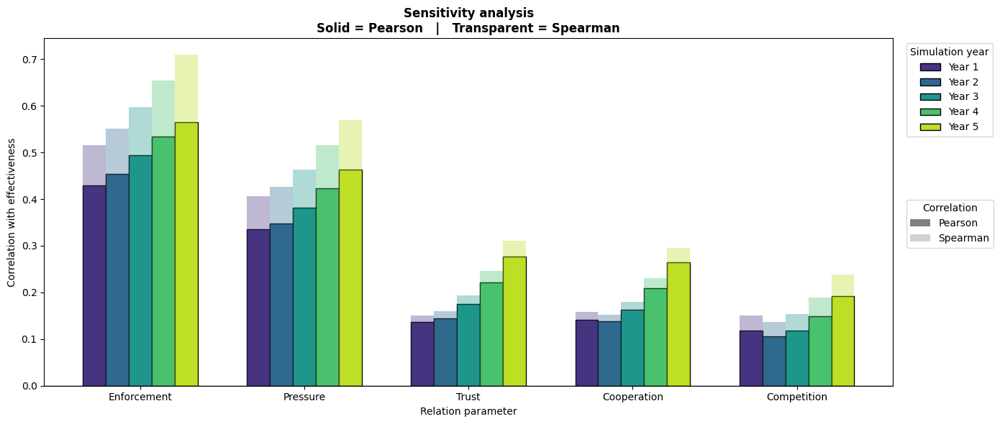

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------
# Combine yearly sensitivity tables
# ---------------------------------------

plot_data = []

for year, df in yearly_sensitivity_dfs.items():
    temp = df.copy()
    temp["year"] = year + 1      # rename years 0-4 -> 1-5
    plot_data.append(temp)

plot_df = pd.concat(plot_data, ignore_index=True)

parameters = [
    "enforcement",
    "pressure",
    "trust",
    "cooperation",
    "competition"
]

years = sorted(plot_df["year"].unique())

# ---------------------------------------
# Plot
# ---------------------------------------

fig, ax = plt.subplots(figsize=(14,6))

x = np.arange(len(parameters))

bar_width = 0.14

colors = plt.cm.viridis(np.linspace(0.15,0.9,len(years)))

for i, year in enumerate(years):

    df_year = (
        plot_df[plot_df.year == year]
        .set_index("parameter")
        .loc[parameters]
    )

    xpos = x + (i-(len(years)-1)/2)*bar_width

    # Pearson
    ax.bar(
        xpos,
        df_year["pearson_r"],
        width=bar_width,
        color=colors[i],
        edgecolor="black",
        label=f"Year {year}" if i==0 else None
    )

    # Spearman (transparent overlay)
    ax.bar(
        xpos,
        df_year["spearman_r"],
        width=bar_width,
        color=colors[i],
        alpha=0.35
    )

ax.axhline(0,color="black",linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels([p.capitalize() for p in parameters])

ax.set_ylabel("Correlation with effectiveness")
ax.set_xlabel("Relation parameter")

ax.set_title(
    "Sensitivity analysis\n"
    "Solid = Pearson   |   Transparent = Spearman",
    fontweight="bold"
)

# legend for years
from matplotlib.patches import Patch

year_handles = [
    Patch(facecolor=colors[i], edgecolor='black', label=f"Year {y}")
    for i,y in enumerate(years)
]

corr_handles = [
    Patch(facecolor="gray", alpha=1, label="Pearson"),
    Patch(facecolor="gray", alpha=0.35, label="Spearman")
]

legend1 = ax.legend(
    handles=year_handles,
    title="Simulation year",
    bbox_to_anchor=(1.01,1),
    loc="upper left"
)

ax.add_artist(legend1)

ax.legend(
    handles=corr_handles,
    title="Correlation",
    bbox_to_anchor=(1.01,0.55),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Pressure investigation

### Why a "Sweet Spot" Exists for PressurePressure has a neutral orientation ($0$) in matrix construction, acting as a double-edged sword:Positive effect: Moderate pressure increases Sense of Urgency, cooperation, and rule adherence.Negative effect: Excessive pressure increases competition, reduces trust, and drives up Reputation concerns, leading to collaborative friction.The sweet spot $P^*$ is defined as:$$P^* = \arg\max_{P \in [0, 1]} \frac{1}{\text{tail}} \sum_{t = T - \text{tail} + 1}^{T} \text{Effectiveness}(t)$$Where Collaboration Effectiveness is measured as a composite score of positive relational indicators ($\text{Cooperation} + \text{Trust} - \text{Competition}$).

### Parameter AnalysisEffect on CollaborationLow Pressure ($P < P^*$)Insufficient sense of urgency; cooperation and trust stall at sub-optimal equilibrium levels.Sweet Spot ($P = P^*$)Maximizes mutual cooperation and trust without triggering destructive competitive dynamics or rule resistance.High Pressure ($P > P^*$)Overwhelms trust through enforcement/competition feedbacks, reducing net effectiveness.How to use this extension:Grid Granularity: Adjust pressure_levels=np.linspace(0.0, 1.0, 201) for higher resolution.Custom Effectiveness Metric: Modify eff = rel_params["cooperation"] + rel_params["trust"] - 0.5 * rel_params["competition"] inside run_ppc_simulation if your paper defines effectiveness with specific weightings.

        COLLABORATION PRESSURE SWEET SPOT RESULTS        
Initial Scenario  Pressure Sweet Spot (P*)  Max Effectiveness Score  Cooperation  Trust  Competition
       nullpoint                       0.0                      1.5          1.0    1.0          1.0
         balance                       0.0                      1.5          1.0    1.0          1.0
   heterogeneous                       0.0                      1.5          1.0    1.0          1.0



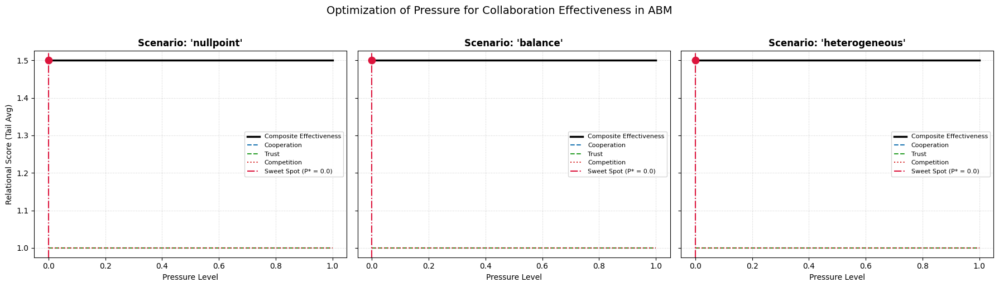

In [ ]:
# ==============================================================================
# PPC ABM EXTENSION: PRESSURE SWEET SPOT INVESTIGATION
# ==============================================================================

def run_ppc_simulation(data, signed_matrices, initial_rel_params, fixed_pressure=None, steps=40, rate=0.1):
    """
    Simulates the dynamic updates of Relation Parameters and Actor Skills over time.
    If `fixed_pressure` is provided, pressure is held constant at that level.
    """
    signed_rel_rel, signed_skill_param, signed_param_skill = signed_matrices
    skills_df = data["skills_df"].copy()
    rel_params = initial_rel_params.copy()
    
    # Track metrics over time
    history = {p: [] for p in RELATION_PARAMS}
    history["effectiveness"] = []

    for t in range(steps):
        if fixed_pressure is not None:
            rel_params["pressure"] = fixed_pressure

        # Convert current relation params to vector
        rel_vec = pd.Series(rel_params)

        # Average skill levels across all actors
        mean_skills = skills_df.mean(axis=0)

        # 1. Update Relation Parameters: dR = rate * (R * W_rr + S_mean * W_sp)
        delta_rel = (
            rel_vec.dot(signed_rel_rel) + 
            mean_skills.dot(signed_skill_param)
        )
        new_rel_vec = rel_vec + rate * delta_rel
        
        # Clip relation parameters to valid bounds [0, 1] (Reputation handled in skills)
        new_rel_vec = new_rel_vec.clip(0.0, 1.0)
        
        if fixed_pressure is not None:
            new_rel_vec["pressure"] = fixed_pressure

        # 2. Update Actor Skills: dS = rate * (R * W_ps)
        delta_skills = pd.DataFrame(
            np.outer(np.ones(len(skills_df)), new_rel_vec.dot(signed_param_skill)),
            index=skills_df.index,
            columns=skills_df.columns
        )
        skills_df = (skills_df + rate * delta_skills).clip(-1.0, 1.0)

        # Save state
        rel_params = new_rel_vec.to_dict()
        for p in RELATION_PARAMS:
            history[p].append(rel_params[p])

        # Composite Effectiveness: Cooperation + Trust - 0.5 * Competition
        eff = rel_params["cooperation"] + rel_params["trust"] - 0.5 * rel_params["competition"]
        history["effectiveness"].append(eff)

    return history


def optimize_pressure(data, signed_matrices, pressure_levels=None, steps=40, rates=None, tail=8):
    """
    Sweeps through pressure levels to find the optimal pressure ('sweet spot')
    that maximizes collaboration effectiveness over the tail steps.
    """
    if pressure_levels is None:
        pressure_levels = np.linspace(0.0, 1.0, 101)
    
    rate = rates if rates is not None else 0.1
    scenarios = initial_scenarios
    
    results = []

    for scenario_name, init_params in scenarios.items():
        eff_scores = []
        coop_scores = []
        trust_scores = []
        comp_scores = []

        for p_val in pressure_levels:
            hist = run_ppc_simulation(
                data=data,
                signed_matrices=signed_matrices,
                initial_rel_params=init_params,
                fixed_pressure=p_val,
                steps=steps,
                rate=rate
            )
            
            # Compute steady-state averages over the last `tail` steps
            tail_eff = np.mean(hist["effectiveness"][-tail:])
            tail_coop = np.mean(hist["cooperation"][-tail:])
            tail_trust = np.mean(hist["trust"][-tail:])
            tail_comp = np.mean(hist["competition"][-tail:])

            eff_scores.append(tail_eff)
            coop_scores.append(tail_coop)
            trust_scores.append(tail_trust)
            comp_scores.append(tail_comp)

        # Identify Sweet Spot (Max Effectiveness)
        best_idx = np.argmax(eff_scores)
        sweet_spot_p = pressure_levels[best_idx]
        max_eff = eff_scores[best_idx]

        results.append({
            "scenario": scenario_name,
            "sweet_spot_pressure": round(sweet_spot_p, 3),
            "max_effectiveness": round(max_eff, 4),
            "cooperation_at_p": round(coop_scores[best_idx], 4),
            "trust_at_p": round(trust_scores[best_idx], 4),
            "competition_at_p": round(comp_scores[best_idx], 4),
            "all_pressures": pressure_levels,
            "eff_curve": eff_scores,
            "coop_curve": coop_scores,
            "trust_curve": trust_scores,
            "comp_curve": comp_scores
        })

    return results


# ==============================================================================
# EXECUTE INVESTIGATION & PLOT RESULTS
# ==============================================================================

# Run optimization across scenarios
opt_results = optimize_pressure(data, signed_matrices, steps=40, tail=8)

# 1. Summary Table
table_data = []
for res in opt_results:
    table_data.append({
        "Initial Scenario": res["scenario"],
        "Pressure Sweet Spot (P*)": res["sweet_spot_pressure"],
        "Max Effectiveness Score": res["max_effectiveness"],
        "Cooperation": res["cooperation_at_p"],
        "Trust": res["trust_at_p"],
        "Competition": res["competition_at_p"],
    })

df_summary = pd.DataFrame(table_data)
print("==========================================================")
print("        COLLABORATION PRESSURE SWEET SPOT RESULTS        ")
print("==========================================================")
print(df_summary.to_string(index=False))
print("==========================================================\n")

# 2. Visualizations
fig, axes = plt.subplots(1, len(opt_results), figsize=(6 * len(opt_results), 5), sharey=True)
if len(opt_results) == 1:
    axes = [axes]

for i, res in enumerate(opt_results):
    ax = axes[i]
    p_vals = res["all_pressures"]
    eff = res["eff_curve"]
    coop = res["coop_curve"]
    trust = res["trust_curve"]
    comp = res["comp_curve"]
    p_star = res["sweet_spot_pressure"]
    max_eff = res["max_effectiveness"]

    ax.plot(p_vals, eff, label="Composite Effectiveness", color="black", linewidth=2.5)
    ax.plot(p_vals, coop, label="Cooperation", color="tab:blue", linestyle="--")
    ax.plot(p_vals, trust, label="Trust", color="tab:green", linestyle="--")
    ax.plot(p_vals, comp, label="Competition", color="tab:red", linestyle=":")

    # Highlight Sweet Spot
    ax.axvline(x=p_star, color="crimson", linestyle="-.", label=f"Sweet Spot (P* = {p_star})")
    ax.scatter([p_star], [max_eff], color="crimson", s=80, zorder=5)

    ax.set_title(f"Scenario: '{res['scenario']}'", fontsize=12, fontweight="bold")
    ax.set_xlabel("Pressure Level", fontsize=10)
    if i == 0:
        ax.set_ylabel("Relational Score (Tail Avg)", fontsize=10)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="best", fontsize=8)

plt.suptitle("Optimization of Pressure for Collaboration Effectiveness in ABM", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()